---
execute:
  skip: true
authors:
- name: Steffen Bollmann
- name: Monika Doerig
doi: 10.5281/zenodo.18740157
github: https://github.com/neurodesk/neurodeskedu/blob/main/books/examples/quantitative_imaging/aslprep.ipynb
edit_url: https://github.com/neurodesk/neurodeskedu/edit/main/books/examples/quantitative_imaging/aslprep.ipynb
downloads:
- url: /edu/_sources/examples/quantitative_imaging/aslprep.ipynb
  title: Download source notebook
  filename: aslprep.ipynb
  static: false
---
# ASLprep

:::{admonition} Reviewed
:class: nd-review-badge nd-review-badge--reviewed

[review issue](<https://github.com/neurodesk/neurodeskedu-reviews/issues/22>) · [@handwerkerd](<https://github.com/handwerkerd>)
:::

:::{dropdown} Run this notebook
:class: nd-launch

- [Run in Australia](<https://play.neurodesk.cloud.edu.au/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/quantitative_imaging/aslprep.ipynb&branch=main>)
- [Run in Europe](<https://play-europe.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/quantitative_imaging/aslprep.ipynb&branch=main>)
- [Run in America](<https://play-america.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/quantitative_imaging/aslprep.ipynb&branch=main>)
- [Run in Global Server 1](<https://play-europe.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/quantitative_imaging/aslprep.ipynb&branch=main>)
- [Run in Global Server 2](<https://edu.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/quantitative_imaging/aslprep.ipynb&branch=main>)
:::

## A Robust Preprocessing Pipeline for ASL Data


**Author:** Steffen Bollmann & Monika Doerig

**Date:** 17 Oct 2024

**License:** 
<div style="margin-top: 10px;">
    <a href="https://opensource.org/licenses/MIT" target="_blank" style="color: #0066cc;">
        <i class="fas fa-balance-scale"></i> MIT License
    </a>
</div>


**Note:** If this notebook uses neuroimaging tools from Neurocontainers, those tools retain their original licenses. Please see <a href="https://neurodesk.org/overview/how-to-cite-us/" target="_blank" style="color: #0066cc;">Neurodesk citation guidelines</a> for details.

### Citation and Resources

#### Tools included in this workflow

__ASLPrep:__
- Adebimpe, A., Bertolero, M., Dolui, S. et al. ASLPrep: a platform for processing of arterial spin labeled MRI and quantification of regional brain perfusion. Nat Methods 19, 683–686 (2022). [https://doi.org/10.1038/s41592-022-01458-7](https://doi.org/10.1038/s41592-022-01458-7)

__FreeSurfer__:
- Dale, A.M., Fischl, B., Sereno, M.I. (1999). Cortical surface-based analysis. I. Segmentation and surface reconstruction. NeuroImage, 9(2), 179–194. [https://doi.org/10.1006/nimg.1998.0395](https://doi.org/10.1006/nimg.1998.0395)
- Fischl, B., Sereno, M.I., Dale, A.M. (1999). Cortical surface-based analysis. II: Inflation, flattening, and a surface-based coordinate system. NeuroImage, 9(2), 195–207. [https://doi.org/10.1006/nimg.1998.0396](https://doi.org/10.1006/nimg.1998.0396)
- Fischl, B. & Dale, A.M. (2000). Measuring the thickness of the human cerebral cortex from magnetic resonance images. Proceedings of the National Academy of Sciences, 97(20), 11050–11055. [https://doi.org/10.1073/pnas.200033797](https://doi.org/10.1073/pnas.200033797)   

#### Dataset
__Opensource Data from OpenNeuro:__

- Alvaro Galiano and Reyes Garcia de Eulate and Marta Vidorreta and Miriam Recio and Mario Riverol and José L. Zubieta and Maria A. Fernandez-Seara PhD (2021). Resting State Perfusion in Healthy Aging. OpenNeuro Dataset ds000240.[doi: 10.18112/openneuro.ds000240.v2.0.0](https://openneuro.org/datasets/ds000240/versions/2.0.0)

#### Educational resources
- [ASLPrep documentation](https://aslprep.readthedocs.io/en/latest/index.html)

## Introduction

Arterial Spin Labeling (ASL) MRI is a non-invasive technique for measuring cerebral blood flow (CBF) without the need for contrast agents. However, processing ASL data involves multiple complex steps — motion correction, registration to anatomical images, partial volume correction, and CBF quantification — each requiring careful parameter choices and quality control.

[ASLPrep](https://aslprep.readthedocs.io/) is an ASL preprocessing and CBF computation pipeline designed to be robust to variations in scan acquisition protocols while requiring minimal user input. It adapts its preprocessing steps depending on the input dataset and uses a combination of tools from well-known software packages (FSL, ANTs, FreeSurfer, and AFNI), selecting the best available implementation for each step. ASLPrep is largely based on [fMRIPrep](https://fmriprep.org/) and is part of the [NiPreps](https://www.nipreps.org/) community, but accounts for key differences between ASL and fMRI —for example, separate motion correction per volume type, slice-timing–aware CBF calculation instead of slice timing correction, and reference image selection based on highest-contrast volume type.                                                                    
This notebook demonstrates how to run ASLPrep on a publicly available dataset using Neurodesk, making quantitative perfusion imaging accessible without manual installation of the required dependencies.    

![image](https://raw.githubusercontent.com/PennLINC/aslprep/main/docs/_static/aslprepworkflow.png)

## Learning Objectives

By the end of this notebook, you will be able to:                                                                                                           
1. Set up and run ASLPrep on a BIDS-formatted ASL dataset using Neurodesk
2. Navigate and interpret ASLPrep's visual quality control outputs, including brain segmentation, spatial normalisation, ASL-to-T1w registration, and CBF maps
3. Identify common issues in ASL processing from the visual reports (carpet plots, registration overlays)

## Load software tools

In [1]:
# load aslprep
import os
import module
await module.load('aslprep/26.0.2')
await module.list()

['aslprep/26.0.2']

## Set up FreeSurfer license

In [2]:
# Request a freesurfer license and store it in your homedirectory. 
# This is just an example - please replace with your license id:
license_path = os.path.expanduser("~/.license")

# Create the license file using Python (more reliable than ! commands in batch execution)
license_content = """Steffen.Bollmann@cai.uq.edu.au
21029
*Cqyn12sqTCxo
FSxgcvGkNR59Y
"""

with open(license_path, 'w') as f:
    f.write(license_content)

# Verify the license file was created
if os.path.exists(license_path):
    print(f"✅ FreeSurfer license file created at: {license_path}")
    with open(license_path, 'r') as f:
        print(f"   Lines: {len(f.readlines())}")
else:
    raise RuntimeError(f"❌ Failed to create FreeSurfer license file at {license_path}")

✅ FreeSurfer license file created at: /home/jovyan/.license
   Lines: 4


## Download data using DataLad

In [3]:
!datalad install https://github.com/OpenNeuroDatasets/ds000240.git
!cd ds000240 && datalad get sub-01

Cloning:   0%|                             | 0.00/2.00 [00:00<?, ? candidates/s]


Enumerating: 0.00 Objects [00:00, ? Objects/s]
                                              
Counting:   0%|                              | 0.00/1.20k [00:00<?, ? Objects/s]
                                                                                
Compressing:   0%|                             | 0.00/883 [00:00<?, ? Objects/s]
                                                                                
Receiving:   0%|                             | 0.00/2.39k [00:00<?, ? Objects/s]


                                                                                
Resolving:   0%|                                | 0.00/256 [00:00<?, ? Deltas/s]
                                                                                

[INFO   ] Remote origin not usable by git-annex; setting annex-ignore 
[INFO   ] https://github.com/OpenNeuroDatasets/ds000240.git/config download failed: Not Found 


[INFO   ] access to 1 dataset sibling s3-PRIVATE not auto-enabled, enable with:
| 		datalad siblings -d "/home/jovyan/workspace/books/examples/quantitative_imaging/ds000240" enable -s s3-PRIVATE 
install(ok): /home/jovyan/workspace/books/examples/quantitative_imaging/ds000240 (dataset)


Total:   0%|                                   | 0.00/18.0M [00:00<?, ? Bytes/s]


Get sub-01/a .. 1_T1w.nii.gz:   0%|            | 0.00/9.52M [00:00<?, ? Bytes/s]


Get sub-01/a .. 1_T1w.nii.gz:   0%|    | 33.4k/9.52M [00:00<00:59, 159k Bytes/s]


Get sub-01/a .. 1_T1w.nii.gz:   1%|    | 68.2k/9.52M [00:00<00:55, 169k Bytes/s]


Get sub-01/a .. 1_T1w.nii.gz:   1%|     | 138k/9.52M [00:00<00:39, 236k Bytes/s]


Get sub-01/a .. 1_T1w.nii.gz:   3%|▏    | 294k/9.52M [00:00<00:21, 434k Bytes/s]


Get sub-01/a .. 1_T1w.nii.gz:   6%|▎    | 608k/9.52M [00:01<00:11, 810k Bytes/s]


Get sub-01/a .. 1_T1w.nii.gz:  13%|▍  | 1.23M/9.52M [00:01<00:05, 1.54M Bytes/s]


Get sub-01/a .. 1_T1w.nii.gz:  26%|▊  | 2.49M/9.52M [00:01<00:02, 3.34M Bytes/s]


Get sub-01/a .. 1_T1w.nii.gz:  31%|▉  | 2.96M/9.52M [00:01<00:01, 3.62M Bytes/s]


Get sub-01/a .. 1_T1w.nii.gz:  48%|█▍ | 4.55M/9.52M [00:01<00:00, 6.32M Bytes/s]


Get sub-01/a .. 1_T1w.nii.gz:  70%|██ | 6.70M/9.52M [00:01<00:00, 6.81M Bytes/s]


Get sub-01/a .. 1_T1w.nii.gz:  86%|██▌| 8.19M/9.52M [00:02<00:00, 8.33M Bytes/s]


                                                                                
Get sub-01/a .. 1_T1w.nii.gz:   0%|            | 0.00/9.52M [00:00<?, ? Bytes/s]


Total:  53%|█████████████▊            | 9.52M/18.0M [00:03<00:03, 2.78M Bytes/s]


Get sub-01/p .. 1_asl.nii.gz:   0%|            | 0.00/8.48M [00:00<?, ? Bytes/s]


Get sub-01/p .. 1_asl.nii.gz:  18%|▌  | 1.49M/8.48M [00:00<00:00, 14.8M Bytes/s]


Get sub-01/p .. 1_asl.nii.gz:  37%|█  | 3.13M/8.48M [00:00<00:00, 15.4M Bytes/s]


Get sub-01/p .. 1_asl.nii.gz:  74%|██▏| 6.24M/8.48M [00:00<00:00, 12.3M Bytes/s]


                                                                                
Get sub-01/p .. 1_asl.nii.gz:   0%|            | 0.00/8.48M [00:00<?, ? Bytes/s]


get(ok): sub-01/anat/sub-01_T1w.nii.gz (file) [from s3-PUBLIC...]
get(ok): sub-01/perf/sub-01_asl.nii.gz (file) [from s3-PUBLIC...]
get(ok): sub-01 (directory)
action summary:
  get (ok: 3)


## Run ASLPrep                                                                                                             
The next cell runs ASLPrep on one participant from the ds000240 dataset and writes outputs to `aslprep-output/`.                                                     
A few practical notes:                              
- The FreeSurfer license file should exist at `~/.license` (created above).                                   
- Runtime depends heavily on available CPUs and memory. It will likely take **a few of hours (~4-6 hours)** to run.
- **On small nodes, set resource limits explicitly** (`--nthreads`, `--omp-nthreads`, `--mem-mb`) so ASLPrep doesn't oversubscribe RAM and get OOM (out of memory) killed. The cell below detects the available resources automatically.                
- To check progress, open a **Terminal** and run `top`, or `tail -f aslprep.log`
- If a previous run left intermediates in `aslprep-work/`, ASLPrep will reuse them and finish much faster. To force a clean run, delete `aslprep-work/` first.           
- ASLPrep handles the full pipeline: anatomical preprocessing (brain extraction, segmentation, surface reconstruction, spatial normalisation), ASL preprocessing (motion correction, distortion correction, ASL-to-T1w registration), and CBF quantification.
Short version (one sentence, to append):
- **Sidecar workaround**: The ds000240 sidecars ship with `RepetitionTimePreparation: 0`. ASLPrep 26.x reads this field as` m0tr` in the M0-recovery correction *(1 − exp(−m0tr/T1blood))* — when it is 0, the term collapses to 0 and every CBF voxel becomes zero with no error. As a workaround we copy the value of `RepetitionTime` into `RepetitionTimePreparation` in the patching cell above, which restores physiologically plausible CBF. Older ASLPrep versions (0.7.x) did not consume this field and were unaffected.       

In [4]:
import json                                                                                                                                                                                                               
from pathlib import Path                                                                                                                                                                                                  
                                                                                                                                                                                                                        
sidecar = Path("ds000240/sub-01/perf/sub-01_asl.json")                                                                                                                                                                    
meta = json.loads(sidecar.read_text())                                                                                                                                                                                    
                                                                                                                                                                                                                        
if meta.get("RepetitionTimePreparation") in (None, 0, 0.0):                                                                                                                                                               
  meta["RepetitionTimePreparation"] = meta["RepetitionTime"]
  sidecar.write_text(json.dumps(meta, indent=4))                                                                                                                                                                        
  print(f"Patched {sidecar}: RepetitionTimePreparation -> {meta['RepetitionTimePreparation']}")
else:                                                                                                                                                                                                                     
  print(f"No change: RepetitionTimePreparation = {meta['RepetitionTimePreparation']}")

Patched ds000240/sub-01/perf/sub-01_asl.json: RepetitionTimePreparation -> 3.5


In [5]:
%%bash                                                                                                                                    
set -u -o pipefail

# FreeSurfer expects the subjects directory to exist at startup 
mkdir -p "$HOME/freesurfer-subjects-dir"
                                                                                        
# Detect available resources                                                                     
N_CPUS=$(nproc)                                                                                                                                      
MEM_MB=$(awk '/MemTotal/ {printf "%d", $2/1024}' /proc/meminfo)                                                                                      
                                                                                                                                                   
# Leave headroom: ~75% of RAM, cap OMP threads at 2                                                                              
ASLPREP_MEM=$(( MEM_MB * 75 / 100 ))                                                                                                                 
OMP_THREADS=$(( N_CPUS < 2 ? 1 : 2 ))                                                                                                                
                                                                                                                                                   
echo "Using ${N_CPUS} CPUs, ${ASLPREP_MEM} MB RAM, omp=${OMP_THREADS}"                                                                               
                                                                                                                                                   
aslprep ds000240 \
    aslprep-output \
    participant \
    --participant-label 01 \
    --fs-license-file ~/.license \
    -w aslprep-work \
    --nthreads "${N_CPUS}" \
    --omp-nthreads "${OMP_THREADS}" \
    --mem-mb "${ASLPREP_MEM}" \
    2>&1 | tee aslprep.log

# Verify aslprep produced expected outputs
if [ ! -f "aslprep-output/sub-01.html" ]; then                                                                                                              
  echo "ERROR: ASLPrep did not produce the expected report (sub-01.html)"                                                                                 
  exit 1                                                                                                                                                  
fi

Using 32 CPUs, 96604 MB RAM, omp=2


bids-validator@1.14.10


(node:1062) Warning: Closing directory handle on garbage collection
(Use `node --trace-warnings ...`

 to show where the warning was created)


This dataset appears to be BIDS compatible.
        Summary:           

       Available Tasks:        Available Modalities: 
        

133 Files, 17.76MB                                MRI                   
        63 - Subjects      

                                                     
        1 - Session                           

                                  


	If you have any questions, please post on https://neurost

ars.org/tags/bids.


260417-23:09:18,138 nipype.workflow IMPORTANT:
	 Running ASLPrep version 26.0.2

         License NO

TICE ##################################################
         ASLPrep 26.0.2
         Copyright 2

023 The PennLINC Team and the NiPreps Developers.
         
         This product is primarily devel

oped by the PennLINC team,
         but it is also a part of the NiPreps community.
         
      

   This product includes software developed by
         the NiPreps Community (https://nipreps.org/)

.
         
         Portions of this software were developed at the Department of
         Psycholo

gy at Stanford University, Stanford, CA, US.
         
         This software is also distributed as

 a Docker container image.
         The bootstrapping file for the image ("Dockerfile") is licensed


         under the MIT License.
         
         This software may be distributed through an add-o

n package called
         "Docker Wrapper" that is under the BSD 3-clause License.
         ########

#########################################################
260417-23:09:18,138 nipype.workflow IMPORT

ANT:
	 Building ASLPrep's workflow:
           * BIDS dataset path: /home/jovyan/workspace/books/exa

mples/quantitative_imaging/ds000240.
           * Participants and sessions: sub-01.
           * Ru

n identifier: 20260417-230753_94fbc516-51cb-4105-af94-264ef1671294.
           * Output spaces: MNI1

52NLin2009cAsym:res-native.
           * Searching for derivatives: {'aslprepatlases': PosixPath('/h

ome/aslprep/.cache/aslprep/XCPDAtlases'), 'aslprep4s': PosixPath('/home/aslprep/.cache/aslprep/Atlas

Pack')}.
           * Pre-run FreeSurfer's SUBJECTS_DIR: /home/jovyan/workspace/books/examples/quant

itative_imaging/aslprep-output/sourcedata/freesurfer.


260417-23:09:21,906 nipype.workflow INFO:
	 Anatomical cache: {}


s-01_T1w.nii.gz


  0%|          | 0.00/13.7M [00:00<?, ?B/s]

  0%|          | 17.4k/13.7M [00:00<02:42, 83.9kB/s]

  1%|          | 71.7k/13.7M [00:00<01:12, 187kB/s] 

  1%|          | 124k/13.7M [00:00<01:03, 214kB/s] 

  2%|▏         | 298k/13.7M [00:00<00:29, 456kB/s]

  5%|▍         | 629k/13.7M [00:01<00:15, 857kB/s]

 10%|▉         | 1.31M/13.7M [00:01<00:07, 1.66MB/s]

 19%|█▉        | 2.63M/13.7M [00:01<00:03, 3.14MB/s]

 39%|███▉      | 5.31M/13.7M [00:01<00:01, 6.16MB/s]

 56%|█████▌    | 7.65M/13.7M [00:01<00:00, 7.67MB/s]

 76%|███████▌  | 10.4M/13.7M [00:02<00:00, 9.25MB/s]

 94%|█████████▍| 12.9M/13.7M [00:02<00:00, 10.1MB/s]

100%|██████████| 13.7M/13.7M [00:02<00:00, 5.84MB/s]


s-01_desc-brain_mask.nii.gz


  0%|          | 0.00/160k [00:00<?, ?B/s]

 11%|█         | 17.4k/160k [00:00<00:01, 82.9kB/s]

 44%|████▎     | 69.6k/160k [00:00<00:00, 180kB/s] 

 87%|████████▋ | 139k/160k [00:00<00:00, 248kB/s] 

100%|██████████| 160k/160k [00:00<00:00, 252kB/s]


s-01_T2w.nii.gz


  0%|          | 0.00/13.3M [00:00<?, ?B/s]

  0%|          | 17.4k/13.3M [00:00<02:39, 83.1kB/s]

  1%|          | 69.6k/13.3M [00:00<01:13, 180kB/s] 

  1%|          | 139k/13.3M [00:00<00:52, 248kB/s] 

  2%|▏         | 296k/13.3M [00:00<00:29, 443kB/s]

  5%|▍         | 627k/13.3M [00:01<00:14, 848kB/s]

 10%|▉         | 1.27M/13.3M [00:01<00:07, 1.60MB/s]

 20%|█▉        | 2.60M/13.3M [00:01<00:03, 3.12MB/s]

 38%|███▊      | 5.05M/13.3M [00:01<00:01, 5.83MB/s]

 53%|█████▎    | 7.00M/13.3M [00:01<00:00, 6.89MB/s]

 69%|██████▉   | 9.20M/13.3M [00:02<00:00, 7.97MB/s]

 85%|████████▍ | 11.3M/13.3M [00:02<00:00, 8.51MB/s]

100%|██████████| 13.3M/13.3M [00:02<00:00, 5.61MB/s]


260417-23:09:30,586 nipype.workflow INFO:
	 ANAT Stage 1: Adding template workflow


260417-23:09:32,468 nipype.workflow INFO:
	 ANAT Stage 2: Preparing brain extraction workflow


  0%|          | 0.00/32.4M [00:00<?, ?B/s]

  0%|          | 17.4k/32.4M [00:00<06:31, 82.7kB/s]

  0%|          | 52.2k/32.4M [00:00<04:06, 131kB/s] 

  0%|          | 122k/32.4M [00:00<02:25, 222kB/s] 

  1%|          | 279k/32.4M [00:00<01:15, 427kB/s]

  2%|▏         | 574k/32.4M [00:01<00:40, 777kB/s]

  4%|▎         | 1.18M/32.4M [00:01<00:20, 1.49MB/s]

  7%|▋         | 2.18M/32.4M [00:01<00:11, 2.54MB/s]

 12%|█▏        | 3.88M/32.4M [00:01<00:06, 4.30MB/s]

 20%|█▉        | 6.36M/32.4M [00:01<00:03, 6.60MB/s]

 26%|██▌       | 8.47M/32.4M [00:02<00:03, 7.64MB/s]

 33%|███▎      | 10.8M/32.4M [00:02<00:02, 8.63MB/s]

 40%|███▉      | 12.9M/32.4M [00:02<00:02, 9.09MB/s]

 47%|████▋     | 15.1M/32.4M [00:02<00:01, 9.38MB/s]

 53%|█████▎    | 17.2M/32.4M [00:02<00:01, 9.62MB/s]

 60%|█████▉    | 19.3M/32.4M [00:03<00:01, 9.69MB/s]

 66%|██████▋   | 21.5M/32.4M [00:03<00:01, 9.83MB/s]

 73%|███████▎  | 23.6M/32.4M [00:03<00:00, 9.89MB/s]

 80%|███████▉  | 25.7M/32.4M [00:03<00:00, 9.94MB/s]

 86%|████████▌ | 27.9M/32.4M [00:04<00:00, 9.97MB/s]

 93%|█████████▎| 30.0M/32.4M [00:04<00:00, 9.99MB/s]

 99%|█████████▉| 32.1M/32.4M [00:04<00:00, 10.0MB/s]

100%|██████████| 32.4M/32.4M [00:04<00:00, 7.26MB/s]


_probseg.nii.gz


  0%|          | 0.00/2.59M [00:00<?, ?B/s]

  1%|          | 17.4k/2.59M [00:00<00:31, 82.8kB/s]

  3%|▎         | 69.6k/2.59M [00:00<00:14, 180kB/s] 

  5%|▌         | 138k/2.59M [00:00<00:09, 246kB/s] 

  9%|▉         | 244k/2.59M [00:00<00:06, 346kB/s]

 19%|█▉        | 487k/2.59M [00:01<00:03, 638kB/s]

 36%|███▋      | 940k/2.59M [00:01<00:01, 1.15MB/s]

 69%|██████▉   | 1.79M/2.59M [00:01<00:00, 2.09MB/s]

100%|██████████| 2.59M/2.59M [00:01<00:00, 1.73MB/s]


erebellumExtraction_mask.nii.gz


  0%|          | 0.00/265k [00:00<?, ?B/s]

  7%|▋         | 17.4k/265k [00:00<00:02, 82.9kB/s]

 26%|██▋       | 69.6k/265k [00:00<00:01, 180kB/s] 

 52%|█████▏    | 138k/265k [00:00<00:00, 246kB/s] 

100%|██████████| 265k/265k [00:00<00:00, 416kB/s]


obseg.nii.gz


  0%|          | 0.00/4.06M [00:00<?, ?B/s]

  0%|          | 17.4k/4.06M [00:00<00:48, 83.0kB/s]

  2%|▏         | 69.6k/4.06M [00:00<00:22, 180kB/s] 

  3%|▎         | 138k/4.06M [00:00<00:15, 247kB/s] 

  7%|▋         | 296k/4.06M [00:00<00:08, 445kB/s]

 15%|█▌        | 627k/4.06M [00:01<00:04, 851kB/s]

 32%|███▏      | 1.31M/4.06M [00:01<00:01, 1.66MB/s]

 65%|██████▍   | 2.63M/4.06M [00:01<00:00, 3.18MB/s]

100%|██████████| 4.06M/4.06M [00:01<00:00, 2.68MB/s]


obseg.nii.gz


  0%|          | 0.00/447k [00:00<?, ?B/s]

  4%|▍         | 17.4k/447k [00:00<00:05, 82.8kB/s]

 16%|█▌        | 69.6k/447k [00:00<00:02, 180kB/s] 

 27%|██▋       | 122k/447k [00:00<00:01, 210kB/s] 

 66%|██████▋   | 296k/447k [00:00<00:00, 453kB/s]

100%|██████████| 447k/447k [00:00<00:00, 526kB/s]


260417-23:09:45,853 nipype.workflow INFO:
	 ANAT Stage 3: Preparing segmentation workflow


260417-23:09:45,864 nipype.workflow INFO:
	 ANAT Stage 4: Preparing normalization workflow for ['MNI

152NLin2009cAsym']


260417-23:09:45,882 nipype.workflow INFO:
	 ANAT Stage 5: Preparing surface reconstruction workflow


260417-23:09:45,937 nipype.workflow INFO:
	 ANAT Stage 6: Preparing mask refinement workflow


260417-23:09:45,944 nipype.workflow INFO:
	 ANAT No T2w images provided - skipping Stage 7


260417-23:09:45,944 nipype.workflow INFO:
	 ANAT Stage 8: Creating GIFTI surfaces for ['white', 'pia

l', 'midthickness', 'sphere_reg', 'sphere']


260417-23:09:45,978 nipype.workflow INFO:
	 ANAT Stage 8: Creating GIFTI metrics for ['thickness', '

sulc']


260417-23:09:45,992 nipype.workflow INFO:
	 ANAT Stage 8a: Creating cortical ribbon mask


260417-23:09:45,999 nipype.workflow INFO:
	 ANAT Stage 9: Creating fsLR registration sphere


260417-23:09:46,11 nipype.workflow INFO:
	 ANAT Stage 10: MSM-Sulc disabled


260417-23:09:46,11 nipype.workflow INFO:
	 ANAT Stage 11: Creating cortical surface mask


260417-23:09:48,723 nipype.workflow INFO:
	 Collected run data for /home/jovyan/workspace/books/exam

ples/quantitative_imaging/ds000240/sub-01/perf/sub-01_asl.nii.gz:
aslcontext: /home/jovyan/workspace

/books/examples/quantitative_imaging/ds000240/sub-01/perf/sub-01_aslcontext.tsv
m0scan: null
sbref: 

null



260417-23:09:48,760 nipype.workflow INFO:
	 No single-band-reference found for sub-01_asl.nii.gz.


260417-23:09:49,429 nipype.workflow INFO:
	 Stage 1: Adding HMC aslref workflow


260417-23:09:49,445 nipype.workflow INFO:
	 Stage 2: Adding motion correction workflow


260417-23:09:49,468 nipype.workflow INFO:
	 No fieldmap correction - skipping Stage 3


260417-23:09:49,469 nipype.workflow INFO:
	 Stage 4: Adding coregistration aslref workflow


260417-23:09:49,501 nipype.workflow INFO:
	 Stage 5: Adding coregistration workflow


s-02_desc-brain_mask.nii.gz


  0%|          | 0.00/29.6k [00:00<?, ?B/s]

 62%|██████▏   | 18.4k/29.6k [00:00<00:00, 87.8kB/s]

100%|██████████| 29.6k/29.6k [00:00<00:00, 140kB/s] 


s-01_desc-carpet_dseg.nii.gz


  0%|          | 0.00/451k [00:00<?, ?B/s]

  4%|▍         | 17.4k/451k [00:00<00:05, 82.9kB/s]

 12%|█▏        | 52.2k/451k [00:00<00:03, 131kB/s] 

 27%|██▋       | 122k/451k [00:00<00:01, 222kB/s] 

 62%|██████▏   | 279k/451k [00:00<00:00, 427kB/s]

100%|██████████| 451k/451k [00:00<00:00, 532kB/s]


260417-23:09:53,594 nipype.utils WARNING:
	 No atlas images found for MIDB with query {'extension': 

['.nii.gz', '.nii'], 'template': 'MNI152NLin6Asym'}
260417-23:09:53,594 nipype.utils WARNING:
	 No a

tlas images found for MyersLabonte with query {'extension': ['.nii.gz', '.nii'], 'template': 'MNI152

NLin6Asym'}


260417-23:09:53,690 nipype.workflow INFO:
	 Loading atlas: Glasser
260417-23:09:53,690 nipype.workfl

ow INFO:
	 Loading atlas: Gordon
260417-23:09:53,690 nipype.workflow INFO:
	 Loading atlas: HCP
2604

17-23:09:53,691 nipype.workflow INFO:
	 Loading atlas: Tian


260417-23:09:53,691 nipype.workflow INFO:
	 Loading atlas: 4S1056Parcels
260417-23:09:53,691 nipype.

workflow INFO:
	 Loading atlas: 4S156Parcels


260417-23:09:53,691 nipype.workflow INFO:
	 Loading atlas: 4S256Parcels
260417-23:09:53,691 nipype.w

orkflow INFO:
	 Loading atlas: 4S356Parcels
260417-23:09:53,691 nipype.workflow INFO:
	 Loading atla

s: 4S456Parcels
260417-23:09:53,691 nipype.workflow INFO:
	 Loading atlas: 4S556Parcels
260417-23:09

:53,691 nipype.workflow INFO:
	 Loading atlas: 4S656Parcels
260417-23:09:53,691 nipype.workflow INFO

:
	 Loading atlas: 4S756Parcels
260417-23:09:53,691 nipype.workflow INFO:
	 Loading atlas: 4S856Parc

els
260417-23:09:53,691 nipype.workflow INFO:
	 Loading atlas: 4S956Parcels


om-MNI152NLin6Asym_mode-image_xfm.h5


  0%|          | 0.00/205M [00:00<?, ?B/s]

  0%|          | 17.4k/205M [00:00<41:12, 82.8kB/s]

  0%|          | 69.6k/205M [00:00<18:57, 180kB/s] 

  0%|          | 139k/205M [00:00<13:44, 248kB/s] 

  0%|          | 296k/205M [00:00<07:41, 443kB/s]

  0%|          | 643k/205M [00:01<03:53, 876kB/s]

  1%|          | 1.13M/205M [00:01<02:29, 1.36MB/s]

  1%|          | 2.32M/205M [00:01<01:13, 2.75MB/s]

  2%|▏         | 4.66M/205M [00:01<00:37, 5.40MB/s]

  4%|▎         | 7.26M/205M [00:01<00:26, 7.56MB/s]

  5%|▍         | 10.1M/205M [00:02<00:20, 9.31MB/s]

  6%|▌         | 12.6M/205M [00:02<00:19, 10.1MB/s]

  7%|▋         | 15.0M/205M [00:02<00:18, 10.5MB/s]

  9%|▊         | 17.5M/205M [00:02<00:17, 10.8MB/s]

 10%|▉         | 19.9M/205M [00:02<00:16, 11.1MB/s]

 11%|█         | 22.5M/205M [00:03<00:16, 11.3MB/s]

 12%|█▏        | 24.9M/205M [00:03<00:15, 11.5MB/s]

 13%|█▎        | 27.5M/205M [00:03<00:15, 11.7MB/s]

 15%|█▍        | 29.9M/205M [00:03<00:15, 11.5MB/s]

 16%|█▌        | 32.3M/205M [00:04<00:14, 11.5MB/s]

 17%|█▋        | 34.9M/205M [00:04<00:14, 11.7MB/s]

 18%|█▊        | 37.1M/205M [00:04<00:14, 11.3MB/s]

 19%|█▉        | 39.6M/205M [00:04<00:14, 11.5MB/s]

 21%|██        | 42.1M/205M [00:04<00:13, 11.6MB/s]

 22%|██▏       | 44.6M/205M [00:05<00:13, 11.6MB/s]

 23%|██▎       | 47.1M/205M [00:05<00:13, 11.6MB/s]

 24%|██▍       | 49.6M/205M [00:05<00:13, 11.8MB/s]

 25%|██▌       | 52.0M/205M [00:05<00:13, 11.6MB/s]

 27%|██▋       | 54.5M/205M [00:05<00:12, 11.6MB/s]

 28%|██▊       | 56.9M/205M [00:06<00:12, 11.6MB/s]

 29%|██▉       | 59.5M/205M [00:06<00:12, 11.8MB/s]

 30%|███       | 61.9M/205M [00:06<00:12, 11.7MB/s]

 31%|███▏      | 64.5M/205M [00:06<00:11, 11.8MB/s]

 33%|███▎      | 66.9M/205M [00:06<00:11, 11.7MB/s]

 34%|███▍      | 69.4M/205M [00:07<00:11, 11.8MB/s]

 35%|███▌      | 71.9M/205M [00:07<00:11, 11.7MB/s]

 36%|███▋      | 74.3M/205M [00:07<00:11, 11.6MB/s]

 38%|███▊      | 76.8M/205M [00:07<00:10, 11.7MB/s]

 39%|███▉      | 79.4M/205M [00:08<00:10, 11.9MB/s]

 40%|████      | 81.9M/205M [00:08<00:10, 11.9MB/s]

 41%|████      | 84.3M/205M [00:08<00:10, 11.6MB/s]

 42%|████▏     | 86.9M/205M [00:08<00:09, 11.8MB/s]

 44%|████▎     | 89.3M/205M [00:08<00:09, 11.7MB/s]

 45%|████▍     | 91.7M/205M [00:09<00:09, 11.6MB/s]

 46%|████▌     | 94.2M/205M [00:09<00:09, 11.7MB/s]

 47%|████▋     | 96.7M/205M [00:09<00:09, 11.7MB/s]

 48%|████▊     | 99.1M/205M [00:09<00:09, 11.6MB/s]

 50%|████▉     | 102M/205M [00:09<00:08, 11.6MB/s] 

 51%|█████     | 104M/205M [00:10<00:08, 11.5MB/s]

 52%|█████▏    | 106M/205M [00:10<00:08, 11.4MB/s]

 53%|█████▎    | 109M/205M [00:10<00:08, 11.4MB/s]

 54%|█████▍    | 111M/205M [00:10<00:08, 11.5MB/s]

 56%|█████▌    | 114M/205M [00:11<00:07, 11.6MB/s]

 57%|█████▋    | 116M/205M [00:11<00:07, 11.7MB/s]

 58%|█████▊    | 119M/205M [00:11<00:07, 11.5MB/s]

 59%|█████▉    | 121M/205M [00:11<00:07, 11.3MB/s]

 60%|██████    | 123M/205M [00:11<00:07, 11.5MB/s]

 61%|██████▏   | 126M/205M [00:12<00:06, 11.6MB/s]

 63%|██████▎   | 128M/205M [00:12<00:06, 11.5MB/s]

 64%|██████▍   | 131M/205M [00:12<00:06, 11.6MB/s]

 65%|██████▌   | 133M/205M [00:12<00:06, 11.4MB/s]

 66%|██████▌   | 136M/205M [00:12<00:05, 11.5MB/s]

 67%|██████▋   | 138M/205M [00:13<00:05, 11.5MB/s]

 69%|██████▊   | 140M/205M [00:13<00:05, 11.2MB/s]

 70%|██████▉   | 143M/205M [00:13<00:05, 11.4MB/s]

 71%|███████   | 145M/205M [00:13<00:05, 11.2MB/s]

 72%|███████▏  | 147M/205M [00:13<00:05, 11.2MB/s]

 73%|███████▎  | 150M/205M [00:14<00:04, 11.1MB/s]

 74%|███████▍  | 152M/205M [00:14<00:04, 11.2MB/s]

 75%|███████▌  | 154M/205M [00:14<00:04, 10.9MB/s]

 77%|███████▋  | 157M/205M [00:14<00:04, 11.1MB/s]

 78%|███████▊  | 159M/205M [00:15<00:04, 11.1MB/s]

 79%|███████▉  | 161M/205M [00:15<00:03, 11.1MB/s]

 80%|████████  | 164M/205M [00:15<00:03, 11.1MB/s]

 81%|████████  | 166M/205M [00:15<00:03, 11.0MB/s]

 82%|████████▏ | 168M/205M [00:15<00:03, 11.0MB/s]

 83%|████████▎ | 171M/205M [00:16<00:03, 11.2MB/s]

 85%|████████▍ | 173M/205M [00:16<00:02, 10.9MB/s]

 86%|████████▌ | 175M/205M [00:16<00:02, 10.9MB/s]

 87%|████████▋ | 178M/205M [00:16<00:02, 10.9MB/s]

 88%|████████▊ | 180M/205M [00:16<00:02, 11.0MB/s]

 89%|████████▉ | 182M/205M [00:17<00:02, 10.8MB/s]

 90%|█████████ | 185M/205M [00:17<00:01, 10.7MB/s]

 91%|█████████ | 187M/205M [00:17<00:01, 10.7MB/s]

 92%|█████████▏| 189M/205M [00:17<00:01, 10.7MB/s]

 93%|█████████▎| 191M/205M [00:17<00:01, 10.6MB/s]

 94%|█████████▍| 193M/205M [00:18<00:01, 10.5MB/s]

 96%|█████████▌| 196M/205M [00:18<00:00, 10.5MB/s]

 97%|█████████▋| 198M/205M [00:18<00:00, 10.5MB/s]

 98%|█████████▊| 200M/205M [00:18<00:00, 10.4MB/s]

 99%|█████████▉| 202M/205M [00:19<00:00, 10.4MB/s]

100%|█████████▉| 204M/205M [00:19<00:00, 10.4MB/s]

100%|██████████| 205M/205M [00:19<00:00, 10.6MB/s]


260417-23:10:32,218 nipype.workflow INFO:
	 ASLPrep workflow graph with 495 nodes built successfully

.


260417-23:11:20,388 nipype.workflow IMPORTANT:
	 ASLPrep started!


260417-23:11:47,552 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.full_wm" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep

-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/full_wm".


260417-23:11:47,555 nipype.workflow INFO:
	 [Node] Executing "full_wm" <nipype.interfaces.utility.wr

appers.Function>


260417-23:11:48,422 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.processing_target" in "/home/jovyan/workspace/books/examples/quantitative_imaging/as

lprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/processing_target".


260417-23:11:48,424 nipype.workflow INFO:
	 [Node] Executing "processing_target" <nipype.interfaces.

utility.wrappers.Function>


260417-23:11:48,991 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.res_tmpl" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpre

p-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/res_tmpl".


260417-23:11:48,993 nipype.workflow INFO:
	 [Node] Executing "res_tmpl" <niworkflows.interfaces.niba

bel.RegridToZooms>


260417-23:11:49,140 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.ds_hmc_aslref_wf.raw_sources" in "/home/jovyan/workspace/books/examples/quantitative

_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/ds_hmc_aslref_wf/raw_sour

ces".


260417-23:11:49,143 nipype.workflow INFO:
	 [Node] Executing "raw_sources" <nipype.interfaces.utilit

y.wrappers.Function>


260417-23:11:49,150 nipype.workflow INFO:
	 [Node] Finished "raw_sources", elapsed time 0.001121s.


260417-23:11:49,197 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.lap_tmpl" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpre

p-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/lap_tmpl".


260417-23:11:49,199 nipype.workflow INFO:
	 [Node] Executing "lap_tmpl" <nipype.interfaces.ants.util

s.ImageMath>


260417-23:11:49,544 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_native_wf.processing_target" in "/home/jovyan/workspace/books/examples/quantitative_imaging

/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_native_wf/processing_target".


260417-23:11:49,546 nipype.workflow INFO:
	 [Node] Executing "processing_target" <nipype.interfaces.

utility.wrappers.Function>


260417-23:11:49,551 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.ds_asl_std_wf.raw_sources" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpr

ep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/ds_asl_std_wf/raw_sources".


260417-23:11:49,553 nipype.workflow INFO:
	 [Node] Executing "raw_sources" <nipype.interfaces.utilit

y.wrappers.Function>


260417-23:11:49,561 nipype.workflow INFO:
	 [Node] Finished "raw_sources", elapsed time 0.000585s.


260417-23:11:49,569 nipype.workflow INFO:
	 [Node] Finished "full_wm", elapsed time 2.007702s.


260417-23:11:49,895 nipype.workflow INFO:
	 [Node] Finished "processing_target", elapsed time 1.4660

4s.


260417-23:11:50,374 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.hmc_aslref_wf.val_asl" in "/home/jovyan/workspace/books/examples/quantitative_imagin

g/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/hmc_aslref_wf/val_asl".


260417-23:11:50,378 nipype.workflow INFO:
	 [Node] Executing "val_asl" <niworkflows.interfaces.heade

r.ValidateImage>


260417-23:11:50,485 nipype.workflow INFO:
	 [Node] Finished "val_asl", elapsed time 0.099937s.


260417-23:11:50,732 nipype.workflow INFO:
	 [Node] Finished "res_tmpl", elapsed time 1.730354s.


260417-23:11:50,984 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_native_wf.validate_asl" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslp

rep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_native_wf/validate_asl".


260417-23:11:50,987 nipype.workflow INFO:
	 [Node] Executing "validate_asl" <niworkflows.interfaces.

header.ValidateImage>


260417-23:11:51,12 nipype.workflow INFO:
	 [Node] Finished "processing_target", elapsed time 1.4571s

.


260417-23:11:51,58 nipype.workflow INFO:
	 [Node] Finished "validate_asl", elapsed time 0.061496s.


260417-23:11:53,431 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.ds_aslmask_wf.sources" in "/home/jovyan/workspace/books/examples/quantitative_imagin

g/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/ds_aslmask_wf/sources".


260417-23:11:53,433 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>


260417-23:11:53,439 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000617s.


260417-23:11:53,621 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.ds_hmc_wf.sources" in "/home/jovyan/workspace/books/examples/quantitative_imaging/as

lprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/ds_hmc_wf/sources".


260417-23:11:53,624 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>


260417-23:11:53,625 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000315s.


260417-23:11:54,775 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.register_template_wf.set_reference" in "/home/jovyan/workspace/books/examples/quantitative_imaging/

aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsy

m/set_reference".


260417-23:11:59,114 nipype.workflow INFO:
	 [Node] Executing "set_reference" <nipype.interfaces.util

ity.wrappers.Function>


260417-23:11:59,120 nipype.workflow INFO:
	 [Node] Finished "set_reference", elapsed time 0.000406s.

260417-23:11:59,708 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src3" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_a

tlases_wf/atlas_src/mapflow/_atlas_src3".


260417-23:11:59,712 nipype.workflow INFO:
	 [Node] Executing "_atlas_src3" <aslprep.interfaces.bids.

BIDSURI>


260417-23:11:59,713 nipype.workflow INFO:
	 [Node] Finished "_atlas_src3", elapsed time 0.00078s.


260417-23:12:00,193 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src1" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_a

tlases_wf/atlas_src/mapflow/_atlas_src1".


260417-23:12:00,196 nipype.workflow INFO:
	 [Node] Executing "_atlas_src1" <aslprep.interfaces.bids.

BIDSURI>


260417-23:12:00,197 nipype.workflow INFO:
	 [Node] Finished "_atlas_src1", elapsed time 0.000561s.


260417-23:12:00,241 nipype.workflow INFO:
	 [Node] Finished "lap_tmpl", elapsed time 10.664508s.


260417-23:12:00,289 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src5" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_a

tlases_wf/atlas_src/mapflow/_atlas_src5".


260417-23:12:00,292 nipype.workflow INFO:
	 [Node] Executing "_atlas_src5" <aslprep.interfaces.bids.

BIDSURI>


260417-23:12:00,294 nipype.workflow INFO:
	 [Node] Finished "_atlas_src5", elapsed time 0.000605s.


260417-23:12:00,539 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.bidssrc" in

 "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/

bidssrc".


260417-23:12:00,542 nipype.workflow INFO:
	 [Node] Executing "bidssrc" <aslprep.interfaces.bids.BIDS

DataGrabber>


260417-23:12:00,547 nipype.interface INFO:
	 No "bold" images found for sub-01


260417-23:12:00,547 nipype.interface INFO:
	 No "t2w" images found for sub-01


260417-23:12:00,548 nipype.interface INFO:
	 No "flair" images found for sub-01
260417-23:12:00,548 

nipype.interface INFO:
	 No "fmap" images found for sub-01
260417-23:12:00,548 nipype.interface INFO

:
	 No "sbref" images found for sub-01
260417-23:12:00,548 nipype.interface INFO:
	 No "roi" images 

found for sub-01
260417-23:12:00,548 nipype.interface INFO:
	 No "pet" images found for sub-01


260417-23:12:00,548 nipype.workflow INFO:
	 [Node] Finished "bidssrc", elapsed time 0.000784s.


260417-23:12:00,633 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src6" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_a

tlases_wf/atlas_src/mapflow/_atlas_src6".


260417-23:12:00,637 nipype.workflow INFO:
	 [Node] Executing "_atlas_src6" <aslprep.interfaces.bids.

BIDSURI>


260417-23:12:00,638 nipype.workflow INFO:
	 [Node] Finished "_atlas_src6", elapsed time 0.000562s.


260417-23:12:00,724 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src9" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_a

tlases_wf/atlas_src/mapflow/_atlas_src9".


260417-23:12:00,727 nipype.workflow INFO:
	 [Node] Executing "_atlas_src9" <aslprep.interfaces.bids.

BIDSURI>


260417-23:12:00,728 nipype.workflow INFO:
	 [Node] Finished "_atlas_src9", elapsed time 0.00062s.


260417-23:12:00,764 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src0" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_a

tlases_wf/atlas_src/mapflow/_atlas_src0".


260417-23:12:00,768 nipype.workflow INFO:
	 [Node] Executing "_atlas_src0" <aslprep.interfaces.bids.

BIDSURI>


260417-23:12:00,770 nipype.workflow INFO:
	 [Node] Finished "_atlas_src0", elapsed time 0.000746s.


260417-23:12:01,131 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src7" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_a

tlases_wf/atlas_src/mapflow/_atlas_src7".


260417-23:12:01,135 nipype.workflow INFO:
	 [Node] Executing "_atlas_src7" <aslprep.interfaces.bids.

BIDSURI>


260417-23:12:01,136 nipype.workflow INFO:
	 [Node] Finished "_atlas_src7", elapsed time 0.000613s.


260417-23:12:01,183 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.mrg_tmpl" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpre

p-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/mrg_tmpl".


260417-23:12:01,314 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src4" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_a

tlases_wf/atlas_src/mapflow/_atlas_src4".


260417-23:12:01,318 nipype.workflow INFO:
	 [Node] Executing "_atlas_src4" <aslprep.interfaces.bids.

BIDSURI>


260417-23:12:01,319 nipype.workflow INFO:
	 [Node] Finished "_atlas_src4", elapsed time 0.000733s.


260417-23:12:02,271 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src8" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_a

tlases_wf/atlas_src/mapflow/_atlas_src8".


260417-23:12:02,275 nipype.workflow INFO:
	 [Node] Executing "_atlas_src8" <aslprep.interfaces.bids.

BIDSURI>


260417-23:12:02,277 nipype.workflow INFO:
	 [Node] Finished "_atlas_src8", elapsed time 0.000764s.


260417-23:12:02,289 nipype.workflow INFO:
	 [Node] Executing "mrg_tmpl" <nipype.interfaces.utility.b

ase.Merge>


260417-23:12:02,297 nipype.workflow INFO:
	 [Node] Finished "mrg_tmpl", elapsed time 0.000182s.


260417-23:12:03,23 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.

anat_template_wf.anat_ref_dimensions" in "/home/jovyan/workspace/books/examples/quantitative_imaging

/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/anat_template_wf/anat_ref_dimensions".


260417-23:12:03,850 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src2" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_a

tlases_wf/atlas_src/mapflow/_atlas_src2".


260417-23:12:03,853 nipype.workflow INFO:
	 [Node] Executing "_atlas_src2" <aslprep.interfaces.bids.

BIDSURI>


260417-23:12:03,860 nipype.workflow INFO:
	 [Node] Finished "_atlas_src2", elapsed time 0.000502s.


260417-23:12:05,521 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.source_anat

omical" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/

sub_01_wf/source_anatomical".


260417-23:12:05,709 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src10" in "/home/jovyan/worksp

ace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_

atlases_wf/atlas_src/mapflow/_atlas_src10".


260417-23:12:05,712 nipype.workflow INFO:
	 [Node] Executing "_atlas_src10" <aslprep.interfaces.bids

.BIDSURI>


260417-23:12:05,719 nipype.workflow INFO:
	 [Node] Finished "_atlas_src10", elapsed time 0.000571s.


260417-23:12:06,219 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src13" in "/home/jovyan/worksp

ace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_

atlases_wf/atlas_src/mapflow/_atlas_src13".


260417-23:12:06,224 nipype.workflow INFO:
	 [Node] Executing "_atlas_src13" <aslprep.interfaces.bids

.BIDSURI>


260417-23:12:06,232 nipype.workflow INFO:
	 [Node] Finished "_atlas_src13", elapsed time 0.00109s.


260417-23:12:06,335 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.reduce_asl_file" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslp

rep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/reduce_asl_file".


260417-23:12:06,354 nipype.workflow INFO:
	 [Node] Executing "reduce_asl_file" <aslprep.interfaces.u

tility.ReduceASLFiles>


260417-23:12:06,427 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_native_wf.reduce_asl_file" in "/home/jovyan/workspace/books/examples/quantitative_imaging/a

slprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_native_wf/reduce_asl_file".


260417-23:12:06,449 nipype.workflow INFO:
	 [Node] Executing "reduce_asl_file" <aslprep.interfaces.u

tility.ReduceASLFiles>


260417-23:12:06,584 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src11" in "/home/jovyan/worksp

ace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_

atlases_wf/atlas_src/mapflow/_atlas_src11".


260417-23:12:06,589 nipype.workflow INFO:
	 [Node] Executing "_atlas_src11" <aslprep.interfaces.bids

.BIDSURI>


260417-23:12:06,597 nipype.workflow INFO:
	 [Node] Finished "_atlas_src11", elapsed time 0.000829s.


260417-23:12:06,921 nipype.workflow INFO:
	 [Node] Finished "reduce_asl_file", elapsed time 0.560471

s.


260417-23:12:07,1 nipype.workflow INFO:
	 [Node] Finished "reduce_asl_file", elapsed time 0.545394s.

260417-23:12:07,280 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.hmc_aslref_wf.select_highest_contrast_volumes" in "/home/jovyan/workspace/books/exam

ples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/hmc_aslr

ef_wf/select_highest_contrast_volumes".


260417-23:12:07,312 nipype.workflow INFO:
	 [Node] Executing "select_highest_contrast_volumes" <aslp

rep.interfaces.reference.SelectHighestContrastVolumes>


260417-23:12:07,398 nipype.interface INFO:
	 Selecting m0scan as highest-contrast volume type for re

ference volume generation.


260417-23:12:07,601 nipype.workflow INFO:
	 [Node] Finished "select_highest_contrast_volumes", elaps

ed time 0.281092s.


260417-23:12:07,671 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src12" in "/home/jovyan/worksp

ace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_

atlases_wf/atlas_src/mapflow/_atlas_src12".


260417-23:12:07,674 nipype.workflow INFO:
	 [Node] Executing "_atlas_src12" <aslprep.interfaces.bids

.BIDSURI>


260417-23:12:07,680 nipype.workflow INFO:
	 [Node] Finished "_atlas_src12", elapsed time 0.000554s.


260417-23:12:10,940 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.hmc_aslref_wf.gen_avg" in "/home/jovyan/workspace/books/examples/quantitative_imagin

g/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/hmc_aslref_wf/gen_avg".


260417-23:12:13,530 nipype.workflow INFO:
	 [Node] Executing "source_anatomical" <fmriprep.interface

s.bids.BIDSSourceFile>


260417-23:12:13,540 nipype.workflow INFO:
	 [Node] Finished "source_anatomical", elapsed time 0.0003

18s.


260417-23:12:15,577 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.bids_info" 

in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_w

f/bids_info".


260417-23:12:15,611 nipype.workflow INFO:
	 [Node] Executing "bids_info" <niworkflows.interfaces.bid

s.BIDSInfo>


260417-23:12:15,626 nipype.workflow INFO:
	 [Node] Finished "bids_info", elapsed time 0.013853s.


260417-23:12:16,196 nipype.workflow INFO:
	 [Node] Executing "anat_ref_dimensions" <niworkflows.inte

rfaces.images.TemplateDimensions>


260417-23:12:16,889 nipype.workflow INFO:
	 [Node] Finished "anat_ref_dimensions", elapsed time 0.68

5396s.


260417-23:12:17,196 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.ds_t1w_mask_wf.raw_sources" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-

work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/ds_t1w_mask_wf/raw_sources".
260417-23:12:17,196 nipype.w

orkflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.ds_ribbon_mask_wf.raw_sourc

es" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_

01_wf/anat_fit_wf/ds_ribbon_mask_wf/raw_sources".
260417-23:12:17,202 nipype.workflow INFO:
	 [Node]

 Setting-up "_denoise0" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/

aslprep_26_0_wf/sub_01_wf/anat_fit_wf/anat_template_wf/denoise/mapflow/_denoise0".
260417-23:12:17,2

05 nipype.workflow INFO:
	 [Node] Executing "_denoise0" <nipype.interfaces.ants.segmentation.Denoise

Image>


260417-23:12:17,217 nipype.workflow INFO:
	 [Node] Executing "raw_sources" <nipype.interfaces.utilit

y.wrappers.Function>


260417-23:12:17,220 nipype.workflow INFO:
	 [Node] Finished "raw_sources", elapsed time 0.001289s.


260417-23:12:17,526 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.create_fs_i

d" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_0

1_wf/create_fs_id".


260417-23:12:17,529 nipype.workflow INFO:
	 [Node] Executing "create_fs_id" <fmriprep.interfaces.bid

s.CreateFreeSurferID>


260417-23:12:17,533 nipype.workflow INFO:
	 [Node] Finished "create_fs_id", elapsed time 0.00018s.


260417-23:12:17,772 nipype.workflow INFO:
	 [Node] Executing "raw_sources" <nipype.interfaces.utilit

y.wrappers.Function>


260417-23:12:17,775 nipype.workflow INFO:
	 [Node] Finished "raw_sources", elapsed time 0.000911s.


260417-23:12:19,431 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.fs_isrunning" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_2

6_0_wf/sub_01_wf/anat_fit_wf/fs_isrunning".


260417-23:12:19,464 nipype.workflow INFO:
	 [Node] Executing "fs_isrunning" <nipype.interfaces.utili

ty.wrappers.Function>


260417-23:12:19,466 nipype.workflow INFO:
	 [Node] Finished "fs_isrunning", elapsed time 0.001438s.


260417-23:12:20,767 nipype.workflow INFO:
	 [Node] Executing "gen_avg" <niworkflows.interfaces.image

s.RobustAverage>


260417-23:12:21,280 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src0" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_a

tlases_wf/atlas_src/mapflow/_atlas_src0".


260417-23:12:21,281 nipype.workflow INFO:
	 [Node] Cached "_atlas_src0" - collecting precomputed out

puts
260417-23:12:21,282 nipype.workflow INFO:
	 [Node] "_atlas_src0" found cached.
260417-23:12:21,

283 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src1" in "/home/jovyan/workspace/books/example

s/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_atlases_wf/atlas_

src/mapflow/_atlas_src1".
260417-23:12:21,283 nipype.workflow INFO:
	 [Node] Cached "_atlas_src1" - 

collecting precomputed outputs
260417-23:12:21,284 nipype.workflow INFO:
	 [Node] "_atlas_src1" foun

d cached.


260417-23:12:21,284 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src2" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_a

tlases_wf/atlas_src/mapflow/_atlas_src2".
260417-23:12:21,285 nipype.workflow INFO:
	 [Node] Cached 

"_atlas_src2" - collecting precomputed outputs
260417-23:12:21,285 nipype.workflow INFO:
	 [Node] "_

atlas_src2" found cached.
260417-23:12:21,286 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src3

" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01

_wf/asl_preproc_asl/load_atlases_wf/atlas_src/mapflow/_atlas_src3".
260417-23:12:21,287 nipype.workf

low INFO:
	 [Node] Cached "_atlas_src3" - collecting precomputed outputs
260417-23:12:21,287 nipype.

workflow INFO:
	 [Node] "_atlas_src3" found cached.
260417-23:12:21,287 nipype.workflow INFO:
	 [Nod

e] Setting-up "_atlas_src4" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-w

ork/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_atlases_wf/atlas_src/mapflow/_atlas_src4".


260417-23:12:21,288 nipype.workflow INFO:
	 [Node] Cached "_atlas_src4" - collecting precomputed out

puts
260417-23:12:21,288 nipype.workflow INFO:
	 [Node] "_atlas_src4" found cached.
260417-23:12:21,

289 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src5" in "/home/jovyan/workspace/books/example

s/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_atlases_wf/atlas_

src/mapflow/_atlas_src5".
260417-23:12:21,290 nipype.workflow INFO:
	 [Node] Cached "_atlas_src5" - 

collecting precomputed outputs
260417-23:12:21,290 nipype.workflow INFO:
	 [Node] "_atlas_src5" foun

d cached.
260417-23:12:21,291 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src6" in "/home/jovy

an/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_

asl/load_atlases_wf/atlas_src/mapflow/_atlas_src6".
260417-23:12:21,292 nipype.workflow INFO:
	 [Nod

e] Cached "_atlas_src6" - collecting precomputed outputs
260417-23:12:21,292 nipype.workflow INFO:
	

 [Node] "_atlas_src6" found cached.
260417-23:12:21,293 nipype.workflow INFO:
	 [Node] Setting-up "_

atlas_src7" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0

_wf/sub_01_wf/asl_preproc_asl/load_atlases_wf/atlas_src/mapflow/_atlas_src7".


260417-23:12:21,294 nipype.workflow INFO:
	 [Node] Cached "_atlas_src7" - collecting precomputed out

puts
260417-23:12:21,294 nipype.workflow INFO:
	 [Node] "_atlas_src7" found cached.
260417-23:12:21,

294 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src8" in "/home/jovyan/workspace/books/example

s/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_atlases_wf/atlas_

src/mapflow/_atlas_src8".
260417-23:12:21,295 nipype.workflow INFO:
	 [Node] Cached "_atlas_src8" - 

collecting precomputed outputs
260417-23:12:21,295 nipype.workflow INFO:
	 [Node] "_atlas_src8" foun

d cached.
260417-23:12:21,296 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src9" in "/home/jovy

an/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_

asl/load_atlases_wf/atlas_src/mapflow/_atlas_src9".
260417-23:12:21,297 nipype.workflow INFO:
	 [Nod

e] Cached "_atlas_src9" - collecting precomputed outputs
260417-23:12:21,297 nipype.workflow INFO:
	

 [Node] "_atlas_src9" found cached.
260417-23:12:21,298 nipype.workflow INFO:
	 [Node] Setting-up "_

atlas_src10" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_

0_wf/sub_01_wf/asl_preproc_asl/load_atlases_wf/atlas_src/mapflow/_atlas_src10".
260417-23:12:21,299 

nipype.workflow INFO:
	 [Node] Cached "_atlas_src10" - collecting precomputed outputs
260417-23:12:2

1,299 nipype.workflow INFO:
	 [Node] "_atlas_src10" found cached.
260417-23:12:21,300 nipype.workflo

w INFO:
	 [Node] Setting-up "_atlas_src11" in "/home/jovyan/workspace/books/examples/quantitative_im

aging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_atlases_wf/atlas_src/mapflow/_atla

s_src11".
260417-23:12:21,301 nipype.workflow INFO:
	 [Node] Cached "_atlas_src11" - collecting prec

omputed outputs


260417-23:12:21,301 nipype.workflow INFO:
	 [Node] "_atlas_src11" found cached.
260417-23:12:21,302 

nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src12" in "/home/jovyan/workspace/books/examples/q

uantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/load_atlases_wf/atlas_src

/mapflow/_atlas_src12".
260417-23:12:21,302 nipype.workflow INFO:
	 [Node] Cached "_atlas_src12" - c

ollecting precomputed outputs
260417-23:12:21,303 nipype.workflow INFO:
	 [Node] "_atlas_src12" foun

d cached.
260417-23:12:21,303 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_src13" in "/home/jov

yan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc

_asl/load_atlases_wf/atlas_src/mapflow/_atlas_src13".
260417-23:12:21,304 nipype.workflow INFO:
	 [N

ode] Cached "_atlas_src13" - collecting precomputed outputs
260417-23:12:21,304 nipype.workflow INFO

:
	 [Node] "_atlas_src13" found cached.


260417-23:12:21,466 nipype.interface INFO:
	 stderr 2026-04-17T23:12:21.466617:++ 3dvolreg: AFNI ver

sion=AFNI_26.0.09 (Feb 23 2026) [64-bit]
260417-23:12:21,467 nipype.interface INFO:
	 stderr 2026-04

-17T23:12:21.466617:++ Authored by: RW Cox


260417-23:12:21,471 nipype.interface INFO:
	 stderr 2026-04-17T23:12:21.471034:** AFNI converts NIFT

I_datatype=4 (INT16) in file /home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work

/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/hmc_aslref_wf/gen_avg/sub-01_asl_contrast_slic

ed.nii.gz to FLOAT32


260417-23:12:21,471 nipype.interface INFO:
	 stderr 2026-04-17T23:12:21.471034:     Warnings of this

 type will be muted for this session.


260417-23:12:21,471 nipype.interface INFO:
	 stderr 2026-04-17T23:12:21.471034:     Set AFNI_NIFTI_T

YPE_WARN to YES to see them all, NO to see none.


260417-23:12:21,481 nipype.interface INFO:
	 stderr 2026-04-17T23:12:21.481229:++ Coarse del was 10,

 replaced with 2


260417-23:12:21,533 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.asl_hmc_wf.split_by_volume_type" in "/home/jovyan/workspace/books/examples/quantitat

ive_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/asl_hmc_wf/split_by_vo

lume_type".


260417-23:12:21,536 nipype.workflow INFO:
	 [Node] Executing "split_by_volume_type" <aslprep.interfa

ces.utility.SplitByVolumeType>


260417-23:12:21,542 nipype.interface INFO:
	 stderr 2026-04-17T23:12:21.542528:++ edt_blur: sigx 2, 

dx 1, fwhm 4.70964, sfac 2.5, firx 5


260417-23:12:22,423 nipype.workflow INFO:
	 [Node] Finished "split_by_volume_type", elapsed time 0.8

80271s.


260417-23:12:26,989 nipype.interface INFO:
	 stderr 2026-04-17T23:12:26.989816:++ Max displacement i

n automask = 0.96 (mm) at sub-brick 3
260417-23:12:26,990 nipype.interface INFO:
	 stderr 2026-04-17

T23:12:26.989816:++ Max delta displ  in automask = 0.93 (mm) at sub-brick 3


260417-23:12:27,489 nipype.workflow INFO:
	 [Node] Finished "gen_avg", elapsed time 6.713943s.


260417-23:12:29,949 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.fmapref_buffer" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpr

ep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/fmapref_buffer".


260417-23:12:29,970 nipype.workflow INFO:
	 [Node] Executing "fmapref_buffer" <nipype.interfaces.uti

lity.wrappers.Function>


260417-23:12:29,974 nipype.workflow INFO:
	 [Node] Finished "fmapref_buffer", elapsed time 0.002042s

.


260417-23:12:31,711 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.synthstrip_aslref_wf.n4_correct" in "/home/jovyan/workspace/books/examples/quantitat

ive_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/synthstrip_aslref_wf/n

4_correct".
260417-23:12:31,713 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf

.asl_preproc_asl.asl_fit_wf.ds_coreg_aslref_wf.raw_sources" in "/home/jovyan/workspace/books/example

s/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/ds_coreg_as

lref_wf/raw_sources".
260417-23:12:31,714 nipype.workflow INFO:
	 [Node] Setting-up "_mcflirt0" in "

/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/as

l_preproc_asl/asl_fit_wf/asl_hmc_wf/mcflirt/mapflow/_mcflirt0".
260417-23:12:31,715 nipype.workflow 

INFO:
	 [Node] Executing "_mcflirt0" <nipype.interfaces.fsl.preprocess.MCFLIRT>
260417-23:12:31,716 

nipype.workflow INFO:
	 [Node] Executing "n4_correct" <niworkflows.interfaces.fixes.FixN4BiasFieldCo

rrection>
260417-23:12:31,717 nipype.workflow INFO:
	 [Node] Setting-up "_mcflirt2" in "/home/jovyan

/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_as

l/asl_fit_wf/asl_hmc_wf/mcflirt/mapflow/_mcflirt2".


260417-23:12:31,719 nipype.workflow INFO:
	 [Node] Executing "_mcflirt2" <nipype.interfaces.fsl.prep

rocess.MCFLIRT>
260417-23:12:31,719 nipype.workflow INFO:
	 [Node] Executing "raw_sources" <nipype.i

nterfaces.utility.wrappers.Function>
260417-23:12:31,721 nipype.workflow INFO:
	 [Node] Finished "ra

w_sources", elapsed time 0.001104s.


260417-23:12:31,777 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.synthstrip_aslref_wf.unifize" in "/home/jovyan/workspace/books/examples/quantitative

_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/synthstrip_aslref_wf/unif

ize".


260417-23:12:31,779 nipype.workflow INFO:
	 [Node] Executing "unifize" <nipype.interfaces.afni.utils

.Unifize>


260417-23:12:31,828 nipype.workflow INFO:
	 [Node] Setting-up "_mcflirt1" in "/home/jovyan/workspace

/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_

wf/asl_hmc_wf/mcflirt/mapflow/_mcflirt1".


260417-23:12:31,830 nipype.workflow INFO:
	 [Node] Executing "_mcflirt1" <nipype.interfaces.fsl.prep

rocess.MCFLIRT>


260417-23:12:31,844 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.synthstrip_aslref_wf.synthstrip_wf.pad_before_synthstrip_wf.skulled_1mm_resample" in

 "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/

asl_preproc_asl/asl_fit_wf/synthstrip_aslref_wf/synthstrip_wf/pad_before_synthstrip_wf/skulled_1mm_r

esample".


260417-23:12:31,848 nipype.workflow INFO:
	 [Node] Executing "skulled_1mm_resample" <nipype.interfac

es.afni.utils.Resample>


260417-23:12:32,682 nipype.workflow INFO:
	 [Node] Finished "skulled_1mm_resample", elapsed time 0.8

3316s.


260417-23:12:33,712 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.synthstrip_aslref_wf.synthstrip_wf.pad_before_synthstrip_wf.skulled_autobox" in "/ho

me/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_p

reproc_asl/asl_fit_wf/synthstrip_aslref_wf/synthstrip_wf/pad_before_synthstrip_wf/skulled_autobox".


260417-23:12:33,717 nipype.workflow INFO:
	 [Node] Executing "skulled_autobox" <nipype.interfaces.af

ni.utils.Autobox>


260417-23:12:34,83 nipype.workflow INFO:
	 [Node] Finished "n4_correct", elapsed time 1.920618999999

9999s.


260417-23:12:34,884 nipype.workflow INFO:
	 [Node] Finished "skulled_autobox", elapsed time 1.165827

s.


260417-23:12:35,664 nipype.workflow INFO:
	 [Node] Finished "_mcflirt2", elapsed time 3.942971s.


260417-23:12:36,90 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc_

asl.asl_fit_wf.synthstrip_aslref_wf.synthstrip_wf.pad_before_synthstrip_wf.prepare_synthstrip_refere

nce" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub

_01_wf/asl_preproc_asl/asl_fit_wf/synthstrip_aslref_wf/synthstrip_wf/pad_before_synthstrip_wf/prepar

e_synthstrip_reference".


260417-23:12:36,98 nipype.workflow INFO:
	 [Node] Executing "prepare_synthstrip_reference" <aslprep.

interfaces.freesurfer.PrepareSynthStripGrid>


260417-23:12:36,380 nipype.interface INFO:
	 stderr 2026-04-17T23:12:36.380478:++ 3dZeropad: AFNI ve

rsion=AFNI_26.0.09 (Feb 23 2026) [64-bit]


260417-23:12:36,513 nipype.interface INFO:
	 stderr 2026-04-17T23:12:36.513304:++ output dataset: /h

ome/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_

preproc_asl/asl_fit_wf/synthstrip_aslref_wf/synthstrip_wf/pad_before_synthstrip_wf/prepare_synthstri

p_reference/sub-01_asl_contrast_average_resample_autobox_SynthStripGrid.nii


260417-23:12:36,766 nipype.workflow INFO:
	 [Node] Finished "prepare_synthstrip_reference", elapsed 

time 0.665542s.


260417-23:12:37,629 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.synthstrip_aslref_wf.synthstrip_wf.pad_before_synthstrip_wf.resample_skulled_to_refe

rence" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/s

ub_01_wf/asl_preproc_asl/asl_fit_wf/synthstrip_aslref_wf/synthstrip_wf/pad_before_synthstrip_wf/resa

mple_skulled_to_reference".


260417-23:12:37,642 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.ds_aslreg_wf.sources" in "/home/jovyan/workspace/books/examples/quantitative_imaging

/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/ds_aslreg_wf/sources".


260417-23:12:37,645 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>


260417-23:12:37,645 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000271s.


260417-23:12:37,649 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_std_wf.gen_ref" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work

/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_std_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_re

f".


260417-23:12:37,663 nipype.workflow INFO:
	 [Node] Executing "gen_ref" <niworkflows.interfaces.nibab

el.GenerateSamplingReference>


260417-23:12:37,727 nipype.workflow INFO:
	 [Node] Executing "resample_skulled_to_reference" <nipype

.interfaces.ants.resampling.ApplyTransforms>


260417-23:12:38,481 nipype.workflow INFO:
	 [Node] Finished "gen_ref", elapsed time 0.81671s.


260417-23:12:42,447 nipype.workflow INFO:
	 [Node] Finished "resample_skulled_to_reference", elapsed

 time 4.347347s.


260417-23:12:43,732 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.synthstrip_aslref_wf.synthstrip_wf.synthstrip" in "/home/jovyan/workspace/books/exam

ples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/synthstr

ip_aslref_wf/synthstrip_wf/synthstrip".


260417-23:12:43,735 nipype.workflow INFO:
	 [Node] Executing "synthstrip" <aslprep.interfaces.freesu

rfer.FixHeaderSynthStrip>


260417-23:12:46,228 nipype.workflow INFO:
	 [Node] Finished "_mcflirt1", elapsed time 14.39718s.


260417-23:12:46,468 nipype.workflow INFO:
	 [Node] Finished "_mcflirt0", elapsed time 14.751841s.


260417-23:12:47,671 nipype.workflow INFO:
	 [Node] Setting-up "_mcflirt0" in "/home/jovyan/workspace

/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_

wf/asl_hmc_wf/mcflirt/mapflow/_mcflirt0".


260417-23:12:47,677 nipype.workflow INFO:
	 [Node] Cached "_mcflirt0" - collecting precomputed outpu

ts


260417-23:12:47,678 nipype.workflow INFO:
	 [Node] "_mcflirt0" found cached.


260417-23:12:47,681 nipype.workflow INFO:
	 [Node] Setting-up "_mcflirt1" in "/home/jovyan/workspace

/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_

wf/asl_hmc_wf/mcflirt/mapflow/_mcflirt1".


260417-23:12:47,687 nipype.workflow INFO:
	 [Node] Cached "_mcflirt1" - collecting precomputed outpu

ts


260417-23:12:47,687 nipype.workflow INFO:
	 [Node] "_mcflirt1" found cached.


260417-23:12:47,689 nipype.workflow INFO:
	 [Node] Setting-up "_mcflirt2" in "/home/jovyan/workspace

/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_

wf/asl_hmc_wf/mcflirt/mapflow/_mcflirt2".


260417-23:12:47,691 nipype.workflow INFO:
	 [Node] Cached "_mcflirt2" - collecting precomputed outpu

ts
260417-23:12:47,691 nipype.workflow INFO:
	 [Node] "_mcflirt2" found cached.


260417-23:12:51,668 nipype.workflow INFO:
	 [Node] Setting-up "_listify_mat_files0" in "/home/jovyan

/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_as

l/asl_fit_wf/asl_hmc_wf/listify_mat_files/mapflow/_listify_mat_files0".
260417-23:12:51,668 nipype.w

orkflow INFO:
	 [Node] Setting-up "_listify_mat_files1" in "/home/jovyan/workspace/books/examples/qu

antitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/asl_hmc_wf/list

ify_mat_files/mapflow/_listify_mat_files1".
260417-23:12:51,670 nipype.workflow INFO:
	 [Node] Setti

ng-up "_listify_mat_files2" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-w

ork/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/asl_hmc_wf/listify_mat_files/mapflow/_listi

fy_mat_files2".
260417-23:12:51,673 nipype.workflow INFO:
	 [Node] Executing "_listify_mat_files2" <

nipype.interfaces.utility.wrappers.Function>
260417-23:12:51,675 nipype.workflow INFO:
	 [Node] Fini

shed "_listify_mat_files2", elapsed time 0.000792s.
260417-23:12:51,675 nipype.workflow INFO:
	 [Nod

e] Executing "_listify_mat_files0" <nipype.interfaces.utility.wrappers.Function>
260417-23:12:51,676

 nipype.workflow INFO:
	 [Node] Executing "_listify_mat_files1" <nipype.interfaces.utility.wrappers.

Function>
260417-23:12:51,678 nipype.workflow INFO:
	 [Node] Finished "_listify_mat_files0", elapsed

 time 0.000888s.
260417-23:12:51,678 nipype.workflow INFO:
	 [Node] Finished "_listify_mat_files1", 

elapsed time 0.000974s.


260417-23:12:53,652 nipype.workflow INFO:
	 [Node] Setting-up "_listify_mat_files0" in "/home/jovyan

/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_as

l/asl_fit_wf/asl_hmc_wf/listify_mat_files/mapflow/_listify_mat_files0".


260417-23:12:53,655 nipype.workflow INFO:
	 [Node] Cached "_listify_mat_files0" - collecting precomp

uted outputs


260417-23:12:53,656 nipype.workflow INFO:
	 [Node] "_listify_mat_files0" found cached.


260417-23:12:53,657 nipype.workflow INFO:
	 [Node] Setting-up "_listify_mat_files1" in "/home/jovyan

/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_as

l/asl_fit_wf/asl_hmc_wf/listify_mat_files/mapflow/_listify_mat_files1".


260417-23:12:53,661 nipype.workflow INFO:
	 [Node] Cached "_listify_mat_files1" - collecting precomp

uted outputs


260417-23:12:53,661 nipype.workflow INFO:
	 [Node] "_listify_mat_files1" found cached.


260417-23:12:53,663 nipype.workflow INFO:
	 [Node] Setting-up "_listify_mat_files2" in "/home/jovyan

/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_as

l/asl_fit_wf/asl_hmc_wf/listify_mat_files/mapflow/_listify_mat_files2".


260417-23:12:53,664 nipype.workflow INFO:
	 [Node] Cached "_listify_mat_files2" - collecting precomp

uted outputs
260417-23:12:53,665 nipype.workflow INFO:
	 [Node] "_listify_mat_files2" found cached.


260417-23:12:55,654 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.asl_hmc_wf.combine_motpars" in "/home/jovyan/workspace/books/examples/quantitative_i

maging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/asl_hmc_wf/combine_motpars"

.


260417-23:12:55,680 nipype.workflow INFO:
	 [Node] Executing "combine_motpars" <aslprep.interfaces.u

tility.CombineMotionParameters>


260417-23:12:55,691 nipype.workflow INFO:
	 [Node] Finished "combine_motpars", elapsed time 0.010507

s.


260417-23:12:57,651 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.asl_hmc_wf.normalize_motion" in "/home/jovyan/workspace/books/examples/quantitative_

imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/asl_hmc_wf/normalize_motio

n".


260417-23:12:57,665 nipype.workflow INFO:
	 [Node] Executing "normalize_motion" <aslprep.interfaces.

confounds.NormalizeMotionParams>


260417-23:12:57,682 nipype.workflow INFO:
	 [Node] Finished "normalize_motion", elapsed time 0.00432

3s.


260417-23:12:57,850 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.asl_hmc_wf.fsl2itk" in "/home/jovyan/workspace/books/examples/quantitative_imaging/a

slprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/asl_hmc_wf/fsl2itk".


260417-23:12:57,890 nipype.workflow INFO:
	 [Node] Executing "fsl2itk" <niworkflows.interfaces.itk.M

CFLIRT2ITK>


260417-23:12:57,890 nipype.interface WARNING:
	 Multithreading is deprecated. Remove the num_threads

 input.


260417-23:12:58,83 nipype.workflow INFO:
	 [Node] Finished "fsl2itk", elapsed time 0.192399s.


260417-23:13:00,147 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_confounds_wf.rmsd" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-w

ork/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confounds_wf/rmsd".


260417-23:13:00,155 nipype.workflow INFO:
	 [Node] Executing "rmsd" <fmriprep.interfaces.confounds.F

SLRMSDeviation>


260417-23:13:00,189 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_confounds_wf.motion_params" in "/home/jovyan/workspace/books/examples/quantitative_imaging/

aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confounds_wf/motion_params".


260417-23:13:00,200 nipype.workflow INFO:
	 [Node] Executing "motion_params" <fmriprep.interfaces.co

nfounds.FSLMotionParams>


260417-23:13:00,262 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_native_wf.aslref_asl" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpre

p-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_native_wf/aslref_asl".


260417-23:13:00,275 nipype.workflow INFO:
	 [Node] Executing "aslref_asl" <fmriprep.interfaces.resam

pling.ResampleSeries>


260417-23:13:00,316 nipype.workflow INFO:
	 [Node] Finished "rmsd", elapsed time 0.159669s.


260417-23:13:00,353 nipype.workflow INFO:
	 [Node] Finished "motion_params", elapsed time 0.151951s.

260417-23:13:01,873 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_confounds_wf.fdisp" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-

work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confounds_wf/fdisp".


260417-23:13:01,877 nipype.workflow INFO:
	 [Node] Executing "fdisp" <fmriprep.interfaces.confounds.

FramewiseDisplacement>


260417-23:13:01,896 nipype.workflow INFO:
	 [Node] Finished "fdisp", elapsed time 0.017794s.


260417-23:13:04,911 nipype.workflow INFO:
	 [Node] Finished "aslref_asl", elapsed time 4.635052s.


260417-23:13:05,838 nipype.workflow INFO:
	 [Node] Finished "unifize", elapsed time 34.058149s.


260417-23:13:07,630 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.synthstrip_aslref_wf.fixhdr_unifize" in "/home/jovyan/workspace/books/examples/quant

itative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/synthstrip_aslref_

wf/fixhdr_unifize".


260417-23:13:07,635 nipype.workflow INFO:
	 [Node] Executing "fixhdr_unifize" <niworkflows.interface

s.header.CopyXForm>


260417-23:13:07,759 nipype.workflow INFO:
	 [Node] Finished "fixhdr_unifize", elapsed time 0.122446s

.


260417-23:13:10,168 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.asl_hmc_wf.rmsdiff" in "/home/jovyan/workspace/books/examples/quantitative_imaging/a

slprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/asl_hmc_wf/rmsdiff".


260417-23:13:10,182 nipype.workflow INFO:
	 [Node] Executing "rmsdiff" <aslprep.interfaces.utility.P

airwiseRMSDiff>


260417-23:13:10,305 nipype.interface INFO:
	 stdout 2026-04-17T23:13:10.305823:0.0555732


260417-23:13:10,632 nipype.interface INFO:
	 stdout 2026-04-17T23:13:10.632037:0.0471151


260417-23:13:10,949 nipype.interface INFO:
	 stdout 2026-04-17T23:13:10.949546:0.251154


260417-23:13:11,265 nipype.interface INFO:
	 stdout 2026-04-17T23:13:11.265824:0.136684


260417-23:13:11,657 nipype.interface INFO:
	 stdout 2026-04-17T23:13:11.657733:0.194881


260417-23:13:12,34 nipype.interface INFO:
	 stdout 2026-04-17T23:13:12.033911:0.0535273


260417-23:13:12,380 nipype.interface INFO:
	 stdout 2026-04-17T23:13:12.380733:0.0550112


260417-23:13:12,742 nipype.interface INFO:
	 stdout 2026-04-17T23:13:12.742810:0.0873072


260417-23:13:13,109 nipype.interface INFO:
	 stdout 2026-04-17T23:13:13.109579:0.14101


260417-23:13:13,477 nipype.interface INFO:
	 stdout 2026-04-17T23:13:13.477139:0.847299


260417-23:13:13,849 nipype.interface INFO:
	 stdout 2026-04-17T23:13:13.849205:0.327327


260417-23:13:14,214 nipype.interface INFO:
	 stdout 2026-04-17T23:13:14.214372:0.0482328


260417-23:13:14,566 nipype.interface INFO:
	 stdout 2026-04-17T23:13:14.566005:0.294502


260417-23:13:14,925 nipype.interface INFO:
	 stdout 2026-04-17T23:13:14.925391:0.201646


260417-23:13:15,313 nipype.interface INFO:
	 stdout 2026-04-17T23:13:15.313186:0.137163


260417-23:13:15,677 nipype.interface INFO:
	 stdout 2026-04-17T23:13:15.677681:0.395321


260417-23:13:16,41 nipype.interface INFO:
	 stdout 2026-04-17T23:13:16.041178:0.105108


260417-23:13:16,408 nipype.interface INFO:
	 stdout 2026-04-17T23:13:16.408799:0.208007


260417-23:13:16,768 nipype.interface INFO:
	 stdout 2026-04-17T23:13:16.768827:0.232467


260417-23:13:17,128 nipype.interface INFO:
	 stdout 2026-04-17T23:13:17.128706:0.118898


260417-23:13:17,497 nipype.interface INFO:
	 stdout 2026-04-17T23:13:17.497680:0.406639


260417-23:13:17,864 nipype.interface INFO:
	 stdout 2026-04-17T23:13:17.864847:0.204537


260417-23:13:18,185 nipype.interface INFO:
	 stdout 2026-04-17T23:13:18.185031:0.0814287


260417-23:13:18,536 nipype.interface INFO:
	 stdout 2026-04-17T23:13:18.536759:0.0738578


260417-23:13:19,0 nipype.interface INFO:
	 stdout 2026-04-17T23:13:19.000874:0.196923


260417-23:13:19,316 nipype.interface INFO:
	 stdout 2026-04-17T23:13:19.316238:0.227655


260417-23:13:19,705 nipype.interface INFO:
	 stdout 2026-04-17T23:13:19.705014:0.201742


260417-23:13:20,45 nipype.interface INFO:
	 stdout 2026-04-17T23:13:20.045036:0.790599


260417-23:13:20,425 nipype.interface INFO:
	 stdout 2026-04-17T23:13:20.425392:0.796263


260417-23:13:20,832 nipype.interface INFO:
	 stdout 2026-04-17T23:13:20.832207:0.0345336


260417-23:13:21,180 nipype.interface INFO:
	 stdout 2026-04-17T23:13:21.180573:0.914424


260417-23:13:21,564 nipype.interface INFO:
	 stdout 2026-04-17T23:13:21.564585:0.903188


260417-23:13:21,926 nipype.interface INFO:
	 stdout 2026-04-17T23:13:21.926417:0.0934485


260417-23:13:22,297 nipype.interface INFO:
	 stdout 2026-04-17T23:13:22.297856:0.868011


260417-23:13:22,659 nipype.interface INFO:
	 stdout 2026-04-17T23:13:22.659857:0.105302


260417-23:13:23,17 nipype.interface INFO:
	 stdout 2026-04-17T23:13:23.017088:0.174637


260417-23:13:23,353 nipype.interface INFO:
	 stdout 2026-04-17T23:13:23.352765:0.336641


260417-23:13:23,704 nipype.interface INFO:
	 stdout 2026-04-17T23:13:23.704806:0.316993


260417-23:13:24,52 nipype.interface INFO:
	 stdout 2026-04-17T23:13:24.052663:0.0914456


260417-23:13:24,405 nipype.interface INFO:
	 stdout 2026-04-17T23:13:24.405329:0.100247


260417-23:13:24,776 nipype.interface INFO:
	 stdout 2026-04-17T23:13:24.776620:0.0513742


260417-23:13:25,125 nipype.interface INFO:
	 stdout 2026-04-17T23:13:25.124934:0.105221


260417-23:13:25,477 nipype.interface INFO:
	 stdout 2026-04-17T23:13:25.477558:0.113134


260417-23:13:25,816 nipype.interface INFO:
	 stdout 2026-04-17T23:13:25.816794:0.805309


260417-23:13:26,168 nipype.interface INFO:
	 stdout 2026-04-17T23:13:26.168651:0.309197


260417-23:13:26,520 nipype.interface INFO:
	 stdout 2026-04-17T23:13:26.520515:0.827903


260417-23:13:26,873 nipype.interface INFO:
	 stdout 2026-04-17T23:13:26.873282:0.8268


260417-23:13:27,266 nipype.interface INFO:
	 stdout 2026-04-17T23:13:27.266587:0.847422


260417-23:13:27,649 nipype.interface INFO:
	 stdout 2026-04-17T23:13:27.649522:0.124648


260417-23:13:27,984 nipype.interface INFO:
	 stdout 2026-04-17T23:13:27.984744:0.0974968


260417-23:13:28,345 nipype.interface INFO:
	 stdout 2026-04-17T23:13:28.345005:0.0558666


260417-23:13:28,700 nipype.interface INFO:
	 stdout 2026-04-17T23:13:28.700639:0.0537143


260417-23:13:29,48 nipype.interface INFO:
	 stdout 2026-04-17T23:13:29.048791:0.433165


260417-23:13:29,396 nipype.interface INFO:
	 stdout 2026-04-17T23:13:29.396756:0.945164


260417-23:13:29,724 nipype.interface INFO:
	 stdout 2026-04-17T23:13:29.724146:0.908279


260417-23:13:30,84 nipype.interface INFO:
	 stdout 2026-04-17T23:13:30.084662:0.912863


260417-23:13:30,441 nipype.interface INFO:
	 stdout 2026-04-17T23:13:30.440999:0.879978


260417-23:13:30,797 nipype.interface INFO:
	 stdout 2026-04-17T23:13:30.797000:0.185975


260417-23:13:31,122 nipype.interface INFO:
	 stdout 2026-04-17T23:13:31.122056:0.0838507


260417-23:13:31,505 nipype.interface INFO:
	 stdout 2026-04-17T23:13:31.505135:0.139658


260417-23:13:31,857 nipype.interface INFO:
	 stdout 2026-04-17T23:13:31.857536:0.155069


260417-23:13:32,205 nipype.interface INFO:
	 stdout 2026-04-17T23:13:32.205546:0.160834


260417-23:13:32,577 nipype.interface INFO:
	 stdout 2026-04-17T23:13:32.577114:0.0737682


260417-23:13:32,960 nipype.interface INFO:
	 stdout 2026-04-17T23:13:32.960011:0.321841


260417-23:13:33,309 nipype.interface INFO:
	 stdout 2026-04-17T23:13:33.309735:0.991057


260417-23:13:33,702 nipype.interface INFO:
	 stdout 2026-04-17T23:13:33.702294:0.912778


260417-23:13:34,96 nipype.interface INFO:
	 stdout 2026-04-17T23:13:34.096738:0.497577


260417-23:13:34,435 nipype.interface INFO:
	 stdout 2026-04-17T23:13:34.435865:0.0637272


260417-23:13:34,796 nipype.interface INFO:
	 stdout 2026-04-17T23:13:34.796791:0.0547197


260417-23:13:35,156 nipype.interface INFO:
	 stdout 2026-04-17T23:13:35.156301:0.463048


260417-23:13:35,518 nipype.interface INFO:
	 stdout 2026-04-17T23:13:35.518102:0.380566


260417-23:13:35,864 nipype.interface INFO:
	 stdout 2026-04-17T23:13:35.864802:0.261857


260417-23:13:36,216 nipype.interface INFO:
	 stdout 2026-04-17T23:13:36.216190:0.897772


260417-23:13:36,564 nipype.interface INFO:
	 stdout 2026-04-17T23:13:36.564639:0.13171


260417-23:13:36,906 nipype.interface INFO:
	 stdout 2026-04-17T23:13:36.906826:0.913441


260417-23:13:37,219 nipype.interface INFO:
	 stdout 2026-04-17T23:13:37.219402:0.0989189


260417-23:13:37,581 nipype.interface INFO:
	 stdout 2026-04-17T23:13:37.581185:0.945851


260417-23:13:37,931 nipype.interface INFO:
	 stdout 2026-04-17T23:13:37.931567:0.807168


260417-23:13:38,231 nipype.interface INFO:
	 stdout 2026-04-17T23:13:38.231410:0.199165


260417-23:13:38,591 nipype.interface INFO:
	 stdout 2026-04-17T23:13:38.591225:0.91342


260417-23:13:38,916 nipype.interface INFO:
	 stdout 2026-04-17T23:13:38.915977:0.876684


260417-23:13:39,267 nipype.interface INFO:
	 stdout 2026-04-17T23:13:39.266932:0.0774506


260417-23:13:39,662 nipype.interface INFO:
	 stdout 2026-04-17T23:13:39.662386:0.128202


260417-23:13:40,12 nipype.interface INFO:
	 stdout 2026-04-17T23:13:40.012792:0.119522


260417-23:13:40,356 nipype.interface INFO:
	 stdout 2026-04-17T23:13:40.356680:0.177796


260417-23:13:40,696 nipype.interface INFO:
	 stdout 2026-04-17T23:13:40.696790:0.206932


260417-23:13:41,56 nipype.interface INFO:
	 stdout 2026-04-17T23:13:41.056825:0.22096


260417-23:13:41,420 nipype.interface INFO:
	 stdout 2026-04-17T23:13:41.420633:0.252868


260417-23:13:41,766 nipype.interface INFO:
	 stdout 2026-04-17T23:13:41.766594:0.0735455


260417-23:13:42,133 nipype.interface INFO:
	 stdout 2026-04-17T23:13:42.133528:0.0998725


260417-23:13:42,488 nipype.interface INFO:
	 stdout 2026-04-17T23:13:42.488679:0.11588


260417-23:13:42,893 nipype.interface INFO:
	 stdout 2026-04-17T23:13:42.893625:0.12422


260417-23:13:43,281 nipype.interface INFO:
	 stdout 2026-04-17T23:13:43.281788:0.1924


260417-23:13:43,653 nipype.interface INFO:
	 stdout 2026-04-17T23:13:43.653138:0.096711


260417-23:13:44,0 nipype.interface INFO:
	 stdout 2026-04-17T23:13:44.000350:0.129831


260417-23:13:44,344 nipype.interface INFO:
	 stdout 2026-04-17T23:13:44.344774:0.159608


260417-23:13:44,677 nipype.interface INFO:
	 stdout 2026-04-17T23:13:44.677025:0.0693713


260417-23:13:45,17 nipype.interface INFO:
	 stdout 2026-04-17T23:13:45.017080:0.0437161


260417-23:13:45,417 nipype.interface INFO:
	 stdout 2026-04-17T23:13:45.417530:0.0308716


260417-23:13:45,769 nipype.interface INFO:
	 stdout 2026-04-17T23:13:45.768927:0.214576


260417-23:13:46,96 nipype.interface INFO:
	 stdout 2026-04-17T23:13:46.096815:0.133251


260417-23:13:46,443 nipype.interface INFO:
	 stdout 2026-04-17T23:13:46.443575:0.0968864


260417-23:13:46,801 nipype.interface INFO:
	 stdout 2026-04-17T23:13:46.800955:0.811148


260417-23:13:47,369 nipype.interface INFO:
	 stdout 2026-04-17T23:13:47.368965:0.722228


260417-23:13:47,919 nipype.interface INFO:
	 stdout 2026-04-17T23:13:47.919727:0.790127


260417-23:13:48,281 nipype.interface INFO:
	 stdout 2026-04-17T23:13:48.280975:0.897985


260417-23:13:48,632 nipype.interface INFO:
	 stdout 2026-04-17T23:13:48.632744:0.14353


260417-23:13:48,981 nipype.interface INFO:
	 stdout 2026-04-17T23:13:48.980938:0.825689


260417-23:13:49,328 nipype.interface INFO:
	 stdout 2026-04-17T23:13:49.328700:0.171905


260417-23:13:49,571 nipype.workflow INFO:
	 [Node] Finished "rmsdiff", elapsed time 39.387802s.


260417-23:14:00,306 nipype.workflow INFO:
	 [Node] Finished "synthstrip", elapsed time 76.569673s.


260417-23:14:01,664 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.synthstrip_aslref_wf.synthstrip_wf.mask_to_original_grid" in "/home/jovyan/workspace

/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_

wf/synthstrip_aslref_wf/synthstrip_wf/mask_to_original_grid".


260417-23:14:01,800 nipype.workflow INFO:
	 [Node] Executing "mask_to_original_grid" <nipype.interfa

ces.ants.resampling.ApplyTransforms>


260417-23:14:02,271 nipype.workflow INFO:
	 [Node] Finished "mask_to_original_grid", elapsed time 0.

469817s.


260417-23:14:03,669 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.synthstrip_aslref_wf.synthstrip_wf.mask_brain" in "/home/jovyan/workspace/books/exam

ples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/synthstr

ip_aslref_wf/synthstrip_wf/mask_brain".
260417-23:14:03,676 nipype.workflow INFO:
	 [Node] Executing

 "mask_brain" <nipype.interfaces.ants.utils.MultiplyImages>


260417-23:14:03,687 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/quant

itative_imaging/aslprep-output/sub-01/perf/sub-01_desc-brain_mask.nii.gz dtype from float64 to float

64


260417-23:14:03,689 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.synthstrip_aslref_wf.apply_mask" in "/home/jovyan/workspace/books/examples/quantitat

ive_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/synthstrip_aslref_wf/a

pply_mask".


260417-23:14:03,732 nipype.workflow INFO:
	 [Node] Executing "apply_mask" <niworkflows.interfaces.ni

babel.ApplyMask>


260417-23:14:03,770 nipype.workflow INFO:
	 [Node] Finished "apply_mask", elapsed time 0.036972s.


260417-23:14:04,484 nipype.workflow INFO:
	 [Node] Finished "mask_brain", elapsed time 0.381759s.


260417-23:14:05,682 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_confounds_wf.dvars" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-

work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confounds_wf/dvars".


260417-23:14:05,690 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_confounds_wf.rois_plot" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslp

rep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confounds_wf/rois_plot".


260417-23:14:05,697 nipype.workflow INFO:
	 [Node] Executing "rois_plot" <nireports.interfaces.repor

ting.masks.ROIsPlot>


260417-23:14:06,23 nipype.workflow INFO:
	 [Node] Executing "dvars" <nipype.algorithms.confounds.Com

puteDVARS>


260417-23:14:09,581 nipype.workflow INFO:
	 [Node] Finished "dvars", elapsed time 3.556551s.


260417-23:14:11,893 nipype.workflow INFO:
	 [Node] Finished "rois_plot", elapsed time 6.194857s.


260417-23:14:36,573 nipype.workflow INFO:
	 [Node] Finished "_denoise0", elapsed time 138.821237s.


260417-23:14:37,702 nipype.workflow INFO:
	 [Node] Setting-up "_anat_conform0" in "/home/jovyan/work

space/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/anat_te

mplate_wf/anat_conform/mapflow/_anat_conform0".


260417-23:14:37,705 nipype.workflow INFO:
	 [Node] Executing "_anat_conform0" <niworkflows.interface

s.images.Conform>


260417-23:14:39,618 nipype.workflow INFO:
	 [Node] Finished "_anat_conform0", elapsed time 1.912229s

.


260417-23:14:41,660 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.anat_template_wf.get1st" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-wor

k/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/anat_template_wf/get1st".


260417-23:14:41,679 nipype.workflow INFO:
	 [Node] Executing "get1st" <nipype.interfaces.utility.bas

e.Select>


260417-23:14:41,681 nipype.workflow INFO:
	 [Node] Finished "get1st", elapsed time 0.000621s.


260417-23:14:45,767 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.surface_recon_wf.recon_config" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpr

ep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_recon_wf/recon_config".
260417-23:14:45,767 ni

pype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.surface_recon_wf.fov_

check" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/s

ub_01_wf/anat_fit_wf/surface_recon_wf/fov_check".


260417-23:14:45,771 nipype.workflow INFO:
	 [Node] Setting-up "_truncate_images0" in "/home/jovyan/w

orkspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brai

n_extraction_wf/truncate_images/mapflow/_truncate_images0".
260417-23:14:45,773 nipype.workflow INFO

:
	 [Node] Executing "_truncate_images0" <nipype.interfaces.ants.utils.ImageMath>


260417-23:14:45,799 nipype.workflow INFO:
	 [Node] Executing "fov_check" <nipype.interfaces.utility.

wrappers.Function>


260417-23:14:45,805 nipype.workflow INFO:
	 [Node] Executing "recon_config" <niworkflows.interfaces.

freesurfer.FSDetectInputs>


260417-23:14:45,876 nipype.workflow INFO:
	 [Node] Finished "recon_config", elapsed time 0.069235s.


260417-23:14:46,389 nipype.workflow INFO:
	 [Node] Finished "fov_check", elapsed time 0.588223s.


260417-23:14:47,837 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.surface_recon_wf.autorecon1" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep

-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_recon_wf/autorecon1".


260417-23:14:47,912 nipype.workflow INFO:
	 [Node] Executing "autorecon1" <smriprep.interfaces.frees

urfer.ReconAll>


260417-23:14:50,807 nipype.workflow INFO:
	 [Node] Finished "_truncate_images0", elapsed time 4.7244

22s.


260417-23:14:51,829 nipype.workflow INFO:
	 [Node] Setting-up "_inu_n40" in "/home/jovyan/workspace/

books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extract

ion_wf/inu_n4/mapflow/_inu_n40".


260417-23:14:51,832 nipype.workflow INFO:
	 [Node] Executing "_inu_n40" <nipype.interfaces.ants.segm

entation.N4BiasFieldCorrection>


260417-23:15:48,425 nipype.workflow INFO:
	 [Node] Finished "_inu_n40", elapsed time 56.163881s.


260417-23:15:49,830 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.lap_target" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslp

rep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/lap_target".
260417-23:15:49,834 

nipype.workflow INFO:
	 [Node] Executing "lap_target" <nipype.interfaces.ants.utils.ImageMath>


260417-23:15:49,856 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.res_target" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslp

rep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/res_target".


260417-23:15:49,958 nipype.workflow INFO:
	 [Node] Executing "res_target" <niworkflows.interfaces.ni

babel.RegridToZooms>


260417-23:15:52,322 nipype.workflow INFO:
	 [Node] Finished "res_target", elapsed time 2.36215s.


260417-23:15:53,885 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.init_aff" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpre

p-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/init_aff".
260417-23:15:53,892 nipy

pe.workflow INFO:
	 [Node] Executing "init_aff" <nipype.interfaces.ants.utils.AI>


260417-23:15:58,150 nipype.workflow INFO:
	 [Node] Finished "lap_target", elapsed time 7.845941s.


260417-23:15:59,826 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.mrg_target" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslp

rep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/mrg_target".
260417-23:15:59,830 

nipype.workflow INFO:
	 [Node] Executing "mrg_target" <nipype.interfaces.utility.base.Merge>
260417-

23:15:59,832 nipype.workflow INFO:
	 [Node] Finished "mrg_target", elapsed time 0.000331s.


260417-23:16:58,576 nipype.workflow INFO:
	 [Node] Finished "init_aff", elapsed time 64.220233s.


260417-23:16:59,848 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.norm" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-wo

rk/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/norm".


260417-23:16:59,860 nipype.workflow INFO:
	 [Node] Executing "norm" <niworkflows.interfaces.fixes.Fi

xHeaderRegistration>


260417-23:25:20,261 nipype.workflow INFO:
	 [Node] Finished "autorecon1", elapsed time 632.347161s.


260417-23:25:21,945 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.surface_recon_wf.fsnative2t1w_xfm" in "/home/jovyan/workspace/books/examples/quantitative_imaging/a

slprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_recon_wf/fsnative2t1w_xfm".


260417-23:25:21,995 nipype.workflow INFO:
	 [Node] Executing "fsnative2t1w_xfm" <niworkflows.interfa

ces.freesurfer.PatchedRobustRegister>


260417-23:26:08,923 nipype.workflow INFO:
	 [Node] Finished "fsnative2t1w_xfm", elapsed time 46.9265

1s.


260417-23:38:59,951 nipype.workflow INFO:
	 [Node] Finished "norm", elapsed time 1319.635231s.


260417-23:39:02,93 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.

brain_extraction_wf.map_brainmask" in "/home/jovyan/workspace/books/examples/quantitative_imaging/as

lprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/map_brainmask".


260417-23:39:02,93 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.

brain_extraction_wf.map_wmmask" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpr

ep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/map_wmmask".


260417-23:39:02,112 nipype.workflow INFO:
	 [Node] Executing "map_wmmask" <niworkflows.interfaces.fi

xes.FixHeaderApplyTransforms>


260417-23:39:02,159 nipype.workflow INFO:
	 [Node] Executing "map_brainmask" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


260417-23:39:19,427 nipype.workflow INFO:
	 [Node] Finished "map_wmmask", elapsed time 16.537313s.


260417-23:39:19,997 nipype.workflow INFO:
	 [Node] Finished "map_brainmask", elapsed time 17.124467s

.


260417-23:39:22,93 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.

brain_extraction_wf.thr_brainmask" in "/home/jovyan/workspace/books/examples/quantitative_imaging/as

lprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/thr_brainmask".


260417-23:39:22,105 nipype.workflow INFO:
	 [Node] Executing "thr_brainmask" <nipype.interfaces.ants

.utils.ThresholdImage>


260417-23:39:24,213 nipype.workflow INFO:
	 [Node] Finished "thr_brainmask", elapsed time 1.421883s.

260417-23:39:26,47 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.

brain_extraction_wf.atropos_wf.dil_brainmask" in "/home/jovyan/workspace/books/examples/quantitative

_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/dil_brain

mask".


260417-23:39:26,48 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.

brain_extraction_wf.atropos_wf.03_pad_mask" in "/home/jovyan/workspace/books/examples/quantitative_i

maging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/03_pad_mask

".


260417-23:39:26,59 nipype.workflow INFO:
	 [Node] Executing "dil_brainmask" <nipype.interfaces.ants.

utils.ImageMath>


260417-23:39:26,60 nipype.workflow INFO:
	 [Node] Executing "03_pad_mask" <nipype.interfaces.ants.ut

ils.ImageMath>


260417-23:39:27,596 nipype.workflow INFO:
	 [Node] Finished "03_pad_mask", elapsed time 0.84558s.


260417-23:39:28,283 nipype.workflow INFO:
	 [Node] Finished "dil_brainmask", elapsed time 1.61059s.


260417-23:39:30,99 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.

brain_extraction_wf.atropos_wf.get_brainmask" in "/home/jovyan/workspace/books/examples/quantitative

_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/get_brain

mask".


260417-23:39:30,110 nipype.workflow INFO:
	 [Node] Executing "get_brainmask" <nipype.interfaces.ants

.utils.ImageMath>


260417-23:39:31,912 nipype.workflow INFO:
	 [Node] Finished "get_brainmask", elapsed time 1.800199s.

260417-23:39:34,92 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.

brain_extraction_wf.atropos_wf.01_atropos" in "/home/jovyan/workspace/books/examples/quantitative_im

aging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/01_atropos".

260417-23:39:34,107 nipype.workflow INFO:
	 [Node] Executing "01_atropos" <nipype.interfaces.ants.se

gmentation.Atropos>


260417-23:40:07,119 nipype.workflow INFO:
	 [Node] Finished "01_atropos", elapsed time 32.363677s.


260417-23:40:08,100 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.02_pad_segm" in "/home/jovyan/workspace/books/examples/quantitative_

imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/02_pad_seg

m".


260417-23:40:08,113 nipype.workflow INFO:
	 [Node] Executing "02_pad_segm" <nipype.interfaces.ants.u

tils.ImageMath>


260417-23:40:09,588 nipype.workflow INFO:
	 [Node] Finished "02_pad_segm", elapsed time 1.472668s.


260417-23:40:10,96 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.

brain_extraction_wf.atropos_wf.04_sel_labels" in "/home/jovyan/workspace/books/examples/quantitative

_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/04_sel_la

bels".


260417-23:40:10,106 nipype.workflow INFO:
	 [Node] Executing "04_sel_labels" <nipype.interfaces.util

ity.wrappers.Function>


260417-23:40:10,579 nipype.workflow INFO:
	 [Node] Finished "04_sel_labels", elapsed time 0.469835s.

260417-23:40:14,186 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.05_get_wm" in "/home/jovyan/workspace/books/examples/quantitative_im

aging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/05_get_wm".


260417-23:40:14,187 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.06_get_gm" in "/home/jovyan/workspace/books/examples/quantitative_im

aging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/06_get_gm".


260417-23:40:14,188 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.10_me_csf" in "/home/jovyan/workspace/books/examples/quantitative_im

aging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/10_me_csf".


260417-23:40:14,190 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.27_depad_csf" in "/home/jovyan/workspace/books/examples/quantitative

_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/27_depad_

csf".


260417-23:40:14,197 nipype.workflow INFO:
	 [Node] Executing "05_get_wm" <nipype.interfaces.ants.uti

ls.ImageMath>


260417-23:40:14,199 nipype.workflow INFO:
	 [Node] Executing "06_get_gm" <nipype.interfaces.ants.uti

ls.ImageMath>


260417-23:40:14,201 nipype.workflow INFO:
	 [Node] Executing "10_me_csf" <nipype.interfaces.ants.uti

ls.ImageMath>


260417-23:40:14,203 nipype.workflow INFO:
	 [Node] Executing "27_depad_csf" <nipype.interfaces.ants.

utils.ImageMath>


260417-23:40:15,350 nipype.workflow INFO:
	 [Node] Finished "27_depad_csf", elapsed time 1.144767s.


260417-23:40:16,337 nipype.workflow INFO:
	 [Node] Finished "05_get_wm", elapsed time 2.137925s.


260417-23:40:16,871 nipype.workflow INFO:
	 [Node] Finished "06_get_gm", elapsed time 1.981847000000

0001s.


260417-23:40:18,221 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.09_relabel_wm" in "/home/jovyan/workspace/books/examples/quantitativ

e_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/09_relab

el_wm".


260417-23:40:18,222 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.07_fill_gm" in "/home/jovyan/workspace/books/examples/quantitative_i

maging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/07_fill_gm"

.
260417-23:40:18,223 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_

wf.brain_extraction_wf.atropos_wf.apply_wm_prior" in "/home/jovyan/workspace/books/examples/quantita

tive_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/apply

_wm_prior".


260417-23:40:18,232 nipype.workflow INFO:
	 [Node] Executing "09_relabel_wm" <nipype.interfaces.ants

.utils.MultiplyImages>


260417-23:40:18,234 nipype.workflow INFO:
	 [Node] Executing "07_fill_gm" <nipype.interfaces.ants.ut

ils.ImageMath>


260417-23:40:18,238 nipype.workflow INFO:
	 [Node] Executing "apply_wm_prior" <nipype.interfaces.uti

lity.wrappers.Function>


260417-23:40:19,36 nipype.workflow INFO:
	 [Node] Finished "apply_wm_prior", elapsed time 0.795835s.

260417-23:40:19,277 nipype.workflow INFO:
	 [Node] Finished "10_me_csf", elapsed time 4.386671s.


260417-23:40:19,973 nipype.workflow INFO:
	 [Node] Finished "09_relabel_wm", elapsed time 1.026451s.

260417-23:40:20,262 nipype.workflow INFO:
	 [Node] Setting-up "_inu_n4_final0" in "/home/jovyan/work

space/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_e

xtraction_wf/atropos_wf/inu_n4_final/mapflow/_inu_n4_final0".


260417-23:40:20,267 nipype.workflow INFO:
	 [Node] Executing "_inu_n4_final0" <nipype.interfaces.ant

s.segmentation.N4BiasFieldCorrection>


260417-23:40:22,238 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.26_depad_wm" in "/home/jovyan/workspace/books/examples/quantitative_

imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/26_depad_w

m".
260417-23:40:22,244 nipype.workflow INFO:
	 [Node] Executing "26_depad_wm" <nipype.interfaces.an

ts.utils.ImageMath>


260417-23:40:23,205 nipype.workflow INFO:
	 [Node] Finished "26_depad_wm", elapsed time 0.959948s.


260417-23:40:27,573 nipype.workflow INFO:
	 [Node] Finished "07_fill_gm", elapsed time 9.336531s.


260417-23:40:28,252 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.08_mult_gm" in "/home/jovyan/workspace/books/examples/quantitative_i

maging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/08_mult_gm"

.


260417-23:40:28,265 nipype.workflow INFO:
	 [Node] Executing "08_mult_gm" <nipype.interfaces.ants.ut

ils.MultiplyImages>


260417-23:40:29,588 nipype.workflow INFO:
	 [Node] Finished "08_mult_gm", elapsed time 1.321192s.


260417-23:40:30,256 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.11_add_gm" in "/home/jovyan/workspace/books/examples/quantitative_im

aging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/11_add_gm".


260417-23:40:30,266 nipype.workflow INFO:
	 [Node] Executing "11_add_gm" <nipype.interfaces.ants.uti

ls.ImageMath>


260417-23:40:33,157 nipype.workflow INFO:
	 [Node] Finished "11_add_gm", elapsed time 2.285048s.


260417-23:40:34,226 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.12_relabel_gm" in "/home/jovyan/workspace/books/examples/quantitativ

e_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/12_relab

el_gm".


260417-23:40:34,237 nipype.workflow INFO:
	 [Node] Executing "12_relabel_gm" <nipype.interfaces.ants

.utils.MultiplyImages>


260417-23:40:35,502 nipype.workflow INFO:
	 [Node] Finished "12_relabel_gm", elapsed time 1.26189s.


260417-23:40:36,241 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.13_add_gm_wm" in "/home/jovyan/workspace/books/examples/quantitative

_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/13_add_gm

_wm".


260417-23:40:36,244 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.25_depad_gm" in "/home/jovyan/workspace/books/examples/quantitative_

imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/25_depad_g

m".


260417-23:40:36,251 nipype.workflow INFO:
	 [Node] Executing "13_add_gm_wm" <nipype.interfaces.ants.

utils.ImageMath>


260417-23:40:36,256 nipype.workflow INFO:
	 [Node] Executing "25_depad_gm" <nipype.interfaces.ants.u

tils.ImageMath>


260417-23:40:37,695 nipype.workflow INFO:
	 [Node] Finished "25_depad_gm", elapsed time 1.436538s.


260417-23:40:38,245 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.merge_tpms" in "/home/jovyan/workspace/books/examples/quantitative_i

maging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/merge_tpms"

.


260417-23:40:38,256 nipype.workflow INFO:
	 [Node] Executing "merge_tpms" <nipype.interfaces.utility

.base.Merge>


260417-23:40:38,260 nipype.workflow INFO:
	 [Node] Finished "merge_tpms", elapsed time 0.000919s.


260417-23:40:39,127 nipype.workflow INFO:
	 [Node] Finished "13_add_gm_wm", elapsed time 2.247886s.


260417-23:40:40,265 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.24_depad_segm" in "/home/jovyan/workspace/books/examples/quantitativ

e_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/24_depad

_segm".
260417-23:40:40,266 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.ana

t_fit_wf.brain_extraction_wf.atropos_wf.14_sel_labels2" in "/home/jovyan/workspace/books/examples/qu

antitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf

/14_sel_labels2".


260417-23:40:40,269 nipype.workflow INFO:
	 [Node] Executing "24_depad_segm" <nipype.interfaces.ants

.utils.ImageMath>
260417-23:40:40,275 nipype.workflow INFO:
	 [Node] Executing "14_sel_labels2" <nip

ype.interfaces.utility.wrappers.Function>


260417-23:40:40,530 nipype.workflow INFO:
	 [Node] Finished "14_sel_labels2", elapsed time 0.252439s

.


260417-23:40:41,535 nipype.workflow INFO:
	 [Node] Finished "24_depad_segm", elapsed time 1.264412s.

260417-23:40:42,239 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.15_add_7" in "/home/jovyan/workspace/books/examples/quantitative_ima

ging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/15_add_7".
26

0417-23:40:42,244 nipype.workflow INFO:
	 [Node] Executing "15_add_7" <nipype.interfaces.ants.utils.

ImageMath>


260417-23:40:44,194 nipype.workflow INFO:
	 [Node] Finished "15_add_7", elapsed time 1.9480680000000

001s.


260417-23:40:46,243 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.16_me_7" in "/home/jovyan/workspace/books/examples/quantitative_imag

ing/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/16_me_7".
2604

17-23:40:46,249 nipype.workflow INFO:
	 [Node] Executing "16_me_7" <nipype.interfaces.ants.utils.Ima

geMath>


260417-23:40:49,356 nipype.workflow INFO:
	 [Node] Finished "_inu_n4_final0", elapsed time 28.389756

s.


260417-23:40:49,617 nipype.workflow INFO:
	 [Node] Finished "16_me_7", elapsed time 3.366753s.


260417-23:40:50,246 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.17_comp_7" in "/home/jovyan/workspace/books/examples/quantitative_im

aging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/17_comp_7".


260417-23:40:50,252 nipype.workflow INFO:
	 [Node] Executing "17_comp_7" <nipype.interfaces.ants.uti

ls.ImageMath>


260417-23:40:51,980 nipype.workflow INFO:
	 [Node] Finished "17_comp_7", elapsed time 1.727549s.


260417-23:40:54,216 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.18_md_7" in "/home/jovyan/workspace/books/examples/quantitative_imag

ing/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/18_md_7".


260417-23:40:54,221 nipype.workflow INFO:
	 [Node] Executing "18_md_7" <nipype.interfaces.ants.utils

.ImageMath>


260417-23:40:56,381 nipype.workflow INFO:
	 [Node] Finished "18_md_7", elapsed time 2.158589s.


260417-23:40:58,261 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.19_fill_7" in "/home/jovyan/workspace/books/examples/quantitative_im

aging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/19_fill_7".


260417-23:40:58,268 nipype.workflow INFO:
	 [Node] Executing "19_fill_7" <nipype.interfaces.ants.uti

ls.ImageMath>


260417-23:41:05,962 nipype.workflow INFO:
	 [Node] Finished "19_fill_7", elapsed time 7.692791s.


260417-23:41:06,234 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.20_add_7_2" in "/home/jovyan/workspace/books/examples/quantitative_i

maging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/20_add_7_2"

.


260417-23:41:06,240 nipype.workflow INFO:
	 [Node] Executing "20_add_7_2" <nipype.interfaces.ants.ut

ils.ImageMath>


260417-23:41:08,270 nipype.workflow INFO:
	 [Node] Finished "20_add_7_2", elapsed time 2.028665s.


260417-23:41:10,260 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.21_md_7_2" in "/home/jovyan/workspace/books/examples/quantitative_im

aging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/21_md_7_2".


260417-23:41:10,264 nipype.workflow INFO:
	 [Node] Executing "21_md_7_2" <nipype.interfaces.ants.uti

ls.ImageMath>


260417-23:41:12,504 nipype.workflow INFO:
	 [Node] Finished "21_md_7_2", elapsed time 2.239151s.


260417-23:41:14,236 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.22_me_7_2" in "/home/jovyan/workspace/books/examples/quantitative_im

aging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/22_me_7_2".


260417-23:41:14,242 nipype.workflow INFO:
	 [Node] Executing "22_me_7_2" <nipype.interfaces.ants.uti

ls.ImageMath>


260417-23:41:17,129 nipype.workflow INFO:
	 [Node] Finished "22_me_7_2", elapsed time 2.886335s.


260417-23:41:18,256 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.23_depad_mask" in "/home/jovyan/workspace/books/examples/quantitativ

e_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/23_depad

_mask".


260417-23:41:18,261 nipype.workflow INFO:
	 [Node] Executing "23_depad_mask" <nipype.interfaces.ants

.utils.ImageMath>


260417-23:41:19,890 nipype.workflow INFO:
	 [Node] Finished "23_depad_mask", elapsed time 0.940973s.

260417-23:41:20,252 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.msk_conform" in "/home/jovyan/workspace/books/examples/quantitative_

imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/msk_confor

m".


260417-23:41:20,305 nipype.workflow INFO:
	 [Node] Executing "msk_conform" <nipype.interfaces.utilit

y.wrappers.Function>


260417-23:41:20,706 nipype.workflow INFO:
	 [Node] Finished "msk_conform", elapsed time 0.399764s.


260417-23:41:28,128 nipype.workflow INFO:
	 [Node] Setting-up "_apply_mask0" in "/home/jovyan/worksp

ace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/brain_ext

raction_wf/atropos_wf/apply_mask/mapflow/_apply_mask0".


260417-23:41:28,131 nipype.workflow INFO:
	 [Node] Executing "_apply_mask0" <niworkflows.interfaces.

nibabel.ApplyMask>


260417-23:41:29,95 nipype.workflow INFO:
	 [Node] Finished "_apply_mask0", elapsed time 0.962229s.


260417-23:41:31,611 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.register_template_wf.trunc_mov" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslp

rep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/tr

unc_mov".
260417-23:41:31,611 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.a

nat_fit_wf.surface_recon_wf.skull_strip_extern" in "/home/jovyan/workspace/books/examples/quantitati

ve_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_recon_wf/skull_strip_extern".


260417-23:41:31,638 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.ds_std_volu

mes_wf.gen_ref" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_

26_0_wf/sub_01_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_ref".


260417-23:41:31,651 nipype.workflow INFO:
	 [Node] Executing "skull_strip_extern" <niworkflows.inter

faces.freesurfer.FSInjectBrainExtracted>


260417-23:41:31,655 nipype.workflow INFO:
	 [Node] Executing "trunc_mov" <nipype.interfaces.ants.uti

ls.ImageMath>


260417-23:41:31,658 nipype.workflow INFO:
	 [Node] Executing "gen_ref" <niworkflows.interfaces.nibab

el.GenerateSamplingReference>


260417-23:41:33,285 nipype.workflow INFO:
	 [Node] Finished "gen_ref", elapsed time 1.625767s.


260417-23:41:34,131 nipype.workflow INFO:
	 [Node] Finished "skull_strip_extern", elapsed time 2.478

583s.


260417-23:41:35,619 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.surface_recon_wf.autorecon_resume_wf.gcareg" in "/home/jovyan/workspace/books/examples/quantitative

_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/gca

reg".
260417-23:41:35,626 nipype.workflow INFO:
	 [Node] Executing "gcareg" <smriprep.interfaces.fre

esurfer.ReconAll>
260417-23:41:35,628 nipype.interface INFO:
	 resume recon-all : recon-all -openmp 

2 -subjid sub-01 -sd /home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-output/sourc

edata/freesurfer -gcareg


260417-23:41:35,629 nipype.interface INFO:
	 resume recon-all : recon-all -openmp 2 -subjid sub-01 -

sd /home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-output/sourcedata/freesurfer -

gcareg


260417-23:41:36,634 nipype.workflow INFO:
	 [Node] Finished "trunc_mov", elapsed time 4.977453s.


260417-23:48:00,107 nipype.workflow INFO:
	 [Node] Finished "gcareg", elapsed time 384.478837s.


260417-23:48:08,970 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.surface_recon_wf.autorecon_resume_wf.autorecon2_vol" in "/home/jovyan/workspace/books/examples/quan

titative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_recon_wf/autorecon_resum

e_wf/autorecon2_vol".


260417-23:48:08,975 nipype.workflow INFO:
	 [Node] Executing "autorecon2_vol" <smriprep.interfaces.f

reesurfer.ReconAll>


260417-23:48:08,976 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon2-volonly -openm

p 2 -subjid sub-01 -sd /home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-output/sou

rcedata/freesurfer -nogcareg


260417-23:48:08,978 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon2-volonly -openm

p 2 -subjid sub-01 -sd /home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-output/sou

rcedata/freesurfer -nogcareg


260418-02:17:06,53 nipype.workflow INFO:
	 [Node] Finished "autorecon2_vol", elapsed time 8937.07687

3s.


260418-02:17:09,284 nipype.workflow INFO:
	 [Node] Setting-up "_autorecon_surfs1" in "/home/jovyan/w

orkspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surf

ace_recon_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs1".


260418-02:17:09,286 nipype.workflow INFO:
	 [Node] Setting-up "_autorecon_surfs0" in "/home/jovyan/w

orkspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surf

ace_recon_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs0".


260418-02:17:09,290 nipype.workflow INFO:
	 [Node] Executing "_autorecon_surfs1" <smriprep.interface

s.freesurfer.ReconAll>


260418-02:17:09,295 nipype.workflow INFO:
	 [Node] Executing "_autorecon_surfs0" <smriprep.interface

s.freesurfer.ReconAll>


260418-02:17:09,293 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi rh -noparc

stats -noparcstats2 -noparcstats3 -nohyporelabel -nobalabels -rh-only -openmp 2 -subjid sub-01 -sd /

home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-output/sourcedata/freesurfer 
2604

18-02:17:09,297 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi rh -noparcstat

s -noparcstats2 -noparcstats3 -nohyporelabel -nobalabels -rh-only -openmp 2 -subjid sub-01 -sd /home

/jovyan/workspace/books/examples/quantitative_imaging/aslprep-output/sourcedata/freesurfer 


260418-02:17:09,300 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi lh -noparc

stats -noparcstats2 -noparcstats3 -nohyporelabel -nobalabels -lh-only -openmp 2 -subjid sub-01 -sd /

home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-output/sourcedata/freesurfer 
2604

18-02:17:09,301 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi lh -noparcstat

s -noparcstats2 -noparcstats3 -nohyporelabel -nobalabels -lh-only -openmp 2 -subjid sub-01 -sd /home

/jovyan/workspace/books/examples/quantitative_imaging/aslprep-output/sourcedata/freesurfer 


260418-02:53:30,29 nipype.workflow INFO:
	 [Node] Finished "_autorecon_surfs0", elapsed time 2180.73

0352s.


260418-02:55:41,860 nipype.workflow INFO:
	 [Node] Finished "_autorecon_surfs1", elapsed time 2312.5

66718s.


260418-02:55:47,720 nipype.workflow INFO:
	 [Node] Setting-up "_autorecon_surfs0" in "/home/jovyan/w

orkspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surf

ace_recon_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs0".


260418-02:55:47,723 nipype.workflow INFO:
	 [Node] Executing "_autorecon_surfs0" <smriprep.interface

s.freesurfer.ReconAll>


260418-02:55:47,724 nipype.interface INFO:
	 recon-all complete : Not running
260418-02:55:47,725 ni

pype.interface INFO:
	 recon-all complete : Not running


260418-02:55:47,874 nipype.workflow INFO:
	 [Node] Finished "_autorecon_surfs0", elapsed time 0.1502

57s.


260418-02:55:47,878 nipype.workflow INFO:
	 [Node] Setting-up "_autorecon_surfs1" in "/home/jovyan/w

orkspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surf

ace_recon_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs1".


260418-02:55:47,881 nipype.workflow INFO:
	 [Node] Executing "_autorecon_surfs1" <smriprep.interface

s.freesurfer.ReconAll>
260418-02:55:47,882 nipype.interface INFO:
	 recon-all complete : Not running

260418-02:55:47,882 nipype.interface INFO:
	 recon-all complete : Not running


260418-02:55:48,22 nipype.workflow INFO:
	 [Node] Finished "_autorecon_surfs1", elapsed time 0.14009

3s.


260418-02:55:49,733 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.surface_recon_wf.autorecon_resume_wf.cortribbon" in "/home/jovyan/workspace/books/examples/quantita

tive_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf

/cortribbon".


260418-02:55:49,749 nipype.workflow INFO:
	 [Node] Executing "cortribbon" <smriprep.interfaces.frees

urfer.ReconAll>


260418-02:55:49,754 nipype.interface INFO:
	 resume recon-all : recon-all -parallel -subjid sub-01 -

sd /home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-output/sourcedata/freesurfer -

cortribbon


260418-02:55:49,755 nipype.interface INFO:
	 resume recon-all : recon-all -parallel -subjid sub-01 -

sd /home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-output/sourcedata/freesurfer -

cortribbon


260418-03:03:06,838 nipype.workflow INFO:
	 [Node] Finished "cortribbon", elapsed time 437.084512s.


260418-03:03:09,893 nipype.workflow INFO:
	 [Node] Setting-up "_parcstats1" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_re

con_wf/autorecon_resume_wf/parcstats/mapflow/_parcstats1".


260418-03:03:09,894 nipype.workflow INFO:
	 [Node] Setting-up "_parcstats0" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_re

con_wf/autorecon_resume_wf/parcstats/mapflow/_parcstats0".


260418-03:03:09,901 nipype.workflow INFO:
	 [Node] Executing "_parcstats1" <smriprep.interfaces.free

surfer.ReconAll>


260418-03:03:09,905 nipype.workflow INFO:
	 [Node] Executing "_parcstats0" <smriprep.interfaces.free

surfer.ReconAll>


260418-03:03:09,905 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi rh -nohypo

relabel -rh-only -openmp 2 -subjid sub-01 -sd /home/jovyan/workspace/books/examples/quantitative_ima

ging/aslprep-output/sourcedata/freesurfer -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -no

white -nosmooth2 -noinflate2 -nocurvHK -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgcur

v -nocortparc -nopial -nocortparc2 -nocortparc3 -nopctsurfcon


260418-03:03:09,910 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi lh -nohypo

relabel -lh-only -openmp 2 -subjid sub-01 -sd /home/jovyan/workspace/books/examples/quantitative_ima

ging/aslprep-output/sourcedata/freesurfer -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -no

white -nosmooth2 -noinflate2 -nocurvHK -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgcur

v -nocortparc -nopial -nocortparc2 -nocortparc3 -nopctsurfcon
260418-03:03:09,911 nipype.interface I

NFO:
	 resume recon-all : recon-all -autorecon-hemi rh -nohyporelabel -rh-only -openmp 2 -subjid sub

-01 -sd /home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-output/sourcedata/freesur

fer -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -nowhite -nosmooth2 -noinflate2 -nocurvHK

 -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -nocortparc2 -no

cortparc3 -nopctsurfcon
260418-03:03:09,912 nipype.interface INFO:
	 resume recon-all : recon-all -a

utorecon-hemi lh -nohyporelabel -lh-only -openmp 2 -subjid sub-01 -sd /home/jovyan/workspace/books/e

xamples/quantitative_imaging/aslprep-output/sourcedata/freesurfer -notessellate -nosmooth1 -noinflat

e1 -noqsphere -nofix -nowhite -nosmooth2 -noinflate2 -nocurvHK -nocurvstats -nosphere -nosurfreg -no

jacobian_white -noavgcurv -nocortparc -nopial -nocortparc2 -nocortparc3 -nopctsurfcon


260418-03:08:15,536 nipype.workflow INFO:
	 [Node] Finished "_parcstats0", elapsed time 305.627628s.

260418-03:08:20,348 nipype.workflow INFO:
	 [Node] Finished "_parcstats1", elapsed time 310.444009s.

260418-03:08:21,892 nipype.workflow INFO:
	 [Node] Setting-up "_parcstats0" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_re

con_wf/autorecon_resume_wf/parcstats/mapflow/_parcstats0".


260418-03:08:21,897 nipype.workflow INFO:
	 [Node] Executing "_parcstats0" <smriprep.interfaces.free

surfer.ReconAll>


260418-03:08:21,902 nipype.interface INFO:
	 recon-all complete : Not running


260418-03:08:21,904 nipype.interface INFO:
	 recon-all complete : Not running


260418-03:08:22,472 nipype.workflow INFO:
	 [Node] Finished "_parcstats0", elapsed time 0.571243s.


260418-03:08:22,479 nipype.workflow INFO:
	 [Node] Setting-up "_parcstats1" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_re

con_wf/autorecon_resume_wf/parcstats/mapflow/_parcstats1".


260418-03:08:22,482 nipype.workflow INFO:
	 [Node] Executing "_parcstats1" <smriprep.interfaces.free

surfer.ReconAll>


260418-03:08:22,484 nipype.interface INFO:
	 recon-all complete : Not running


260418-03:08:22,485 nipype.interface INFO:
	 recon-all complete : Not running


260418-03:08:22,729 nipype.workflow INFO:
	 [Node] Finished "_parcstats1", elapsed time 0.246094s.


260418-03:08:23,861 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.surface_recon_wf.autorecon_resume_wf.autorecon3" in "/home/jovyan/workspace/books/examples/quantita

tive_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf

/autorecon3".


260418-03:08:23,876 nipype.workflow INFO:
	 [Node] Executing "autorecon3" <smriprep.interfaces.frees

urfer.ReconAll>


260418-03:08:23,881 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon3 -openmp 2 -sub

jid sub-01 -sd /home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-output/sourcedata/

freesurfer -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -noparcstats -nocor

tparc2 -noparcstats2 -nocortparc3 -noparcstats3 -nopctsurfcon -nocortribbon -nobalabels


260418-03:08:23,882 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon3 -openmp 2 -sub

jid sub-01 -sd /home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-output/sourcedata/

freesurfer -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -noparcstats -nocor

tparc2 -noparcstats2 -nocortparc3 -noparcstats3 -nopctsurfcon -nocortribbon -nobalabels


260418-03:28:30,467 nipype.workflow INFO:
	 [Node] Finished "autorecon3", elapsed time 1206.58895s.


260418-03:28:32,125 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.surface_recon_wf.get_surfaces" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpr

ep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_recon_wf/get_surfaces".


260418-03:28:32,136 nipype.workflow INFO:
	 [Node] Executing "get_surfaces" <niworkflows.interfaces.

patches.FreeSurferSource>


260418-03:28:32,161 nipype.workflow INFO:
	 [Node] Finished "get_surfaces", elapsed time 0.023137s.


260418-03:28:36,84 nipype.workflow INFO:
	 [Node] Setting-up "_midthickness0" in "/home/jovyan/works

pace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_

recon_wf/midthickness/mapflow/_midthickness0".


260418-03:28:36,86 nipype.workflow INFO:
	 [Node] Setting-up "_midthickness1" in "/home/jovyan/works

pace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_

recon_wf/midthickness/mapflow/_midthickness1".


260418-03:28:36,97 nipype.workflow INFO:
	 [Node] Executing "_midthickness0" <smriprep.interfaces.fr

eesurfer.MakeMidthickness>


260418-03:28:36,98 nipype.workflow INFO:
	 [Node] Executing "_midthickness1" <smriprep.interfaces.fr

eesurfer.MakeMidthickness>


260418-03:44:41,457 nipype.workflow INFO:
	 [Node] Finished "_midthickness1", elapsed time 965.35506

1s.


260418-03:45:05,283 nipype.workflow INFO:
	 [Node] Finished "_midthickness0", elapsed time 989.18225

6s.


260418-03:45:06,257 nipype.workflow INFO:
	 [Node] Setting-up "_midthickness0" in "/home/jovyan/work

space/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface

_recon_wf/midthickness/mapflow/_midthickness0".


260418-03:45:06,262 nipype.workflow INFO:
	 [Node] Cached "_midthickness0" - collecting precomputed 

outputs


260418-03:45:06,262 nipype.workflow INFO:
	 [Node] "_midthickness0" found cached.


260418-03:45:06,264 nipype.workflow INFO:
	 [Node] Setting-up "_midthickness1" in "/home/jovyan/work

space/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface

_recon_wf/midthickness/mapflow/_midthickness1".


260418-03:45:06,267 nipype.workflow INFO:
	 [Node] Cached "_midthickness1" - collecting precomputed 

outputs
260418-03:45:06,267 nipype.workflow INFO:
	 [Node] "_midthickness1" found cached.


260418-03:45:08,265 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.surface_recon_wf.save_midthickness" in "/home/jovyan/workspace/books/examples/quantitative_imaging/

aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_recon_wf/save_midthickness".


260418-03:45:08,285 nipype.workflow INFO:
	 [Node] Executing "save_midthickness" <nipype.interfaces.

io.DataSink>


260418-03:45:08,291 nipype.workflow INFO:
	 [Node] Finished "save_midthickness", elapsed time 0.0020

32s.


260418-03:45:10,256 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.surface_recon_wf.sync" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/

aslprep_26_0_wf/sub_01_wf/anat_fit_wf/surface_recon_wf/sync".


260418-03:45:10,268 nipype.workflow INFO:
	 [Node] Executing "sync" <nipype.interfaces.utility.wrapp

ers.Function>


260418-03:45:10,275 nipype.workflow INFO:
	 [Node] Finished "sync", elapsed time 0.003592s.


260418-03:45:12,232 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.gifti_spheres_wf.get_surfaces" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpr

ep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_spheres_wf/get_surfaces".


260418-03:45:12,237 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.gifti_surface_wf.get_surfaces" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpr

ep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_surface_wf/get_surfaces".


260418-03:45:12,238 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.surface_der

ivatives_wf.gifti_surface_wf.get_surfaces" in "/home/jovyan/workspace/books/examples/quantitative_im

aging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf/gifti_surface_wf/get_surfaces".


260418-03:45:12,243 nipype.workflow INFO:
	 [Node] Executing "get_surfaces" <nipype.interfaces.utili

ty.wrappers.Function>


260418-03:45:12,251 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.surface_der

ivatives_wf.segs_to_native_wf_aseg.fs_datasource" in "/home/jovyan/workspace/books/examples/quantita

tive_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf/segs_to_native_wf_aseg/fs

_datasource".
260418-03:45:12,251 nipype.workflow INFO:
	 [Node] Executing "get_surfaces" <nipype.in

terfaces.utility.wrappers.Function>


260418-03:45:12,253 nipype.workflow INFO:
	 [Node] Executing "get_surfaces" <nipype.interfaces.utili

ty.wrappers.Function>
260418-03:45:12,253 nipype.workflow INFO:
	 [Node] Finished "get_surfaces", el

apsed time 0.006448s.


260418-03:45:12,256 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.anat_reports_wf.recon_report" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpre

p-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/anat_reports_wf/recon_report".
260418-03:45:12,257 nipy

pe.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc_asl.asl_fit_wf.bold_reg

_wf.bbreg_wf.mri_coreg" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/

aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/bold_reg_wf/bbreg_wf/mri_coreg".


260418-03:45:12,260 nipype.workflow INFO:
	 [Node] Finished "get_surfaces", elapsed time 0.005287s.


260418-03:45:12,262 nipype.workflow INFO:
	 [Node] Executing "fs_datasource" <niworkflows.interfaces

.patches.FreeSurferSource>


260418-03:45:12,266 nipype.workflow INFO:
	 [Node] Finished "get_surfaces", elapsed time 0.009581s.


260418-03:45:12,267 nipype.workflow INFO:
	 [Node] Executing "recon_report" <smriprep.interfaces.rep

orts.FSSurfaceReport>


260418-03:45:12,273 nipype.workflow INFO:
	 [Node] Executing "mri_coreg" <fmriprep.interfaces.patche

s.MRICoreg>


260418-03:45:12,294 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.gifti_morphometrics_wf.get_surfaces" in "/home/jovyan/workspace/books/examples/quantitative_imaging

/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_morphometrics_wf/get_surfaces".
260418-03:

45:12,294 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.refinemen

t_wf.segs_to_native_wf_aseg.fs_datasource" in "/home/jovyan/workspace/books/examples/quantitative_im

aging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/refinement_wf/segs_to_native_wf_aseg/fs_dat

asource".


260418-03:45:12,296 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.surface_der

ivatives_wf.gifti_morphometrics_wf.get_surfaces" in "/home/jovyan/workspace/books/examples/quantitat

ive_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf/gifti_morphometrics_wf/get

_surfaces".
260418-03:45:12,297 nipype.workflow INFO:
	 [Node] Finished "fs_datasource", elapsed tim

e 0.031804s.
260418-03:45:12,297 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_w

f.surface_derivatives_wf.segs_to_native_wf_aparc_aseg.fs_datasource" in "/home/jovyan/workspace/book

s/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf/segs_t

o_native_wf_aparc_aseg/fs_datasource".


260418-03:45:12,302 nipype.workflow INFO:
	 [Node] Executing "get_surfaces" <niworkflows.interfaces.

patches.FreeSurferSource>
260418-03:45:12,303 nipype.workflow INFO:
	 [Node] Executing "fs_datasourc

e" <niworkflows.interfaces.patches.FreeSurferSource>
260418-03:45:12,304 nipype.workflow INFO:
	 [No

de] Executing "get_surfaces" <niworkflows.interfaces.patches.FreeSurferSource>
260418-03:45:12,305 n

ipype.workflow INFO:
	 [Node] Executing "fs_datasource" <niworkflows.interfaces.patches.FreeSurferSo

urce>


260418-03:45:12,329 nipype.workflow INFO:
	 [Node] Finished "get_surfaces", elapsed time 0.024923s.


260418-03:45:12,331 nipype.workflow INFO:
	 [Node] Finished "fs_datasource", elapsed time 0.024852s.

260418-03:45:12,332 nipype.workflow INFO:
	 [Node] Finished "fs_datasource", elapsed time 0.023545s.

260418-03:45:12,332 nipype.workflow INFO:
	 [Node] Finished "get_surfaces", elapsed time 0.025272s.


260418-03:45:15,466 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.refinement_wf.segs_to_native_wf_aseg.select_seg" in "/home/jovyan/workspace/books/examples/quantita

tive_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/refinement_wf/segs_to_native_wf_aseg

/select_seg".


260418-03:45:15,530 nipype.workflow INFO:
	 [Node] Executing "select_seg" <nipype.interfaces.utility

.wrappers.Function>


260418-03:45:15,534 nipype.workflow INFO:
	 [Node] Finished "select_seg", elapsed time 0.001172s.


260418-03:45:16,270 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.surface_der

ivatives_wf.segs_to_native_wf_aseg.select_seg" in "/home/jovyan/workspace/books/examples/quantitativ

e_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf/segs_to_native_wf_aseg/selec

t_seg".


260418-03:45:16,331 nipype.workflow INFO:
	 [Node] Executing "select_seg" <nipype.interfaces.utility

.wrappers.Function>


260418-03:45:16,335 nipype.workflow INFO:
	 [Node] Finished "select_seg", elapsed time 0.001081s.


260418-03:45:16,845 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.surface_der

ivatives_wf.segs_to_native_wf_aparc_aseg.select_seg" in "/home/jovyan/workspace/books/examples/quant

itative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf/segs_to_native_wf_apar

c_aseg/select_seg".


260418-03:45:16,867 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.refinement_wf.segs_to_native_wf_aseg.resample" in "/home/jovyan/workspace/books/examples/quantitati

ve_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/refinement_wf/segs_to_native_wf_aseg/r

esample".


260418-03:45:16,879 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.surface_der

ivatives_wf.segs_to_native_wf_aseg.resample" in "/home/jovyan/workspace/books/examples/quantitative_

imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf/segs_to_native_wf_aseg/resampl

e".


260418-03:45:16,911 nipype.workflow INFO:
	 [Node] Executing "resample" <nipype.interfaces.freesurfe

r.preprocess.ApplyVolTransform>


260418-03:45:16,911 nipype.workflow INFO:
	 [Node] Executing "select_seg" <nipype.interfaces.utility

.wrappers.Function>


260418-03:45:16,915 nipype.workflow INFO:
	 [Node] Finished "select_seg", elapsed time 0.001106s.


260418-03:45:16,938 nipype.workflow INFO:
	 [Node] Executing "resample" <nipype.interfaces.freesurfe

r.preprocess.ApplyVolTransform>


260418-03:45:18,893 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.surface_der

ivatives_wf.segs_to_native_wf_aparc_aseg.resample" in "/home/jovyan/workspace/books/examples/quantit

ative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf/segs_to_native_wf_aparc_

aseg/resample".


260418-03:45:18,903 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii3" in "/home/jovyan/workspace/

books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_spheres

_wf/fs2gii/mapflow/_fs2gii3".
260418-03:45:18,903 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii

0" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_0

1_wf/anat_fit_wf/gifti_spheres_wf/fs2gii/mapflow/_fs2gii0".
260418-03:45:18,904 nipype.workflow INFO

:
	 [Node] Setting-up "_morphs2gii1" in "/home/jovyan/workspace/books/examples/quantitative_imaging/

aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_morphometrics_wf/morphs2gii/mapflow/_morphs

2gii1".
260418-03:45:18,904 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii1" in "/home/jovyan/wo

rkspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti

_spheres_wf/fs2gii/mapflow/_fs2gii1".
260418-03:45:18,907 nipype.workflow INFO:
	 [Node] Executing "

_morphs2gii1" <smriprep.interfaces.freesurfer.MRIsConvertData>
260418-03:45:18,907 nipype.workflow I

NFO:
	 [Node] Setting-up "_morphs2gii2" in "/home/jovyan/workspace/books/examples/quantitative_imagi

ng/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_morphometrics_wf/morphs2gii/mapflow/_mor

phs2gii2".
260418-03:45:18,907 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii2" in "/home/jovyan

/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gi

fti_spheres_wf/fs2gii/mapflow/_fs2gii2".
260418-03:45:18,908 nipype.workflow INFO:
	 [Node] Executin

g "_fs2gii3" <nipype.interfaces.freesurfer.utils.MRIsConvert>
260418-03:45:18,909 nipype.workflow IN

FO:
	 [Node] Setting-up "_morphs2gii0" in "/home/jovyan/workspace/books/examples/quantitative_imagin

g/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_morphometrics_wf/morphs2gii/mapflow/_morp

hs2gii0".
260418-03:45:18,911 nipype.workflow INFO:
	 [Node] Setting-up "_morphs2gii3" in "/home/jov

yan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf

/gifti_morphometrics_wf/morphs2gii/mapflow/_morphs2gii3".


260418-03:45:18,911 nipype.workflow INFO:
	 [Node] Executing "_morphs2gii2" <smriprep.interfaces.fre

esurfer.MRIsConvertData>
260418-03:45:18,912 nipype.workflow INFO:
	 [Node] Executing "_fs2gii0" <ni

pype.interfaces.freesurfer.utils.MRIsConvert>
260418-03:45:18,912 nipype.workflow INFO:
	 [Node] Set

ting-up "_fs2gii0" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslpr

ep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow/_fs2gii0".


260418-03:45:18,912 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii1" in "/home/jovyan/workspace/

books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_surface

_wf/fs2gii/mapflow/_fs2gii1".
260418-03:45:18,915 nipype.workflow INFO:
	 [Node] Executing "_morphs2

gii3" <smriprep.interfaces.freesurfer.MRIsConvertData>
260418-03:45:18,917 nipype.workflow INFO:
	 [

Node] Executing "_fs2gii1" <nipype.interfaces.freesurfer.utils.MRIsConvert>
260418-03:45:18,917 nipy

pe.workflow INFO:
	 [Node] Executing "_fs2gii0" <nipype.interfaces.freesurfer.utils.MRIsConvert>
260

418-03:45:18,917 nipype.workflow INFO:
	 [Node] Executing "_fs2gii2" <nipype.interfaces.freesurfer.u

tils.MRIsConvert>
260418-03:45:18,918 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii2" in "/home

/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fi

t_wf/gifti_surface_wf/fs2gii/mapflow/_fs2gii2".
260418-03:45:18,918 nipype.workflow INFO:
	 [Node] S

etting-up "_fs2gii3" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/asl

prep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow/_fs2gii3".
260418-03:45:18,919 ni

pype.workflow INFO:
	 [Node] Setting-up "_fs2gii5" in "/home/jovyan/workspace/books/examples/quantit

ative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow/_fs

2gii5".
260418-03:45:18,919 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii4" in "/home/jovyan/wo

rkspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti

_surface_wf/fs2gii/mapflow/_fs2gii4".
260418-03:45:18,919 nipype.workflow INFO:
	 [Node] Executing "

_morphs2gii0" <smriprep.interfaces.freesurfer.MRIsConvertData>
260418-03:45:18,923 nipype.workflow I

NFO:
	 [Node] Executing "_fs2gii2" <nipype.interfaces.freesurfer.utils.MRIsConvert>
260418-03:45:18,

923 nipype.workflow INFO:
	 [Node] Executing "_fs2gii3" <nipype.interfaces.freesurfer.utils.MRIsConv

ert>


260418-03:45:18,923 nipype.workflow INFO:
	 [Node] Executing "_fs2gii1" <nipype.interfaces.freesurfe

r.utils.MRIsConvert>
260418-03:45:18,924 nipype.workflow INFO:
	 [Node] Executing "_fs2gii5" <nipype

.interfaces.freesurfer.utils.MRIsConvert>
260418-03:45:18,924 nipype.workflow INFO:
	 [Node] Executi

ng "_fs2gii4" <nipype.interfaces.freesurfer.utils.MRIsConvert>
260418-03:45:18,928 nipype.workflow I

NFO:
	 [Node] Setting-up "_fs2gii1" in "/home/jovyan/workspace/books/examples/quantitative_imaging/a

slprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf/gifti_surface_wf/fs2gii/mapflow/_fs2gii

1".
260418-03:45:18,928 nipype.workflow INFO:
	 [Node] Setting-up "_morphs2gii0" in "/home/jovyan/wo

rkspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivativ

es_wf/gifti_morphometrics_wf/morphs2gii/mapflow/_morphs2gii0".
260418-03:45:18,928 nipype.workflow I

NFO:
	 [Node] Setting-up "_fs2gii0" in "/home/jovyan/workspace/books/examples/quantitative_imaging/a

slprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf/gifti_surface_wf/fs2gii/mapflow/_fs2gii

0".
260418-03:45:18,930 nipype.workflow INFO:
	 [Node] Executing "_fs2gii1" <nipype.interfaces.frees

urfer.utils.MRIsConvert>
260418-03:45:18,931 nipype.workflow INFO:
	 [Node] Executing "_morphs2gii0"

 <smriprep.interfaces.freesurfer.MRIsConvertData>


260418-03:45:18,931 nipype.workflow INFO:
	 [Node] Setting-up "_morphs2gii1" in "/home/jovyan/worksp

ace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_w

f/gifti_morphometrics_wf/morphs2gii/mapflow/_morphs2gii1".
260418-03:45:18,933 nipype.workflow INFO:


	 [Node] Executing "_fs2gii0" <nipype.interfaces.freesurfer.utils.MRIsConvert>
260418-03:45:18,936 

nipype.workflow INFO:
	 [Node] Executing "_morphs2gii1" <smriprep.interfaces.freesurfer.MRIsConvertD

ata>


260418-03:45:18,941 nipype.workflow INFO:
	 [Node] Executing "resample" <nipype.interfaces.freesurfe

r.preprocess.ApplyVolTransform>


260418-03:45:20,204 nipype.workflow INFO:
	 [Node] Finished "resample", elapsed time 3.286501s.


260418-03:45:20,542 nipype.workflow INFO:
	 [Node] Finished "resample", elapsed time 3.602048s.


260418-03:45:20,642 nipype.workflow INFO:
	 [Node] Finished "_morphs2gii1", elapsed time 1.734344s.


260418-03:45:20,644 nipype.workflow INFO:
	 [Node] Finished "_morphs2gii2", elapsed time 1.73069s.


260418-03:45:20,687 nipype.workflow INFO:
	 [Node] Finished "_morphs2gii0", elapsed time 1.765191s.


260418-03:45:20,744 nipype.workflow INFO:
	 [Node] Finished "_morphs2gii0", elapsed time 1.811929000

0000001s.


260418-03:45:20,844 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.refinement_wf.refine" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/a

slprep_26_0_wf/sub_01_wf/anat_fit_wf/refinement_wf/refine".


260418-03:45:20,847 nipype.workflow INFO:
	 [Node] Executing "refine" <niworkflows.interfaces.freesu

rfer.RefineBrainMask>


260418-03:45:20,901 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/quant

itative_imaging/aslprep-output/sub-01/anat/sub-01_desc-aseg_dseg.nii.gz dtype from float32 to float3

2


260418-03:45:20,971 nipype.workflow INFO:
	 [Node] Finished "_morphs2gii1", elapsed time 2.032143s.


260418-03:45:20,992 nipype.workflow INFO:
	 [Node] Finished "_morphs2gii3", elapsed time 2.075218s.


260418-03:45:21,344 nipype.workflow INFO:
	 [Node] Finished "_fs2gii0", elapsed time 2.429255s.


260418-03:45:21,449 nipype.workflow INFO:
	 [Node] Finished "_fs2gii3", elapsed time 2.53865s.


260418-03:45:21,483 nipype.workflow INFO:
	 [Node] Finished "_fs2gii1", elapsed time 2.5552989999999

998s.


260418-03:45:21,517 nipype.workflow INFO:
	 [Node] Finished "_fs2gii4", elapsed time 2.590338s.


260418-03:45:21,533 nipype.workflow INFO:
	 [Node] Finished "_fs2gii0", elapsed time 2.6136939999999

997s.


260418-03:45:21,541 nipype.workflow INFO:
	 [Node] Finished "_fs2gii5", elapsed time 2.613903s.


260418-03:45:21,570 nipype.workflow INFO:
	 [Node] Finished "_fs2gii3", elapsed time 2.64252s.


260418-03:45:21,593 nipype.workflow INFO:
	 [Node] Finished "_fs2gii1", elapsed time 2.674322s.


260418-03:45:21,612 nipype.workflow INFO:
	 [Node] Finished "_fs2gii2", elapsed time 2.686875s.


260418-03:45:21,714 nipype.workflow INFO:
	 [Node] Finished "_fs2gii0", elapsed time 2.77898s.


260418-03:45:21,734 nipype.workflow INFO:
	 [Node] Finished "_fs2gii2", elapsed time 2.812322s.


260418-03:45:21,734 nipype.workflow INFO:
	 [Node] Finished "_fs2gii1", elapsed time 2.802757s.


260418-03:45:21,984 nipype.workflow INFO:
	 [Node] Finished "resample", elapsed time 3.039638s.


260418-03:45:22,864 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii0" in "/home/jovyan/workspace/

books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_spheres

_wf/fs2gii/mapflow/_fs2gii0".
260418-03:45:22,864 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii

0" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_0

1_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow/_fs2gii0".


260418-03:45:22,865 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii0" in "/home/jovyan/workspace/

books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf/gi

fti_surface_wf/fs2gii/mapflow/_fs2gii0".
260418-03:45:22,865 nipype.workflow INFO:
	 [Node] Setting-

up "_morphs2gii0" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslpre

p_26_0_wf/sub_01_wf/anat_fit_wf/gifti_morphometrics_wf/morphs2gii/mapflow/_morphs2gii0".
260418-03:4

5:22,866 nipype.workflow INFO:
	 [Node] Cached "_fs2gii0" - collecting precomputed outputs
260418-03

:45:22,866 nipype.workflow INFO:
	 [Node] "_fs2gii0" found cached.
260418-03:45:22,866 nipype.workfl

ow INFO:
	 [Node] Cached "_fs2gii0" - collecting precomputed outputs
260418-03:45:22,866 nipype.work

flow INFO:
	 [Node] "_fs2gii0" found cached.
260418-03:45:22,867 nipype.workflow INFO:
	 [Node] Cach

ed "_morphs2gii0" - collecting precomputed outputs
260418-03:45:22,867 nipype.workflow INFO:
	 [Node

] Setting-up "_morphs2gii0" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-w

ork/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf/gifti_morphometrics_wf/morphs2gii/mapflow/_morp

hs2gii0".
260418-03:45:22,867 nipype.workflow INFO:
	 [Node] "_morphs2gii0" found cached.
260418-03:

45:22,867 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii1" in "/home/jovyan/workspace/books/exam

ples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_spheres_wf/fs2gii

/mapflow/_fs2gii1".
260418-03:45:22,867 nipype.workflow INFO:
	 [Node] Cached "_fs2gii0" - collectin

g precomputed outputs
260418-03:45:22,868 nipype.workflow INFO:
	 [Node] "_fs2gii0" found cached.
26

0418-03:45:22,868 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii1" in "/home/jovyan/workspace/bo

oks/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_surface_w

f/fs2gii/mapflow/_fs2gii1".
260418-03:45:22,869 nipype.workflow INFO:
	 [Node] Setting-up "_morphs2g

ii1" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub

_01_wf/anat_fit_wf/gifti_morphometrics_wf/morphs2gii/mapflow/_morphs2gii1".
260418-03:45:22,869 nipy

pe.workflow INFO:
	 [Node] Cached "_fs2gii1" - collecting precomputed outputs
260418-03:45:22,869 ni

pype.workflow INFO:
	 [Node] "_fs2gii1" found cached.
260418-03:45:22,869 nipype.workflow INFO:
	 [N

ode] Cached "_morphs2gii0" - collecting precomputed outputs


260418-03:45:22,870 nipype.workflow INFO:
	 [Node] "_morphs2gii0" found cached.


260418-03:45:22,870 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii1" in "/home/jovyan/workspace/

books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf/gi

fti_surface_wf/fs2gii/mapflow/_fs2gii1".
260418-03:45:22,870 nipype.workflow INFO:
	 [Node] Cached "

_fs2gii1" - collecting precomputed outputs
260418-03:45:22,870 nipype.workflow INFO:
	 [Node] Cached

 "_morphs2gii1" - collecting precomputed outputs
260418-03:45:22,870 nipype.workflow INFO:
	 [Node] 

"_morphs2gii1" found cached.
260418-03:45:22,870 nipype.workflow INFO:
	 [Node] "_fs2gii1" found cac

hed.
260418-03:45:22,870 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii2" in "/home/jovyan/works

pace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_sp

heres_wf/fs2gii/mapflow/_fs2gii2".
260418-03:45:22,871 nipype.workflow INFO:
	 [Node] Setting-up "_m

orphs2gii1" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0

_wf/sub_01_wf/surface_derivatives_wf/gifti_morphometrics_wf/morphs2gii/mapflow/_morphs2gii1".
260418

-03:45:22,872 nipype.workflow INFO:
	 [Node] Cached "_fs2gii1" - collecting precomputed outputs
2604

18-03:45:22,872 nipype.workflow INFO:
	 [Node] Cached "_fs2gii2" - collecting precomputed outputs
26

0418-03:45:22,872 nipype.workflow INFO:
	 [Node] "_fs2gii2" found cached.
260418-03:45:22,872 nipype

.workflow INFO:
	 [Node] Setting-up "_morphs2gii2" in "/home/jovyan/workspace/books/examples/quantit

ative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_morphometrics_wf/morphs2gii/m

apflow/_morphs2gii2".
260418-03:45:22,872 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii2" in "/

home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/ana

t_fit_wf/gifti_surface_wf/fs2gii/mapflow/_fs2gii2".
260418-03:45:22,872 nipype.workflow INFO:
	 [Nod

e] "_fs2gii1" found cached.
260418-03:45:22,873 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii3"

 in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_

wf/anat_fit_wf/gifti_spheres_wf/fs2gii/mapflow/_fs2gii3".
260418-03:45:22,873 nipype.workflow INFO:


	 [Node] Cached "_morphs2gii2" - collecting precomputed outputs
260418-03:45:22,874 nipype.workflow 

INFO:
	 [Node] "_morphs2gii2" found cached.
260418-03:45:22,874 nipype.workflow INFO:
	 [Node] Cache

d "_morphs2gii1" - collecting precomputed outputs
260418-03:45:22,874 nipype.workflow INFO:
	 [Node]

 "_morphs2gii1" found cached.
260418-03:45:22,874 nipype.workflow INFO:
	 [Node] Cached "_fs2gii2" -

 collecting precomputed outputs
260418-03:45:22,874 nipype.workflow INFO:
	 [Node] "_fs2gii2" found 

cached.
260418-03:45:22,875 nipype.workflow INFO:
	 [Node] Setting-up "_morphs2gii3" in "/home/jovya

n/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/g

ifti_morphometrics_wf/morphs2gii/mapflow/_morphs2gii3".
260418-03:45:22,875 nipype.workflow INFO:
	 

[Node] Cached "_fs2gii3" - collecting precomputed outputs
260418-03:45:22,875 nipype.workflow INFO:


	 [Node] "_fs2gii3" found cached.
260418-03:45:22,876 nipype.workflow INFO:
	 [Node] Setting-up "_fs

2gii3" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/s

ub_01_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow/_fs2gii3".
260418-03:45:22,876 nipype.workflow 

INFO:
	 [Node] Cached "_morphs2gii3" - collecting precomputed outputs
260418-03:45:22,876 nipype.wor

kflow INFO:
	 [Node] "_morphs2gii3" found cached.
260418-03:45:22,877 nipype.workflow INFO:
	 [Node]

 Cached "_fs2gii3" - collecting precomputed outputs
260418-03:45:22,877 nipype.workflow INFO:
	 [Nod

e] "_fs2gii3" found cached.
260418-03:45:22,878 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii4"

 in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_

wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow/_fs2gii4".
260418-03:45:22,880 nipype.workflow INFO:


	 [Node] Cached "_fs2gii4" - collecting precomputed outputs
260418-03:45:22,880 nipype.workflow INFO

:
	 [Node] "_fs2gii4" found cached.
260418-03:45:22,882 nipype.workflow INFO:
	 [Node] Setting-up "_

fs2gii5" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf

/sub_01_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow/_fs2gii5".
260418-03:45:22,883 nipype.workflo

w INFO:
	 [Node] Cached "_fs2gii5" - collecting precomputed outputs
260418-03:45:22,883 nipype.workf

low INFO:
	 [Node] "_fs2gii5" found cached.


260418-03:45:22,913 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/quant

itative_imaging/aslprep-output/sub-01/anat/sub-01_desc-aparcaseg_dseg.nii.gz dtype from float32 to f

loat32


260418-03:45:26,991 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs1" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_sphe

res_wf/fix_surfs/mapflow/_fix_surfs1".


260418-03:45:26,991 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs0" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_sphe

res_wf/fix_surfs/mapflow/_fix_surfs0".


260418-03:45:26,994 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs0" <smriprep.interfaces.surf

.NormalizeSurf>


260418-03:45:26,994 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs1" <smriprep.interfaces.surf

.NormalizeSurf>
260418-03:45:26,994 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs0" in "/hom

e/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_f

it_wf/gifti_surface_wf/fix_surfs/mapflow/_fix_surfs0".


260418-03:45:26,997 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs2" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_surf

ace_wf/fix_surfs/mapflow/_fix_surfs2".


260418-03:45:26,998 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs0" <smriprep.interfaces.surf

.NormalizeSurf>


260418-03:45:27,0 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs5" in "/home/jovyan/workspace

/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_surfac

e_wf/fix_surfs/mapflow/_fix_surfs5".


260418-03:45:27,1 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs2" <smriprep.interfaces.surf.N

ormalizeSurf>


260418-03:45:27,3 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs5" <smriprep.interfaces.surf.N

ormalizeSurf>


260418-03:45:27,201 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs2" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_sphe

res_wf/fix_surfs/mapflow/_fix_surfs2".


260418-03:45:27,202 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs3" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_sphe

res_wf/fix_surfs/mapflow/_fix_surfs3".


260418-03:45:27,203 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs2" <smriprep.interfaces.surf

.NormalizeSurf>


260418-03:45:27,204 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs0" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf

/gifti_surface_wf/fix_surfs/mapflow/_fix_surfs0".
260418-03:45:27,205 nipype.workflow INFO:
	 [Node]

 Executing "_fix_surfs3" <smriprep.interfaces.surf.NormalizeSurf>


260418-03:45:27,205 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs3" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_surf

ace_wf/fix_surfs/mapflow/_fix_surfs3".


260418-03:45:27,207 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs0" <smriprep.interfaces.surf

.NormalizeSurf>
260418-03:45:27,207 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs4" in "/hom

e/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_f

it_wf/gifti_surface_wf/fix_surfs/mapflow/_fix_surfs4".


260418-03:45:27,207 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs3" <smriprep.interfaces.surf

.NormalizeSurf>
260418-03:45:27,208 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs1" in "/hom

e/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_f

it_wf/gifti_surface_wf/fix_surfs/mapflow/_fix_surfs1".


260418-03:45:27,209 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs4" <smriprep.interfaces.surf

.NormalizeSurf>


260418-03:45:27,210 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs1" <smriprep.interfaces.surf

.NormalizeSurf>


260418-03:45:27,215 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs1" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf

/gifti_surface_wf/fix_surfs/mapflow/_fix_surfs1".


260418-03:45:27,218 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs1" <smriprep.interfaces.surf

.NormalizeSurf>


260418-03:45:27,942 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs2", elapsed time 0.940504s.


260418-03:45:27,956 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs0", elapsed time 0.957304s.


260418-03:45:27,964 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs1", elapsed time 0.968302s.


260418-03:45:27,970 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs5", elapsed time 0.965452s.


260418-03:45:27,976 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs1", elapsed time 0.757502s.


260418-03:45:27,983 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs0", elapsed time 0.987792s.


260418-03:45:28,121 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs3", elapsed time 0.915259s.


260418-03:45:28,125 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs2", elapsed time 0.920677s.


260418-03:45:28,149 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs3", elapsed time 0.940834s.


260418-03:45:28,168 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs0", elapsed time 0.959767s.


260418-03:45:28,197 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs1", elapsed time 0.986423s.


260418-03:45:28,222 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs4", elapsed time 1.01159s.


260418-03:45:29,85 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs0" in "/home/jovyan/workspac

e/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_wf/

gifti_surface_wf/fix_surfs/mapflow/_fix_surfs0".


260418-03:45:29,86 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs0" in "/home/jovyan/workspac

e/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_surfa

ce_wf/fix_surfs/mapflow/_fix_surfs0".
260418-03:45:29,86 nipype.workflow INFO:
	 [Node] Cached "_fix

_surfs0" - collecting precomputed outputs
260418-03:45:29,87 nipype.workflow INFO:
	 [Node] "_fix_su

rfs0" found cached.
260418-03:45:29,87 nipype.workflow INFO:
	 [Node] Cached "_fix_surfs0" - collect

ing precomputed outputs
260418-03:45:29,88 nipype.workflow INFO:
	 [Node] "_fix_surfs0" found cached

.
260418-03:45:29,88 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs1" in "/home/jovyan/worksp

ace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/surface_derivatives_w

f/gifti_surface_wf/fix_surfs/mapflow/_fix_surfs1".


260418-03:45:29,89 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs1" in "/home/jovyan/workspac

e/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_surfa

ce_wf/fix_surfs/mapflow/_fix_surfs1".
260418-03:45:29,89 nipype.workflow INFO:
	 [Node] Cached "_fix

_surfs1" - collecting precomputed outputs
260418-03:45:29,89 nipype.workflow INFO:
	 [Node] "_fix_su

rfs1" found cached.
260418-03:45:29,90 nipype.workflow INFO:
	 [Node] Cached "_fix_surfs1" - collect

ing precomputed outputs
260418-03:45:29,90 nipype.workflow INFO:
	 [Node] "_fix_surfs1" found cached

.
260418-03:45:29,91 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs2" in "/home/jovyan/worksp

ace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_sur

face_wf/fix_surfs/mapflow/_fix_surfs2".
260418-03:45:29,92 nipype.workflow INFO:
	 [Node] Cached "_f

ix_surfs2" - collecting precomputed outputs
260418-03:45:29,92 nipype.workflow INFO:
	 [Node] "_fix_

surfs2" found cached.
260418-03:45:29,93 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs3" in 

"/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/a

nat_fit_wf/gifti_surface_wf/fix_surfs/mapflow/_fix_surfs3".
260418-03:45:29,94 nipype.workflow INFO:


	 [Node] Cached "_fix_surfs3" - collecting precomputed outputs
260418-03:45:29,94 nipype.workflow I

NFO:
	 [Node] "_fix_surfs3" found cached.


260418-03:45:29,95 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs4" in "/home/jovyan/workspac

e/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_surfa

ce_wf/fix_surfs/mapflow/_fix_surfs4".
260418-03:45:29,95 nipype.workflow INFO:
	 [Node] Setting-up "

_fix_surfs0" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_

0_wf/sub_01_wf/anat_fit_wf/gifti_spheres_wf/fix_surfs/mapflow/_fix_surfs0".


260418-03:45:29,96 nipype.workflow INFO:
	 [Node] Cached "_fix_surfs4" - collecting precomputed outp

uts
260418-03:45:29,96 nipype.workflow INFO:
	 [Node] "_fix_surfs4" found cached.
260418-03:45:29,96

 nipype.workflow INFO:
	 [Node] Cached "_fix_surfs0" - collecting precomputed outputs
260418-03:45:2

9,97 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs5" in "/home/jovyan/workspace/books/exampl

es/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_surface_wf/fix_surf

s/mapflow/_fix_surfs5".
260418-03:45:29,97 nipype.workflow INFO:
	 [Node] "_fix_surfs0" found cached

.
260418-03:45:29,97 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs1" in "/home/jovyan/worksp

ace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_sph

eres_wf/fix_surfs/mapflow/_fix_surfs1".
260418-03:45:29,98 nipype.workflow INFO:
	 [Node] Cached "_f

ix_surfs5" - collecting precomputed outputs
260418-03:45:29,98 nipype.workflow INFO:
	 [Node] "_fix_

surfs5" found cached.
260418-03:45:29,98 nipype.workflow INFO:
	 [Node] Cached "_fix_surfs1" - colle

cting precomputed outputs
260418-03:45:29,99 nipype.workflow INFO:
	 [Node] "_fix_surfs1" found cach

ed.
260418-03:45:29,99 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs2" in "/home/jovyan/work

space/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/gifti_s

pheres_wf/fix_surfs/mapflow/_fix_surfs2".
260418-03:45:29,100 nipype.workflow INFO:
	 [Node] Cached 

"_fix_surfs2" - collecting precomputed outputs
260418-03:45:29,100 nipype.workflow INFO:
	 [Node] "_

fix_surfs2" found cached.
260418-03:45:29,101 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs3

" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01

_wf/anat_fit_wf/gifti_spheres_wf/fix_surfs/mapflow/_fix_surfs3".
260418-03:45:29,102 nipype.workflow

 INFO:
	 [Node] Cached "_fix_surfs3" - collecting precomputed outputs
260418-03:45:29,102 nipype.wor

kflow INFO:
	 [Node] "_fix_surfs3" found cached.


260418-03:45:34,788 nipype.workflow INFO:
	 [Node] Finished "recon_report", elapsed time 22.519068s.

260418-03:45:42,899 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.cortex_masks_wf.abs_thickness" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpr

ep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/cortex_masks_wf/_hemi_L/abs_thickness".


260418-03:45:42,930 nipype.workflow INFO:
	 [Node] Executing "abs_thickness" <smriprep.interfaces.gi

fti.MetricMath>


260418-03:45:42,997 nipype.workflow INFO:
	 [Node] Finished "abs_thickness", elapsed time 0.065168s.

260418-03:45:43,193 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.cortex_masks_wf.abs_thickness" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpr

ep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/cortex_masks_wf/_hemi_R/abs_thickness".


260418-03:45:43,219 nipype.workflow INFO:
	 [Node] Executing "abs_thickness" <smriprep.interfaces.gi

fti.MetricMath>


260418-03:45:43,265 nipype.workflow INFO:
	 [Node] Finished "abs_thickness", elapsed time 0.044884s.

260418-03:45:43,512 nipype.workflow INFO:
	 [Node] Setting-up "_project_unproject1" in "/home/jovyan

/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/fs

LR_reg_wf/project_unproject/mapflow/_project_unproject1".


260418-03:45:43,514 nipype.workflow INFO:
	 [Node] Setting-up "_create_wm_distvol0" in "/home/jovyan

/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/an

at_ribbon_wf/create_wm_distvol/mapflow/_create_wm_distvol0".
260418-03:45:43,516 nipype.workflow INF

O:
	 [Node] Executing "_project_unproject1" <smriprep.interfaces.workbench.SurfaceSphereProjectUnpro

ject>
260418-03:45:43,516 nipype.workflow INFO:
	 [Node] Setting-up "_create_pial_distvol1" in "/hom

e/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_f

it_wf/anat_ribbon_wf/create_pial_distvol/mapflow/_create_pial_distvol1".
260418-03:45:43,517 nipype.

workflow INFO:
	 [Node] Setting-up "_project_unproject0" in "/home/jovyan/workspace/books/examples/q

uantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/fsLR_reg_wf/project_unproject

/mapflow/_project_unproject0".


260418-03:45:43,518 nipype.workflow INFO:
	 [Node] Executing "_create_wm_distvol0" <smriprep.interfa

ces.workbench.CreateSignedDistanceVolume>
260418-03:45:43,518 nipype.workflow INFO:
	 [Node] Setting

-up "_create_pial_distvol0" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-w

ork/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/anat_ribbon_wf/create_pial_distvol/mapflow/_create_pial_di

stvol0".
260418-03:45:43,520 nipype.workflow INFO:
	 [Node] Executing "_create_pial_distvol1" <smrip

rep.interfaces.workbench.CreateSignedDistanceVolume>
260418-03:45:43,521 nipype.workflow INFO:
	 [No

de] Setting-up "_create_wm_distvol1" in "/home/jovyan/workspace/books/examples/quantitative_imaging/

aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/anat_ribbon_wf/create_wm_distvol/mapflow/_create_

wm_distvol1".
260418-03:45:43,521 nipype.workflow INFO:
	 [Node] Executing "_project_unproject0" <sm

riprep.interfaces.workbench.SurfaceSphereProjectUnproject>
260418-03:45:43,524 nipype.workflow INFO:


	 [Node] Executing "_create_pial_distvol0" <smriprep.interfaces.workbench.CreateSignedDistanceVolum

e>
260418-03:45:43,524 nipype.workflow INFO:
	 [Node] Executing "_create_wm_distvol1" <smriprep.inte

rfaces.workbench.CreateSignedDistanceVolume>


260418-03:45:44,915 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.cortex_masks_wf.initial_roi" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep

-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/cortex_masks_wf/_hemi_R/initial_roi".
260418-03:45:44,91

5 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.cortex_masks_wf.i

nitial_roi" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0

_wf/sub_01_wf/anat_fit_wf/cortex_masks_wf/_hemi_L/initial_roi".
260418-03:45:44,919 nipype.workflow 

INFO:
	 [Node] Executing "initial_roi" <smriprep.interfaces.gifti.MetricMath>
260418-03:45:44,920 ni

pype.workflow INFO:
	 [Node] Executing "initial_roi" <smriprep.interfaces.gifti.MetricMath>


260418-03:45:44,946 nipype.workflow INFO:
	 [Node] Finished "initial_roi", elapsed time 0.024643s.


260418-03:45:44,946 nipype.workflow INFO:
	 [Node] Finished "initial_roi", elapsed time 0.025173s.


260418-03:45:46,935 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.cortex_masks_wf.fill_holes" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-

work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/cortex_masks_wf/_hemi_L/fill_holes".


260418-03:45:46,938 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.cortex_masks_wf.fill_holes" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-

work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/cortex_masks_wf/_hemi_R/fill_holes".


260418-03:45:46,967 nipype.workflow INFO:
	 [Node] Executing "fill_holes" <niworkflows.interfaces.wo

rkbench.MetricFillHoles>


260418-03:45:46,968 nipype.workflow INFO:
	 [Node] Executing "fill_holes" <niworkflows.interfaces.wo

rkbench.MetricFillHoles>


260418-03:45:48,728 nipype.workflow INFO:
	 [Node] Finished "fill_holes", elapsed time 0.824124s.


260418-03:45:48,740 nipype.workflow INFO:
	 [Node] Finished "fill_holes", elapsed time 0.843539s.


260418-03:45:50,928 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.cortex_masks_wf.native_roi" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-

work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/cortex_masks_wf/_hemi_L/native_roi".
260418-03:45:50,928 

nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.cortex_masks_wf.nat

ive_roi" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf

/sub_01_wf/anat_fit_wf/cortex_masks_wf/_hemi_R/native_roi".


260418-03:45:50,955 nipype.workflow INFO:
	 [Node] Executing "native_roi" <niworkflows.interfaces.wo

rkbench.MetricRemoveIslands>


260418-03:45:50,955 nipype.workflow INFO:
	 [Node] Executing "native_roi" <niworkflows.interfaces.wo

rkbench.MetricRemoveIslands>


260418-03:45:51,559 nipype.workflow INFO:
	 [Node] Finished "_project_unproject0", elapsed time 3.65

6442s.


260418-03:45:52,205 nipype.workflow INFO:
	 [Node] Finished "_project_unproject1", elapsed time 4.35

9014s.


260418-03:45:52,236 nipype.workflow INFO:
	 [Node] Finished "native_roi", elapsed time 0.874139s.


260418-03:45:52,256 nipype.workflow INFO:
	 [Node] Finished "native_roi", elapsed time 0.898296s.


260418-03:45:52,880 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.cortex_masks_wf.outputnode" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-

work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/cortex_masks_wf/outputnode".


260418-03:45:52,902 nipype.workflow INFO:
	 [Node] Setting-up "_project_unproject0" in "/home/jovyan

/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/fs

LR_reg_wf/project_unproject/mapflow/_project_unproject0".


260418-03:45:52,904 nipype.workflow INFO:
	 [Node] Cached "_project_unproject0" - collecting precomp

uted outputs
260418-03:45:52,905 nipype.workflow INFO:
	 [Node] "_project_unproject0" found cached.


260418-03:45:52,906 nipype.workflow INFO:
	 [Node] Setting-up "_project_unproject1" in "/home/jovyan

/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/fs

LR_reg_wf/project_unproject/mapflow/_project_unproject1".
260418-03:45:52,907 nipype.workflow INFO:


	 [Node] Cached "_project_unproject1" - collecting precomputed outputs
260418-03:45:52,907 nipype.wo

rkflow INFO:
	 [Node] "_project_unproject1" found cached.


260418-03:45:52,910 nipype.workflow INFO:
	 [Node] Executing "outputnode" <nipype.interfaces.utility

.base.IdentityInterface>
260418-03:45:52,912 nipype.workflow INFO:
	 [Node] Finished "outputnode", e

lapsed time 0.000773s.


260418-03:45:53,836 nipype.workflow INFO:
	 [Node] Finished "refine", elapsed time 32.988102s.


260418-03:45:54,884 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.applyrefined" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_2

6_0_wf/sub_01_wf/anat_fit_wf/applyrefined".


260418-03:45:54,888 nipype.workflow INFO:
	 [Node] Executing "applyrefined" <nipype.interfaces.fsl.m

aths.ApplyMask>


260418-03:45:56,9 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.r

egister_template_wf.registration" in "/home/jovyan/workspace/books/examples/quantitative_imaging/asl

prep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/r

egistration".


260418-03:45:56,24 nipype.workflow INFO:
	 [Node] Executing "registration" <niworkflows.interfaces.n

orm.SpatialNormalization>


260418-03:45:56,410 nipype.workflow INFO:
	 [Node] Finished "applyrefined", elapsed time 1.520374s.


260418-03:45:56,901 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.ds_cortex_masks_wf.sources" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-

work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/ds_cortex_masks_wf/_hemi_L/sources".


260418-03:45:56,902 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.ds_cortex_masks_wf.sources" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-

work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/ds_cortex_masks_wf/_hemi_R/sources".


260418-03:45:56,903 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.fast" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/s

ub_01_wf/anat_fit_wf/fast".


260418-03:45:56,909 nipype.workflow INFO:
	 [Node] Executing "fast" <smriprep.interfaces.fsl.FAST>


260418-03:45:56,915 nipype.workflow INFO:
	 [Node] Executing "sources" <nipype.interfaces.utility.wr

appers.Function>


260418-03:45:56,916 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.00049s.


260418-03:45:56,922 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.ds_std_volu

mes_wf.mask_anat" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslpre

p_26_0_wf/sub_01_wf/ds_std_volumes_wf/mask_anat".


260418-03:45:56,928 nipype.workflow INFO:
	 [Node] Executing "mask_anat" <niworkflows.interfaces.nib

abel.ApplyMask>


260418-03:45:56,938 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_anat_wf.gen_ref" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-wor

k/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_anat_wf/gen_ref".


260418-03:45:56,940 nipype.workflow INFO:
	 [Node] Executing "sources" <nipype.interfaces.utility.wr

appers.Function>


260418-03:45:56,943 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.001397s.


260418-03:45:56,948 nipype.workflow INFO:
	 [Node] Executing "gen_ref" <niworkflows.interfaces.nibab

el.GenerateSamplingReference>


260418-03:45:57,777 nipype.workflow INFO:
	 [Node] Finished "mask_anat", elapsed time 0.84738s.


260418-03:45:57,857 nipype.workflow INFO:
	 [Node] Finished "gen_ref", elapsed time 0.907661s.


260418-03:46:00,890 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.ds_cortex_masks_wf.outputnode" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpr

ep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/ds_cortex_masks_wf/outputnode".


260418-03:46:00,895 nipype.workflow INFO:
	 [Node] Executing "outputnode" <nipype.interfaces.utility

.base.IdentityInterface>


260418-03:46:00,896 nipype.workflow INFO:
	 [Node] Finished "outputnode", elapsed time 0.00032s.


260418-03:46:26,299 nipype.workflow INFO:
	 [Node] Finished "mri_coreg", elapsed time 74.023315s.


260418-03:46:26,907 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.bold_reg_wf.bbreg_wf.bbregister" in "/home/jovyan/workspace/books/examples/quantitat

ive_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/bold_reg_wf/bbreg_wf/b

bregister".


260418-03:46:26,921 nipype.workflow INFO:
	 [Node] Executing "bbregister" <nipype.interfaces.freesur

fer.preprocess.BBRegister>


260418-03:46:37,287 nipype.workflow INFO:
	 [Node] Finished "_create_wm_distvol1", elapsed time 49.2

45329s.


260418-03:46:43,932 nipype.workflow INFO:
	 [Node] Finished "_create_wm_distvol0", elapsed time 56.0

21423s.


260418-03:46:44,918 nipype.workflow INFO:
	 [Node] Setting-up "_create_wm_distvol0" in "/home/jovyan

/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/an

at_ribbon_wf/create_wm_distvol/mapflow/_create_wm_distvol0".


260418-03:46:44,919 nipype.workflow INFO:
	 [Node] Cached "_create_wm_distvol0" - collecting precomp

uted outputs
260418-03:46:44,919 nipype.workflow INFO:
	 [Node] "_create_wm_distvol0" found cached.


260418-03:46:44,920 nipype.workflow INFO:
	 [Node] Setting-up "_create_wm_distvol1" in "/home/jovyan

/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/an

at_ribbon_wf/create_wm_distvol/mapflow/_create_wm_distvol1".
260418-03:46:44,920 nipype.workflow INF

O:
	 [Node] Cached "_create_wm_distvol1" - collecting precomputed outputs
260418-03:46:44,920 nipype

.workflow INFO:
	 [Node] "_create_wm_distvol1" found cached.


260418-03:46:49,985 nipype.workflow INFO:
	 [Node] Finished "_create_pial_distvol0", elapsed time 61

.747315s.


260418-03:46:55,453 nipype.workflow INFO:
	 [Node] Finished "_create_pial_distvol1", elapsed time 67

.639563s.


260418-03:46:56,961 nipype.workflow INFO:
	 [Node] Setting-up "_create_pial_distvol0" in "/home/jovy

an/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/

anat_ribbon_wf/create_pial_distvol/mapflow/_create_pial_distvol0".


260418-03:46:56,963 nipype.workflow INFO:
	 [Node] Cached "_create_pial_distvol0" - collecting preco

mputed outputs
260418-03:46:56,963 nipype.workflow INFO:
	 [Node] "_create_pial_distvol0" found cach

ed.


260418-03:46:56,964 nipype.workflow INFO:
	 [Node] Setting-up "_create_pial_distvol1" in "/home/jovy

an/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/

anat_ribbon_wf/create_pial_distvol/mapflow/_create_pial_distvol1".


260418-03:46:56,966 nipype.workflow INFO:
	 [Node] Cached "_create_pial_distvol1" - collecting preco

mputed outputs
260418-03:46:56,967 nipype.workflow INFO:
	 [Node] "_create_pial_distvol1" found cach

ed.


260418-03:46:58,915 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.anat_ribbon_wf.make_ribbon" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-

work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/anat_ribbon_wf/make_ribbon".


260418-03:46:58,944 nipype.workflow INFO:
	 [Node] Executing "make_ribbon" <smriprep.interfaces.surf

.MakeRibbon>


260418-03:46:59,225 nipype.workflow INFO:
	 [Node] Finished "bbregister", elapsed time 32.30266s.


260418-03:47:00,17 nipype.workflow INFO:
	 [Node] Finished "make_ribbon", elapsed time 1.070917s.


260418-03:47:03,324 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.bold_reg_wf.bbreg_wf.compare_transforms" in "/home/jovyan/workspace/books/examples/q

uantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/bold_reg_wf/bb

reg_wf/compare_transforms".


260418-03:47:03,329 nipype.workflow INFO:
	 [Node] Executing "compare_transforms" <nipype.interfaces

.utility.wrappers.Function>


260418-03:47:03,357 nipype.workflow INFO:
	 [Node] Finished "compare_transforms", elapsed time 0.027

272s.


260418-03:47:06,300 nipype.interface WARNING:
	 Cannot determine world direction of phase encoding. 

Orientation: RAS; PE dir: None


260418-03:47:07,671 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.bold_reg_wf.bbreg_wf.read_cost" in "/home/jovyan/workspace/books/examples/quantitati

ve_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/bold_reg_wf/bbreg_wf/re

ad_cost".
260418-03:47:07,676 nipype.workflow INFO:
	 [Node] Executing "read_cost" <nipype.interface

s.utility.wrappers.Function>
260418-03:47:07,679 nipype.workflow INFO:
	 [Node] Finished "read_cost"

, elapsed time 0.001219s.


260418-03:47:09,395 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.bold_reg_wf.bbreg_wf.concat_xfm" in "/home/jovyan/workspace/books/examples/quantitat

ive_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/bold_reg_wf/bbreg_wf/c

oncat_xfm".
260418-03:47:09,400 nipype.workflow INFO:
	 [Node] Executing "concat_xfm" <niworkflows.i

nterfaces.nitransforms.ConcatenateXFMs>


260418-03:47:09,677 nipype.workflow INFO:
	 [Node] Finished "concat_xfm", elapsed time 0.27587s.


260418-03:47:13,369 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.cbf_wf.warp_t1w_mask_to_asl" in "/home/jovyan/workspace/books/examples/quantitative_imaging/asl

prep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_wf/warp_t1w_mask_to_asl".
260418-03:47:13,36

9 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc_asl.asl_fit_wf.as

l_fit_reports_wf.t1w_aslref" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-

work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/asl_fit_reports_wf/t1w_aslref".


260418-03:47:13,370 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_confounds_wf.t1w_mask_tfm" in "/home/jovyan/workspace/books/examples/quantitative_imaging/a

slprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confounds_wf/t1w_mask_tfm".
260418-03:47:1

3,377 nipype.workflow INFO:
	 [Node] Executing "warp_t1w_mask_to_asl" <aslprep.interfaces.ants.Apply

Transforms>
260418-03:47:13,378 nipype.workflow INFO:
	 [Node] Executing "t1w_aslref" <aslprep.inter

faces.ants.ApplyTransforms>
260418-03:47:13,378 nipype.workflow INFO:
	 [Node] Executing "t1w_mask_t

fm" <aslprep.interfaces.ants.ApplyTransforms>


260418-03:47:13,640 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.cbf_confounds_wf.warp_t1w_mask_to_aslref" in "/home/jovyan/workspace/books/examples/quantitativ

e_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_confounds_wf/warp_t1w_mask_to_a

slref".


260418-03:47:13,649 nipype.workflow INFO:
	 [Node] Executing "warp_t1w_mask_to_aslref" <aslprep.inte

rfaces.ants.ApplyTransforms>


260418-03:47:13,926 nipype.workflow INFO:
	 [Node] Finished "warp_t1w_mask_to_asl", elapsed time 0.5

47085s.


260418-03:47:14,291 nipype.workflow INFO:
	 [Node] Finished "t1w_mask_tfm", elapsed time 0.911554s.


260418-03:47:14,568 nipype.workflow INFO:
	 [Node] Finished "t1w_aslref", elapsed time 1.188401s.


260418-03:47:14,650 nipype.workflow INFO:
	 [Node] Finished "warp_t1w_mask_to_aslref", elapsed time 

0.495046s.


260418-03:47:16,179 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_confounds_wf.union_mask" in "/home/jovyan/workspace/books/examples/quantitative_imaging/asl

prep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confounds_wf/union_mask".
260418-03:47:16,18

5 nipype.workflow INFO:
	 [Node] Executing "union_mask" <nipype.interfaces.utility.wrappers.Function

>


260418-03:47:16,215 nipype.workflow INFO:
	 [Node] Finished "union_mask", elapsed time 0.028228s.


260418-03:47:18,809 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_confounds_wf.dilated_mask" in "/home/jovyan/workspace/books/examples/quantitative_imaging/a

slprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confounds_wf/dilated_mask".


260418-03:47:18,815 nipype.workflow INFO:
	 [Node] Executing "dilated_mask" <niworkflows.interfaces.

morphology.BinaryDilation>


260418-03:47:18,842 nipype.workflow INFO:
	 [Node] Finished "dilated_mask", elapsed time 0.024991s.


260418-03:47:18,934 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_anat_wf.resample" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-wo

rk/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_anat_wf/resample".


260418-03:47:18,942 nipype.workflow INFO:
	 [Node] Executing "resample" <fmriprep.interfaces.resampl

ing.ResampleSeries>


260418-03:47:22,33 nipype.interface WARNING:
	 M0 TR is less than 5 seconds (3.5), so ASLPrep will s

cale the M0 data according to Alsop 2015.


260418-03:47:23,106 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.cbf_reporting_wf.cbf_summary" in "/home/jovyan/workspace/books/examples/quantitative_imaging/as

lprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_reporting_wf/cbf_summary".


260418-03:47:23,109 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_confounds_wf.subtract_mask" in "/home/jovyan/workspace/books/examples/quantitative_imaging/

aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confounds_wf/subtract_mask".
260418-03:47

:23,109 nipype.workflow INFO:
	 [Node] Executing "cbf_summary" <aslprep.interfaces.plotting.CBFSumma

ryPlot>


260418-03:47:23,114 nipype.workflow INFO:
	 [Node] Executing "subtract_mask" <niworkflows.interfaces

.morphology.BinarySubtraction>


260418-03:47:23,159 nipype.workflow INFO:
	 [Node] Finished "subtract_mask", elapsed time 0.042972s.

260418-03:47:23,844 nipype.workflow INFO:
	 [Node] Finished "resample", elapsed time 4.9001660000000

005s.


260418-03:47:25,376 nipype.workflow INFO:
	 [Node] Finished "fast", elapsed time 88.46546s.


260418-03:47:27,160 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.lut_t1w_dseg" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_2

6_0_wf/sub_01_wf/anat_fit_wf/lut_t1w_dseg".


260418-03:47:27,174 nipype.workflow INFO:
	 [Node] Executing "lut_t1w_dseg" <nipype.interfaces.utili

ty.wrappers.Function>


260418-03:47:27,510 nipype.workflow INFO:
	 [Node] Finished "lut_t1w_dseg", elapsed time 0.33139s.


260418-03:47:30,42 nipype.workflow INFO:
	 [Node] Finished "cbf_summary", elapsed time 6.932359s.


260418-03:47:35,637 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.asl_fit_reports_wf.t1w_wm" in "/home/jovyan/workspace/books/examples/quantitative_im

aging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/asl_fit_reports_wf/t1w_wm".


260418-03:47:35,639 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.cbf_wf.csf_tfm" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/asl

prep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_wf/csf_tfm".
260418-03:47:35,640 nipype.workflow INFO:
	 

[Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc_asl.cbf_confounds_wf.gm_tfm" in "/home/jovy

an/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_

asl/cbf_confounds_wf/gm_tfm".
260418-03:47:35,640 nipype.workflow INFO:
	 [Node] Setting-up "aslprep

_26_0_wf.sub_01_wf.asl_preproc_asl.cbf_wf.wm_tfm" in "/home/jovyan/workspace/books/examples/quantita

tive_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_wf/wm_tfm".
260418-03:47:35,

641 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc_asl.cbf_confoun

ds_wf.csf_tfm" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_2

6_0_wf/sub_01_wf/asl_preproc_asl/cbf_confounds_wf/csf_tfm".
260418-03:47:35,641 nipype.workflow INFO

:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc_asl.cbf_reporting_wf.warp_t1w_dseg_to_a

slref" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/s

ub_01_wf/asl_preproc_asl/cbf_reporting_wf/warp_t1w_dseg_to_aslref".
260418-03:47:35,641 nipype.workf

low INFO:
	 [Node] Executing "t1w_wm" <nipype.interfaces.utility.wrappers.Function>
260418-03:47:35,

644 nipype.workflow INFO:
	 [Node] Executing "csf_tfm" <aslprep.interfaces.ants.ApplyTransforms>


260418-03:47:35,649 nipype.workflow INFO:
	 [Node] Executing "csf_tfm" <aslprep.interfaces.ants.Appl

yTransforms>
260418-03:47:35,649 nipype.workflow INFO:
	 [Node] Executing "wm_tfm" <aslprep.interfac

es.ants.ApplyTransforms>
260418-03:47:35,650 nipype.workflow INFO:
	 [Node] Executing "gm_tfm" <aslp

rep.interfaces.ants.ApplyTransforms>
260418-03:47:35,650 nipype.workflow INFO:
	 [Node] Executing "w

arp_t1w_dseg_to_aslref" <aslprep.interfaces.ants.ApplyTransforms>
260418-03:47:35,654 nipype.workflo

w INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.anat_reports_wf.seg_rpt" in "/hom

e/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_f

it_wf/anat_reports_wf/seg_rpt".


260418-03:47:35,665 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_confounds_wf.acc_masks" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslp

rep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confounds_wf/acc_masks".


260418-03:47:35,666 nipype.workflow INFO:
	 [Node] Executing "seg_rpt" <niworkflows.interfaces.repor

tlets.masks.ROIsPlot>


260418-03:47:35,754 nipype.workflow INFO:
	 [Node] Finished "t1w_wm", elapsed time 0.111643s.


260418-03:47:35,783 nipype.workflow INFO:
	 [Node] Executing "acc_masks" <fmriprep.interfaces.confou

nds.aCompCorMasks>


260418-03:47:36,427 nipype.workflow INFO:
	 [Node] Finished "gm_tfm", elapsed time 0.775041s.


260418-03:47:36,533 nipype.workflow INFO:
	 [Node] Finished "wm_tfm", elapsed time 0.881554s.


260418-03:47:36,568 nipype.workflow INFO:
	 [Node] Finished "csf_tfm", elapsed time 0.923489s.


260418-03:47:36,716 nipype.workflow INFO:
	 [Node] Finished "warp_t1w_dseg_to_aslref", elapsed time 

1.063876s.


260418-03:47:36,752 nipype.workflow INFO:
	 [Node] Finished "csf_tfm", elapsed time 0.669615s.


260418-03:47:37,701 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.cbf_reporting_wf.cbf_by_tt_plot" in "/home/jovyan/workspace/books/examples/quantitative_imaging

/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_reporting_wf/cbf_by_tt_plot".


260418-03:47:37,701 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.asl_fit_reports_wf.aslref_wm" in "/home/jovyan/workspace/books/examples/quantitative

_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/asl_fit_reports_wf/aslref

_wm".


260418-03:47:37,707 nipype.workflow INFO:
	 [Node] Executing "cbf_by_tt_plot" <aslprep.interfaces.pl

otting.CBFByTissueTypePlot>


260418-03:47:37,710 nipype.workflow INFO:
	 [Node] Executing "aslref_wm" <aslprep.interfaces.ants.Ap

plyTransforms>


260418-03:47:38,305 nipype.workflow INFO:
	 [Node] Finished "aslref_wm", elapsed time 0.593519s.


260418-03:47:39,705 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.asl_fit_reports_wf.epi_t1_report" in "/home/jovyan/workspace/books/examples/quantita

tive_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/asl_fit_reports_wf/ep

i_t1_report".


260418-03:47:39,709 nipype.workflow INFO:
	 [Node] Executing "epi_t1_report" <nireports.interfaces.r

eporting.base.SimpleBeforeAfterRPT>
260418-03:47:39,709 nipype.interface INFO:
	 Report - setting be

fore (/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-output/sub-01/perf/sub-01_d

esc-coreg_aslref.nii.gz) and after (/home/jovyan/workspace/books/examples/quantitative_imaging/aslpr

ep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/asl_fit_reports_wf/t1w_aslref/sub-01_de

sc-preproc_T1w_trans.nii.gz) images
260418-03:47:39,709 nipype.interface INFO:
	 Generating visual r

eport


260418-03:47:40,123 nipype.workflow INFO:
	 [Node] Finished "cbf_by_tt_plot", elapsed time 2.415509s

.


260418-03:47:41,224 nipype.workflow INFO:
	 [Node] Finished "acc_masks", elapsed time 5.439951s.


260418-03:47:41,518 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.cbf_wf.gm_tfm" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslp

rep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_wf/gm_tfm".


260418-03:47:41,522 nipype.workflow INFO:
	 [Node] Executing "gm_tfm" <aslprep.interfaces.ants.Apply

Transforms>


260418-03:47:41,772 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.cbf_confounds_wf.wm_tfm" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep

-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_confounds_wf/wm_tfm".


260418-03:47:41,776 nipype.workflow INFO:
	 [Node] Executing "wm_tfm" <aslprep.interfaces.ants.Apply

Transforms>


260418-03:47:42,361 nipype.workflow INFO:
	 [Node] Finished "gm_tfm", elapsed time 0.837434s.


260418-03:47:42,485 nipype.workflow INFO:
	 [Node] Finished "wm_tfm", elapsed time 0.707735s.


260418-03:47:43,710 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm0" in "/home/jovyan/works

pace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_

confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm0".
260418-03:47:43,712 nipype.workflow INFO:
	 [Node] 

Setting-up "_acc_msk_tfm1" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-wo

rk/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm1".


260418-03:47:43,714 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm2" in "/home/jovyan/works

pace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_

confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm2".
260418-03:47:43,717 nipype.workflow INFO:
	 [Node] 

Executing "_acc_msk_tfm2" <aslprep.interfaces.ants.ApplyTransforms>
260418-03:47:43,717 nipype.workf

low INFO:
	 [Node] Executing "_acc_msk_tfm0" <aslprep.interfaces.ants.ApplyTransforms>
260418-03:47:

43,717 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_tfm1" <aslprep.interfaces.ants.ApplyTransf

orms>


260418-03:47:44,492 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_tfm1", elapsed time 0.773795s.

260418-03:47:44,543 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_tfm2", elapsed time 0.825316s.

260418-03:47:44,605 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_tfm0", elapsed time 0.886926s.

260418-03:47:45,709 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm0" in "/home/jovyan/works

pace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_

confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm0".


260418-03:47:45,711 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_tfm0" - collecting precomputed o

utputs
260418-03:47:45,712 nipype.workflow INFO:
	 [Node] "_acc_msk_tfm0" found cached.


260418-03:47:45,713 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm1" in "/home/jovyan/works

pace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_

confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm1".


260418-03:47:45,715 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_tfm1" - collecting precomputed o

utputs
260418-03:47:45,715 nipype.workflow INFO:
	 [Node] "_acc_msk_tfm1" found cached.


260418-03:47:45,716 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm2" in "/home/jovyan/works

pace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_

confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm2".


260418-03:47:45,718 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_tfm2" - collecting precomputed o

utputs
260418-03:47:45,718 nipype.workflow INFO:
	 [Node] "_acc_msk_tfm2" found cached.


260418-03:47:46,239 nipype.workflow INFO:
	 [Node] Finished "seg_rpt", elapsed time 10.571869s.


260418-03:47:49,9 nipype.workflow INFO:
	 [Node] Finished "epi_t1_report", elapsed time 9.299217s.


260418-03:47:49,672 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_fit_wf.asl_fit_reports_wf.ds_epi_t1_report" in "/home/jovyan/workspace/books/examples/quant

itative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_fit_wf/asl_fit_reports_wf

/ds_epi_t1_report".


260418-03:47:49,679 nipype.workflow INFO:
	 [Node] Executing "ds_epi_t1_report" <aslprep.interfaces.

bids.DerivativesDataSink>


260418-03:47:49,681 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_brain0" in "/home/jovyan/wor

kspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/as

l_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain0".


260418-03:47:49,681 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_brain1" in "/home/jovyan/wor

kspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/as

l_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain1".


260418-03:47:49,682 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_brain0" <niworkflows.interfac

es.nibabel.ApplyMask>
260418-03:47:49,684 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_brain1"

 <niworkflows.interfaces.nibabel.ApplyMask>


260418-03:47:49,697 nipype.workflow INFO:
	 [Node] Finished "ds_epi_t1_report", elapsed time 0.01597

s.


260418-03:47:49,701 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_brain0", elapsed time 0.017466

s.


260418-03:47:49,703 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_brain2" in "/home/jovyan/wor

kspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/as

l_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain2".


260418-03:47:49,706 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_brain2" <niworkflows.interfac

es.nibabel.ApplyMask>


260418-03:47:49,728 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_brain1", elapsed time 0.042864

s.


260418-03:47:49,736 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_brain2", elapsed time 0.028244

s.


260418-03:47:51,719 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_brain0" in "/home/jovyan/wor

kspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/as

l_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain0".


260418-03:47:51,720 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_brain0" - collecting precomputed

 outputs
260418-03:47:51,721 nipype.workflow INFO:
	 [Node] "_acc_msk_brain0" found cached.
260418-0

3:47:51,721 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_brain1" in "/home/jovyan/workspace/b

ooks/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confou

nds_wf/acc_msk_brain/mapflow/_acc_msk_brain1".
260418-03:47:51,722 nipype.workflow INFO:
	 [Node] Ca

ched "_acc_msk_brain1" - collecting precomputed outputs
260418-03:47:51,722 nipype.workflow INFO:
	 

[Node] "_acc_msk_brain1" found cached.
260418-03:47:51,723 nipype.workflow INFO:
	 [Node] Setting-up

 "_acc_msk_brain2" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslpr

ep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain2".


260418-03:47:51,724 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_brain2" - collecting precomputed

 outputs
260418-03:47:51,724 nipype.workflow INFO:
	 [Node] "_acc_msk_brain2" found cached.


260418-03:47:55,685 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin0" in "/home/jovyan/works

pace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_

confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin0".
260418-03:47:55,686 nipype.workflow INFO:
	 [Node] 

Setting-up "_acc_msk_bin1" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-wo

rk/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin1".
26

0418-03:47:55,688 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_bin0" <niworkflows.interfaces.n

ibabel.Binarize>
260418-03:47:55,689 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_bin1" <niwor

kflows.interfaces.nibabel.Binarize>


260418-03:47:55,709 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_bin1", elapsed time 0.018604s.

260418-03:47:55,712 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin2" in "/home/jovyan/works

pace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_

confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin2".


260418-03:47:55,714 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_bin2" <niworkflows.interfaces

.nibabel.Binarize>


260418-03:47:55,715 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_bin0", elapsed time 0.025665s.

260418-03:47:55,732 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_bin2", elapsed time 0.017118s.

260418-03:47:57,706 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin0" in "/home/jovyan/works

pace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_

confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin0".


260418-03:47:57,708 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_bin0" - collecting precomputed o

utputs
260418-03:47:57,709 nipype.workflow INFO:
	 [Node] "_acc_msk_bin0" found cached.
260418-03:47

:57,710 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin1" in "/home/jovyan/workspace/books/e

xamples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confounds_wf

/acc_msk_bin/mapflow/_acc_msk_bin1".
260418-03:47:57,711 nipype.workflow INFO:
	 [Node] Cached "_acc

_msk_bin1" - collecting precomputed outputs
260418-03:47:57,711 nipype.workflow INFO:
	 [Node] "_acc

_msk_bin1" found cached.
260418-03:47:57,712 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin

2" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_0

1_wf/asl_preproc_asl/asl_confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin2".
260418-03:47:57,714 nipype

.workflow INFO:
	 [Node] Cached "_acc_msk_bin2" - collecting precomputed outputs
260418-03:47:57,716

 nipype.workflow INFO:
	 [Node] "_acc_msk_bin2" found cached.


260418-03:48:01,698 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_confounds_wf.signals" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpre

p-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_confounds_wf/signals".


260418-03:48:01,709 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.cbf_reporting_wf.signals" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpre

p-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_reporting_wf/signals".


260418-03:48:01,713 nipype.workflow INFO:
	 [Node] Executing "signals" <niworkflows.interfaces.image

s.SignalExtraction>


260418-03:48:01,822 nipype.workflow INFO:
	 [Node] Finished "signals", elapsed time 0.108613s.


260418-03:48:02,4 nipype.workflow INFO:
	 [Node] Executing "signals" <niworkflows.interfaces.images.

SignalExtraction>


260418-03:48:02,463 nipype.workflow INFO:
	 [Node] Finished "signals", elapsed time 0.457717s.


260418-03:48:04,22 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc_

asl.cbf_reporting_wf.cbf_confounds" in "/home/jovyan/workspace/books/examples/quantitative_imaging/a

slprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_reporting_wf/cbf_confounds".


260418-03:48:04,47 nipype.workflow INFO:
	 [Node] Executing "cbf_confounds" <aslprep.interfaces.conf

ounds.GatherCBFConfounds>


260418-03:48:04,69 nipype.workflow INFO:
	 [Node] Finished "cbf_confounds", elapsed time 0.020234s.


260418-04:57:57,473 nipype.workflow INFO:
	 [Node] Finished "registration", elapsed time 4321.448123

s.


260418-04:57:58,475 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.register_template_wf.outputnode" in "/home/jovyan/workspace/books/examples/quantitative_imaging/asl

prep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/register_template_wf/outputnode".


260418-04:57:58,489 nipype.workflow INFO:
	 [Node] Executing "outputnode" <nipype.interfaces.utility

.base.IdentityInterface>


260418-04:57:58,494 nipype.workflow INFO:
	 [Node] Finished "outputnode", elapsed time 0.001293s.


260418-04:58:00,478 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.template_buffer" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslpre

p_26_0_wf/sub_01_wf/anat_fit_wf/template_buffer".


260418-04:58:00,498 nipype.workflow INFO:
	 [Node] Executing "template_buffer" <nipype.interfaces.ut

ility.base.Merge>


260418-04:58:00,502 nipype.workflow INFO:
	 [Node] Finished "template_buffer", elapsed time 0.001057

s.


260418-04:58:02,458 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.anat2std_buffer" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslpre

p_26_0_wf/sub_01_wf/anat_fit_wf/anat2std_buffer".
260418-04:58:02,460 nipype.workflow INFO:
	 [Node]

 Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf.std2anat_buffer" in "/home/jovyan/workspace/books

/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/std2anat_buffer".


260418-04:58:02,470 nipype.workflow INFO:
	 [Node] Executing "anat2std_buffer" <nipype.interfaces.ut

ility.base.Merge>


260418-04:58:02,474 nipype.workflow INFO:
	 [Node] Finished "anat2std_buffer", elapsed time 0.001024

s.
260418-04:58:02,474 nipype.workflow INFO:
	 [Node] Executing "std2anat_buffer" <nipype.interfaces

.utility.base.Merge>


260418-04:58:02,481 nipype.workflow INFO:
	 [Node] Finished "std2anat_buffer", elapsed time 0.001542

s.


260418-04:58:06,479 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.cbf_confounds_wf.aslref2mni152nlin2009casym" in "/home/jovyan/workspace/books/examples/quantita

tive_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_confounds_wf/aslref2mni152nl

in2009casym".


260418-04:58:06,480 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.ds_std_volu

mes_wf.anat2std_mask" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/as

lprep_26_0_wf/sub_01_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/anat2std_mask".
26

0418-04:58:06,481 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.ds_std_volume

s_wf.anat2std_dseg" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslp

rep_26_0_wf/sub_01_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/anat2std_dseg".


260418-04:58:06,495 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.ds_std_volu

mes_wf.anat2std_t1w" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/asl

prep_26_0_wf/sub_01_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/anat2std_t1w".


260418-04:58:06,535 nipype.workflow INFO:
	 [Node] Executing "aslref2mni152nlin2009casym" <nipype.in

terfaces.utility.base.Merge>


260418-04:58:06,538 nipype.workflow INFO:
	 [Node] Executing "anat2std_dseg" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


260418-04:58:06,540 nipype.workflow INFO:
	 [Node] Finished "aslref2mni152nlin2009casym", elapsed ti

me 0.000675s.


260418-04:58:06,543 nipype.workflow INFO:
	 [Node] Executing "anat2std_t1w" <niworkflows.interfaces.

fixes.FixHeaderApplyTransforms>


260418-04:58:06,560 nipype.workflow INFO:
	 [Node] Executing "anat2std_mask" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


260418-04:58:06,799 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.ds_asl_std_wf.aslref2target" in "/home/jovyan/workspace/books/examples/quantitative_imaging/asl

prep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/ds_asl_std_wf/_in_tuple_MNI152NLin2009cAsym.resn

ative/aslref2target".


260418-04:58:06,805 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.anat_reports_wf.t1w_std" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-wor

k/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/anat_reports_wf/_in_tuple_MNI152NLin2009cAsym.resnative/t1w_

std".


260418-04:58:06,807 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.anat_reports_wf.mask_std" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-wo

rk/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/anat_reports_wf/_in_tuple_MNI152NLin2009cAsym.resnative/mas

k_std".


260418-04:58:06,808 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.parcellate_cbf_wf.merge_xforms" in "/home/jovyan/workspace/books/examples/quantitative_imaging/

aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/merge_xforms".


260418-04:58:06,814 nipype.workflow INFO:
	 [Node] Executing "aslref2target" <nipype.interfaces.util

ity.base.Merge>


260418-04:58:06,818 nipype.workflow INFO:
	 [Node] Finished "aslref2target", elapsed time 0.000907s.

260418-04:58:06,826 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.carpetplot_wf.mrg_xfms" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-

work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/carpetplot_wf/mrg_xfms".


260418-04:58:06,827 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.cbf_reporting_wf.cbf_carpetplot_wf.mrg_xfms" in "/home/jovyan/workspace/books/examples/quantita

tive_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_reporting_wf/cbf_carpetplot_

wf/mrg_xfms".


260418-04:58:06,844 nipype.workflow INFO:
	 [Node] Executing "mrg_xfms" <nipype.interfaces.utility.b

ase.Merge>


260418-04:58:06,848 nipype.workflow INFO:
	 [Node] Finished "mrg_xfms", elapsed time 0.00084s.


260418-04:58:06,865 nipype.workflow INFO:
	 [Node] Executing "merge_xforms" <nipype.interfaces.utili

ty.base.Merge>


260418-04:58:06,867 nipype.workflow INFO:
	 [Node] Executing "t1w_std" <niworkflows.interfaces.fixes

.FixHeaderApplyTransforms>


260418-04:58:06,869 nipype.workflow INFO:
	 [Node] Finished "merge_xforms", elapsed time 0.000656s.


260418-04:58:06,877 nipype.workflow INFO:
	 [Node] Executing "mrg_xfms" <nipype.interfaces.utility.b

ase.Merge>


260418-04:58:06,881 nipype.workflow INFO:
	 [Node] Finished "mrg_xfms", elapsed time 0.000661s.


260418-04:58:06,891 nipype.workflow INFO:
	 [Node] Executing "mask_std" <niworkflows.interfaces.fixe

s.FixHeaderApplyTransforms>


260418-04:58:08,468 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.cbf_confounds_wf.warp_asl_mask_to_mni152nlin2009casym" in "/home/jovyan/workspace/books/example

s/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_confounds_wf/warp_

asl_mask_to_mni152nlin2009casym".


260418-04:58:08,485 nipype.workflow INFO:
	 [Node] Executing "warp_asl_mask_to_mni152nlin2009casym" 

<aslprep.interfaces.ants.ApplyTransforms>


260418-04:58:10,688 nipype.workflow INFO:
	 [Node] Finished "warp_asl_mask_to_mni152nlin2009casym", 

elapsed time 2.200918s.


260418-04:58:10,795 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.ds_asl_std_wf.resample_mask" in "/home/jovyan/workspace/books/examples/quantitative_imaging/asl

prep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/ds_asl_std_wf/_in_tuple_MNI152NLin2009cAsym.resn

ative/resample_mask".


260418-04:58:10,813 nipype.workflow INFO:
	 [Node] Executing "resample_mask" <aslprep.interfaces.ant

s.ApplyTransforms>


260418-04:58:10,823 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.carpetplot_wf.resample_parc" in "/home/jovyan/workspace/books/examples/quantitative_imaging/asl

prep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/carpetplot_wf/resample_parc".


260418-04:58:10,826 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.ds_asl_std_wf.warp_cbf_ts_to_std" in "/home/jovyan/workspace/books/examples/quantitative_imagin

g/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/ds_asl_std_wf/_in_tuple_MNI152NLin2009cAsym

.resnative/warp_cbf_ts_to_std".


260418-04:58:10,827 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.cbf_reporting_wf.cbf_carpetplot_wf.resample_parc" in "/home/jovyan/workspace/books/examples/qua

ntitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_reporting_wf/cbf_carpet

plot_wf/resample_parc".
260418-04:58:10,827 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_

wf.sub_01_wf.asl_preproc_asl.ds_asl_std_wf.warp_mean_cbf_to_std" in "/home/jovyan/workspace/books/ex

amples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/ds_asl_std_wf/_in

_tuple_MNI152NLin2009cAsym.resnative/warp_mean_cbf_to_std".


260418-04:58:10,835 nipype.workflow INFO:
	 [Node] Executing "resample_parc" <aslprep.interfaces.ant

s.ApplyTransforms>


260418-04:58:10,836 nipype.workflow INFO:
	 [Node] Setting-up "_anat2std_tpms0" in "/home/jovyan/wor

kspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/ds_std_volumes_wf/

_in_tuple_MNI152NLin2009cAsym.resnative/anat2std_tpms/mapflow/_anat2std_tpms0".
260418-04:58:10,837 

nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs2" in "/home/jovyan/workspace/books/examples/q

uantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/atlas_s

rcs/mapflow/_atlas_srcs2".


260418-04:58:10,838 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs3" in "/home/jovyan/worksp

ace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parce

llate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs3".
260418-04:58:10,839 nipype.workflow INFO:
	 [Node] Se

tting-up "_atlas_srcs4" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/

aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs4".
260418

-04:58:10,839 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs7" in "/home/jovyan/workspace/bo

oks/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_

cbf_wf/atlas_srcs/mapflow/_atlas_srcs7".
260418-04:58:10,839 nipype.workflow INFO:
	 [Node] Setting-

up "_atlas_srcs5" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslpre

p_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs5".
260418-04:58

:10,839 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs6" in "/home/jovyan/workspace/books/ex

amples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf

/atlas_srcs/mapflow/_atlas_srcs6".
260418-04:58:10,839 nipype.workflow INFO:
	 [Node] Setting-up "_a

nat2std_tpms2" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_2

6_0_wf/sub_01_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/anat2std_tpms/mapflow/_an

at2std_tpms2".
260418-04:58:10,841 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs0" in "/hom

e/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_pr

eproc_asl/parcellate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs0".
260418-04:58:10,843 nipype.workflow IN

FO:
	 [Node] Executing "_atlas_srcs2" <aslprep.interfaces.bids.BIDSURI>
260418-04:58:10,845 nipype.w

orkflow INFO:
	 [Node] Executing "_atlas_srcs7" <aslprep.interfaces.bids.BIDSURI>
260418-04:58:10,84

5 nipype.workflow INFO:
	 [Node] Executing "_atlas_srcs3" <aslprep.interfaces.bids.BIDSURI>
260418-0

4:58:10,844 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs1" in "/home/jovyan/workspace/book

s/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cb

f_wf/atlas_srcs/mapflow/_atlas_srcs1".
260418-04:58:10,845 nipype.workflow INFO:
	 [Node] Executing 

"resample_parc" <aslprep.interfaces.ants.ApplyTransforms>
260418-04:58:10,846 nipype.workflow INFO:


	 [Node] Executing "_atlas_srcs4" <aslprep.interfaces.bids.BIDSURI>
260418-04:58:10,846 nipype.workf

low INFO:
	 [Node] Setting-up "_anat2std_tpms1" in "/home/jovyan/workspace/books/examples/quantitati

ve_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.re

snative/anat2std_tpms/mapflow/_anat2std_tpms1".
260418-04:58:10,847 nipype.workflow INFO:
	 [Node] S

etting-up "_atlas_srcs8" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work

/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs8".
26041

8-04:58:10,847 nipype.workflow INFO:
	 [Node] Executing "_atlas_srcs5" <aslprep.interfaces.bids.BIDS

URI>
260418-04:58:10,848 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs12" in "/home/jovyan/

workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl

/parcellate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs12".
260418-04:58:10,848 nipype.workflow INFO:
	 [N

ode] Finished "_atlas_srcs2", elapsed time 0.003747s.
260418-04:58:10,848 nipype.workflow INFO:
	 [N

ode] Setting-up "_atlas_srcs10" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpr

ep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs10

".
260418-04:58:10,848 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs9" in "/home/jovyan/wor

kspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/pa

rcellate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs9".
260418-04:58:10,848 nipype.workflow INFO:
	 [Node]

 Setting-up "_atlas_srcs11" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-w

ork/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs11".
2

60418-04:58:10,848 nipype.workflow INFO:
	 [Node] Executing "_anat2std_tpms2" <niworkflows.interface

s.fixes.FixHeaderApplyTransforms>
260418-04:58:10,850 nipype.workflow INFO:
	 [Node] Executing "warp

_cbf_ts_to_std" <aslprep.interfaces.ants.ApplyTransforms>
260418-04:58:10,851 nipype.workflow INFO:


	 [Node] Setting-up "_atlas_srcs13" in "/home/jovyan/workspace/books/examples/quantitative_imaging/a

slprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/atlas_srcs/mapflow/_atlas_sr

cs13".
260418-04:58:10,851 nipype.workflow INFO:
	 [Node] Executing "_atlas_srcs8" <aslprep.interfac

es.bids.BIDSURI>
260418-04:58:10,851 nipype.workflow INFO:
	 [Node] Executing "warp_mean_cbf_to_std"

 <aslprep.interfaces.ants.ApplyTransforms>
260418-04:58:10,852 nipype.workflow INFO:
	 [Node] Finish

ed "_atlas_srcs7", elapsed time 0.005318s.
260418-04:58:10,853 nipype.workflow INFO:
	 [Node] Execut

ing "_atlas_srcs11" <aslprep.interfaces.bids.BIDSURI>
260418-04:58:10,854 nipype.workflow INFO:
	 [N

ode] Finished "_atlas_srcs3", elapsed time 0.006518s.
260418-04:58:10,855 nipype.workflow INFO:
	 [N

ode] Executing "_atlas_srcs13" <aslprep.interfaces.bids.BIDSURI>
260418-04:58:10,855 nipype.workflow

 INFO:
	 [Node] Executing "_atlas_srcs10" <aslprep.interfaces.bids.BIDSURI>
260418-04:58:10,855 nipy

pe.workflow INFO:
	 [Node] Executing "_atlas_srcs9" <aslprep.interfaces.bids.BIDSURI>
260418-04:58:1

0,855 nipype.workflow INFO:
	 [Node] Finished "_atlas_srcs8", elapsed time 0.003166s.
260418-04:58:1

0,855 nipype.workflow INFO:
	 [Node] Executing "_anat2std_tpms1" <niworkflows.interfaces.fixes.FixHe

aderApplyTransforms>
260418-04:58:10,856 nipype.workflow INFO:
	 [Node] Finished "_atlas_srcs4", ela

psed time 0.007382s.
260418-04:58:10,858 nipype.workflow INFO:
	 [Node] Finished "_atlas_srcs11", el

apsed time 0.00355s.
260418-04:58:10,858 nipype.workflow INFO:
	 [Node] Finished "_atlas_srcs5", ela

psed time 0.008403s.
260418-04:58:10,859 nipype.workflow INFO:
	 [Node] Executing "_atlas_srcs6" <as

lprep.interfaces.bids.BIDSURI>
260418-04:58:10,859 nipype.workflow INFO:
	 [Node] Finished "_atlas_s

rcs13", elapsed time 0.003367s.


260418-04:58:10,861 nipype.workflow INFO:
	 [Node] Executing "_atlas_srcs1" <aslprep.interfaces.bids

.BIDSURI>
260418-04:58:10,862 nipype.workflow INFO:
	 [Node] Finished "_atlas_srcs10", elapsed time 

0.005715s.
260418-04:58:10,863 nipype.workflow INFO:
	 [Node] Executing "_atlas_srcs12" <aslprep.int

erfaces.bids.BIDSURI>
260418-04:58:10,867 nipype.workflow INFO:
	 [Node] Executing "_anat2std_tpms0"

 <niworkflows.interfaces.fixes.FixHeaderApplyTransforms>
260418-04:58:10,868 nipype.workflow INFO:
	

 [Node] Finished "_atlas_srcs6", elapsed time 0.007202s.
260418-04:58:10,871 nipype.workflow INFO:
	

 [Node] Executing "_atlas_srcs0" <aslprep.interfaces.bids.BIDSURI>
260418-04:58:10,871 nipype.workfl

ow INFO:
	 [Node] Finished "_atlas_srcs12", elapsed time 0.005511s.
260418-04:58:10,872 nipype.workf

low INFO:
	 [Node] Finished "_atlas_srcs9", elapsed time 0.014078s.
260418-04:58:10,873 nipype.workf

low INFO:
	 [Node] Finished "_atlas_srcs1", elapsed time 0.006627s.
260418-04:58:10,880 nipype.workf

low INFO:
	 [Node] Finished "_atlas_srcs0", elapsed time 0.005455s.


260418-04:58:11,159 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.asl_std_wf.resample" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-wor

k/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/asl_std_wf/_in_tuple_MNI152NLin2009cAsym.resnative/resam

ple".


260418-04:58:11,168 nipype.workflow INFO:
	 [Node] Executing "resample" <fmriprep.interfaces.resampl

ing.ResampleSeries>


260418-04:58:12,34 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space0" in "/home

/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_pre

proc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space0".
260418-04

:58:12,37 nipype.workflow INFO:
	 [Node] Executing "_warp_atlases_to_asl_space0" <aslprep.interfaces

.ants.ApplyTransforms>


260418-04:58:12,316 nipype.workflow INFO:
	 [Node] Finished "warp_mean_cbf_to_std", elapsed time 1.4

62972s.


260418-04:58:12,962 nipype.workflow INFO:
	 [Node] Finished "resample_mask", elapsed time 2.14638s.


260418-04:58:13,144 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs0" in "/home/jovyan/worksp

ace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parce

llate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs0".


260418-04:58:13,145 nipype.workflow INFO:
	 [Node] Cached "_atlas_srcs0" - collecting precomputed ou

tputs
260418-04:58:13,145 nipype.workflow INFO:
	 [Node] "_atlas_srcs0" found cached.
260418-04:58:1

3,146 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs1" in "/home/jovyan/workspace/books/exam

ples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/a

tlas_srcs/mapflow/_atlas_srcs1".


260418-04:58:13,148 nipype.workflow INFO:
	 [Node] Cached "_atlas_srcs1" - collecting precomputed ou

tputs
260418-04:58:13,148 nipype.workflow INFO:
	 [Node] "_atlas_srcs1" found cached.
260418-04:58:1

3,149 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs2" in "/home/jovyan/workspace/books/exam

ples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/a

tlas_srcs/mapflow/_atlas_srcs2".


260418-04:58:13,150 nipype.workflow INFO:
	 [Node] Cached "_atlas_srcs2" - collecting precomputed ou

tputs
260418-04:58:13,150 nipype.workflow INFO:
	 [Node] "_atlas_srcs2" found cached.
260418-04:58:1

3,151 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs3" in "/home/jovyan/workspace/books/exam

ples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/a

tlas_srcs/mapflow/_atlas_srcs3".
260418-04:58:13,152 nipype.workflow INFO:
	 [Node] Cached "_atlas_s

rcs3" - collecting precomputed outputs
260418-04:58:13,152 nipype.workflow INFO:
	 [Node] "_atlas_sr

cs3" found cached.


260418-04:58:13,153 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs4" in "/home/jovyan/worksp

ace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parce

llate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs4".
260418-04:58:13,154 nipype.workflow INFO:
	 [Node] Ca

ched "_atlas_srcs4" - collecting precomputed outputs
260418-04:58:13,154 nipype.workflow INFO:
	 [No

de] "_atlas_srcs4" found cached.
260418-04:58:13,155 nipype.workflow INFO:
	 [Node] Setting-up "_atl

as_srcs5" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_w

f/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs5".


260418-04:58:13,156 nipype.workflow INFO:
	 [Node] Cached "_atlas_srcs5" - collecting precomputed ou

tputs
260418-04:58:13,156 nipype.workflow INFO:
	 [Node] "_atlas_srcs5" found cached.
260418-04:58:1

3,157 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs6" in "/home/jovyan/workspace/books/exam

ples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/a

tlas_srcs/mapflow/_atlas_srcs6".
260418-04:58:13,159 nipype.workflow INFO:
	 [Node] Cached "_atlas_s

rcs6" - collecting precomputed outputs
260418-04:58:13,159 nipype.workflow INFO:
	 [Node] "_atlas_sr

cs6" found cached.


260418-04:58:13,160 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs7" in "/home/jovyan/worksp

ace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parce

llate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs7".
260418-04:58:13,161 nipype.workflow INFO:
	 [Node] Ca

ched "_atlas_srcs7" - collecting precomputed outputs
260418-04:58:13,161 nipype.workflow INFO:
	 [No

de] "_atlas_srcs7" found cached.
260418-04:58:13,162 nipype.workflow INFO:
	 [Node] Setting-up "_atl

as_srcs8" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_w

f/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs8".


260418-04:58:13,163 nipype.workflow INFO:
	 [Node] Cached "_atlas_srcs8" - collecting precomputed ou

tputs
260418-04:58:13,164 nipype.workflow INFO:
	 [Node] "_atlas_srcs8" found cached.
260418-04:58:1

3,165 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs9" in "/home/jovyan/workspace/books/exam

ples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/a

tlas_srcs/mapflow/_atlas_srcs9".
260418-04:58:13,166 nipype.workflow INFO:
	 [Node] Cached "_atlas_s

rcs9" - collecting precomputed outputs
260418-04:58:13,166 nipype.workflow INFO:
	 [Node] "_atlas_sr

cs9" found cached.
260418-04:58:13,167 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs10" in 

"/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/a

sl_preproc_asl/parcellate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs10".


260418-04:58:13,168 nipype.workflow INFO:
	 [Node] Cached "_atlas_srcs10" - collecting precomputed o

utputs
260418-04:58:13,168 nipype.workflow INFO:
	 [Node] "_atlas_srcs10" found cached.
260418-04:58

:13,169 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs11" in "/home/jovyan/workspace/books/e

xamples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_w

f/atlas_srcs/mapflow/_atlas_srcs11".
260418-04:58:13,170 nipype.workflow INFO:
	 [Node] Cached "_atl

as_srcs11" - collecting precomputed outputs
260418-04:58:13,170 nipype.workflow INFO:
	 [Node] "_atl

as_srcs11" found cached.
260418-04:58:13,171 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs1

2" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_0

1_wf/asl_preproc_asl/parcellate_cbf_wf/atlas_srcs/mapflow/_atlas_srcs12".


260418-04:58:13,172 nipype.workflow INFO:
	 [Node] Cached "_atlas_srcs12" - collecting precomputed o

utputs
260418-04:58:13,173 nipype.workflow INFO:
	 [Node] "_atlas_srcs12" found cached.
260418-04:58

:13,173 nipype.workflow INFO:
	 [Node] Setting-up "_atlas_srcs13" in "/home/jovyan/workspace/books/e

xamples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_w

f/atlas_srcs/mapflow/_atlas_srcs13".
260418-04:58:13,175 nipype.workflow INFO:
	 [Node] Cached "_atl

as_srcs13" - collecting precomputed outputs
260418-04:58:13,175 nipype.workflow INFO:
	 [Node] "_atl

as_srcs13" found cached.


260418-04:58:13,464 nipype.workflow INFO:
	 [Node] Finished "resample_parc", elapsed time 2.626929s.

260418-04:58:13,724 nipype.workflow INFO:
	 [Node] Finished "resample_parc", elapsed time 2.23603s.


260418-04:58:14,233 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space1" in "/hom

e/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_pr

eproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space1".
260418-0

4:58:14,234 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space3" in "/home/jovyan

/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_as

l/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space3".
260418-04:58:14,

234 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space2" in "/home/jovyan/workspa

ce/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcel

late_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space2".
260418-04:58:14,236 nipy

pe.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space5" in "/home/jovyan/workspace/books

/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf

_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space5".
260418-04:58:14,236 nipype.workf

low INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space4" in "/home/jovyan/workspace/books/example

s/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/warp

_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space4".
260418-04:58:14,236 nipype.workflow INFO

:
	 [Node] Executing "_warp_atlases_to_asl_space1" <aslprep.interfaces.ants.ApplyTransforms>
260418-

04:58:14,237 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space6" in "/home/jovya

n/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_a

sl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space6".
260418-04:58:14

,238 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space7" in "/home/jovyan/worksp

ace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parce

llate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space7".


260418-04:58:14,238 nipype.workflow INFO:
	 [Node] Executing "_warp_atlases_to_asl_space5" <aslprep.

interfaces.ants.ApplyTransforms>
260418-04:58:14,239 nipype.workflow INFO:
	 [Node] Executing "_warp

_atlases_to_asl_space3" <aslprep.interfaces.ants.ApplyTransforms>
260418-04:58:14,240 nipype.workflo

w INFO:
	 [Node] Executing "_warp_atlases_to_asl_space2" <aslprep.interfaces.ants.ApplyTransforms>
2

60418-04:58:14,240 nipype.workflow INFO:
	 [Node] Executing "_warp_atlases_to_asl_space6" <aslprep.i

nterfaces.ants.ApplyTransforms>
260418-04:58:14,242 nipype.workflow INFO:
	 [Node] Executing "_warp_

atlases_to_asl_space4" <aslprep.interfaces.ants.ApplyTransforms>
260418-04:58:14,243 nipype.workflow

 INFO:
	 [Node] Executing "_warp_atlases_to_asl_space7" <aslprep.interfaces.ants.ApplyTransforms>


no score inputs, setting to np.nan
no basil inputs, setting to np.nan
260418-04:58:15,128 nipype.int

erface WARNING:
	 Changing /home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-output

/sub-01/perf/sub-01_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz dtype from float64 to float64


260418-04:58:15,397 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.carpetplot_wf.parcels" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-w

ork/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/carpetplot_wf/parcels".
260418-04:58:15,397 nipype.wor

kflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc_asl.cbf_reporting_wf.cbf_carp

etplot_wf.parcels" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslpr

ep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_reporting_wf/cbf_carpetplot_wf/parcels".


260418-04:58:15,400 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space8" in "/hom

e/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_pr

eproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space8".
260418-0

4:58:15,406 nipype.workflow INFO:
	 [Node] Executing "_warp_atlases_to_asl_space8" <aslprep.interfac

es.ants.ApplyTransforms>


260418-04:58:15,433 nipype.workflow INFO:
	 [Node] Executing "parcels" <nipype.interfaces.utility.wr

appers.Function>


260418-04:58:15,445 nipype.workflow INFO:
	 [Node] Executing "parcels" <nipype.interfaces.utility.wr

appers.Function>


260418-04:58:15,478 nipype.workflow INFO:
	 [Node] Finished "parcels", elapsed time 0.044197s.


260418-04:58:15,505 nipype.workflow INFO:
	 [Node] Finished "parcels", elapsed time 0.056412s.


260418-04:58:15,506 nipype.workflow INFO:
	 [Node] Finished "_warp_atlases_to_asl_space0", elapsed t

ime 3.467985s.


260418-04:58:16,727 nipype.workflow INFO:
	 [Node] Finished "_warp_atlases_to_asl_space3", elapsed t

ime 2.486888s.


260418-04:58:16,819 nipype.workflow INFO:
	 [Node] Finished "_warp_atlases_to_asl_space2", elapsed t

ime 2.577286s.


260418-04:58:16,834 nipype.workflow INFO:
	 [Node] Finished "_warp_atlases_to_asl_space5", elapsed t

ime 2.594785s.


260418-04:58:17,100 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.carpetplot_wf.conf_plot" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep

-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/carpetplot_wf/conf_plot".


260418-04:58:17,101 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.asl_preproc

_asl.cbf_reporting_wf.cbf_carpetplot_wf.conf_plot" in "/home/jovyan/workspace/books/examples/quantit

ative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/cbf_reporting_wf/cbf_carpetplot

_wf/conf_plot".


260418-04:58:17,109 nipype.workflow INFO:
	 [Node] Executing "conf_plot" <aslprep.interfaces.plottin

g.ASLCarpetPlot>


260418-04:58:17,111 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space10" in "/ho

me/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_p

reproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space10".


260418-04:58:17,111 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space9" in "/hom

e/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_pr

eproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space9".
260418-0

4:58:17,112 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space11" in "/home/jovya

n/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_a

sl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space11".
260418-04:58:1

7,112 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space12" in "/home/jovyan/work

space/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/par

cellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space12".


260418-04:58:17,114 nipype.workflow INFO:
	 [Node] Executing "_warp_atlases_to_asl_space9" <aslprep.

interfaces.ants.ApplyTransforms>
260418-04:58:17,115 nipype.workflow INFO:
	 [Node] Executing "_warp

_atlases_to_asl_space12" <aslprep.interfaces.ants.ApplyTransforms>
260418-04:58:17,116 nipype.workfl

ow INFO:
	 [Node] Executing "_warp_atlases_to_asl_space10" <aslprep.interfaces.ants.ApplyTransforms>


260418-04:58:17,116 nipype.workflow INFO:
	 [Node] Executing "_warp_atlases_to_asl_space11" <aslpre

p.interfaces.ants.ApplyTransforms>


260418-04:58:17,205 nipype.workflow INFO:
	 [Node] Executing "conf_plot" <aslprep.interfaces.plottin

g.ASLCarpetPlot>


260418-04:58:17,232 nipype.workflow INFO:
	 [Node] Finished "_warp_atlases_to_asl_space7", elapsed t

ime 2.98813s.


260418-04:58:17,236 nipype.workflow INFO:
	 [Node] Finished "_warp_atlases_to_asl_space6", elapsed t

ime 2.995263s.


260418-04:58:17,795 nipype.workflow INFO:
	 [Node] Finished "_warp_atlases_to_asl_space1", elapsed t

ime 3.558515s.


260418-04:58:17,860 nipype.workflow INFO:
	 [Node] Finished "conf_plot", elapsed time 0.749606s.


260418-04:58:18,217 nipype.workflow INFO:
	 [Node] Finished "conf_plot", elapsed time 1.010959s.


260418-04:58:18,325 nipype.workflow INFO:
	 [Node] Finished "_warp_atlases_to_asl_space4", elapsed t

ime 4.081856s.


260418-04:58:18,773 nipype.workflow INFO:
	 [Node] Finished "_warp_atlases_to_asl_space8", elapsed t

ime 3.366094s.


260418-04:58:18,883 nipype.workflow INFO:
	 [Node] Finished "resample", elapsed time 7.712724s.


260418-04:58:19,820 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space13" in "/ho

me/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_p

reproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space13".
260418

-04:58:19,824 nipype.workflow INFO:
	 [Node] Executing "_warp_atlases_to_asl_space13" <aslprep.inter

faces.ants.ApplyTransforms>


260418-04:58:20,142 nipype.workflow INFO:
	 [Node] Finished "_warp_atlases_to_asl_space10", elapsed 

time 3.024914s.


260418-04:58:20,185 nipype.workflow INFO:
	 [Node] Finished "_warp_atlases_to_asl_space12", elapsed 

time 3.068074s.


260418-04:58:20,191 nipype.workflow INFO:
	 [Node] Finished "_warp_atlases_to_asl_space11", elapsed 

time 3.07323s.


260418-04:58:20,465 nipype.workflow INFO:
	 [Node] Finished "_warp_atlases_to_asl_space9", elapsed t

ime 3.34947s.


260418-04:58:22,305 nipype.workflow INFO:
	 [Node] Finished "warp_cbf_ts_to_std", elapsed time 11.45

198s.


260418-04:58:23,356 nipype.workflow INFO:
	 [Node] Finished "_warp_atlases_to_asl_space13", elapsed 

time 3.531307s.


260418-04:58:24,156 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space0" in "/hom

e/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_pr

eproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space0".


260418-04:58:24,158 nipype.workflow INFO:
	 [Node] Cached "_warp_atlases_to_asl_space0" - collecting

 precomputed outputs
260418-04:58:24,158 nipype.workflow INFO:
	 [Node] "_warp_atlases_to_asl_space0

" found cached.


260418-04:58:24,160 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space1" in "/hom

e/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_pr

eproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space1".


260418-04:58:24,162 nipype.workflow INFO:
	 [Node] Cached "_warp_atlases_to_asl_space1" - collecting

 precomputed outputs
260418-04:58:24,162 nipype.workflow INFO:
	 [Node] "_warp_atlases_to_asl_space1

" found cached.
260418-04:58:24,163 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_

space2" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/

sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_s

pace2".


260418-04:58:24,165 nipype.workflow INFO:
	 [Node] Cached "_warp_atlases_to_asl_space2" - collecting

 precomputed outputs
260418-04:58:24,165 nipype.workflow INFO:
	 [Node] "_warp_atlases_to_asl_space2

" found cached.
260418-04:58:24,167 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_

space3" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/

sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_s

pace3".


260418-04:58:24,168 nipype.workflow INFO:
	 [Node] Cached "_warp_atlases_to_asl_space3" - collecting

 precomputed outputs
260418-04:58:24,168 nipype.workflow INFO:
	 [Node] "_warp_atlases_to_asl_space3

" found cached.
260418-04:58:24,170 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_

space4" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/

sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_s

pace4".


260418-04:58:24,171 nipype.workflow INFO:
	 [Node] Cached "_warp_atlases_to_asl_space4" - collecting

 precomputed outputs
260418-04:58:24,171 nipype.workflow INFO:
	 [Node] "_warp_atlases_to_asl_space4

" found cached.
260418-04:58:24,173 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_

space5" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/

sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_s

pace5".


260418-04:58:24,174 nipype.workflow INFO:
	 [Node] Cached "_warp_atlases_to_asl_space5" - collecting

 precomputed outputs
260418-04:58:24,174 nipype.workflow INFO:
	 [Node] "_warp_atlases_to_asl_space5

" found cached.
260418-04:58:24,176 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_

space6" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/

sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_s

pace6".


260418-04:58:24,178 nipype.workflow INFO:
	 [Node] Cached "_warp_atlases_to_asl_space6" - collecting

 precomputed outputs
260418-04:58:24,178 nipype.workflow INFO:
	 [Node] "_warp_atlases_to_asl_space6

" found cached.
260418-04:58:24,179 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_

space7" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/

sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_s

pace7".


260418-04:58:24,181 nipype.workflow INFO:
	 [Node] Cached "_warp_atlases_to_asl_space7" - collecting

 precomputed outputs
260418-04:58:24,181 nipype.workflow INFO:
	 [Node] "_warp_atlases_to_asl_space7

" found cached.
260418-04:58:24,182 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_

space8" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/

sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_s

pace8".


260418-04:58:24,184 nipype.workflow INFO:
	 [Node] Cached "_warp_atlases_to_asl_space8" - collecting

 precomputed outputs
260418-04:58:24,184 nipype.workflow INFO:
	 [Node] "_warp_atlases_to_asl_space8

" found cached.
260418-04:58:24,185 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_

space9" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/

sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_s

pace9".


260418-04:58:24,187 nipype.workflow INFO:
	 [Node] Cached "_warp_atlases_to_asl_space9" - collecting

 precomputed outputs
260418-04:58:24,187 nipype.workflow INFO:
	 [Node] "_warp_atlases_to_asl_space9

" found cached.
260418-04:58:24,189 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_

space10" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf

/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_

space10".


260418-04:58:24,190 nipype.workflow INFO:
	 [Node] Cached "_warp_atlases_to_asl_space10" - collectin

g precomputed outputs
260418-04:58:24,191 nipype.workflow INFO:
	 [Node] "_warp_atlases_to_asl_space

10" found cached.
260418-04:58:24,192 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_as

l_space11" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_

wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_as

l_space11".


260418-04:58:24,194 nipype.workflow INFO:
	 [Node] Cached "_warp_atlases_to_asl_space11" - collectin

g precomputed outputs
260418-04:58:24,195 nipype.workflow INFO:
	 [Node] "_warp_atlases_to_asl_space

11" found cached.


260418-04:58:24,196 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space12" in "/ho

me/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_p

reproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space12".


260418-04:58:24,198 nipype.workflow INFO:
	 [Node] Cached "_warp_atlases_to_asl_space12" - collectin

g precomputed outputs
260418-04:58:24,198 nipype.workflow INFO:
	 [Node] "_warp_atlases_to_asl_space

12" found cached.


260418-04:58:24,200 nipype.workflow INFO:
	 [Node] Setting-up "_warp_atlases_to_asl_space13" in "/ho

me/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_p

reproc_asl/parcellate_cbf_wf/warp_atlases_to_asl_space/mapflow/_warp_atlases_to_asl_space13".


260418-04:58:24,202 nipype.workflow INFO:
	 [Node] Cached "_warp_atlases_to_asl_space13" - collectin

g precomputed outputs
260418-04:58:24,202 nipype.workflow INFO:
	 [Node] "_warp_atlases_to_asl_space

13" found cached.


260418-04:58:24,513 nipype.workflow INFO:
	 [Node] Finished "_anat2std_tpms2", elapsed time 13.66175

8s.


260418-04:58:25,897 nipype.workflow INFO:
	 [Node] Finished "_anat2std_tpms0", elapsed time 15.02715

8s.


260418-04:58:26,484 nipype.workflow INFO:
	 [Node] Finished "_anat2std_tpms1", elapsed time 15.62604

s.


260418-04:58:28,157 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf0" in "/home/jovy

an/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_

asl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf0".
260418-04:58:28,158 nipype

.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf1" in "/home/jovyan/workspace/books/example

s/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/parc

ellate_mean_cbf/mapflow/_parcellate_mean_cbf1".
260418-04:58:28,159 nipype.workflow INFO:
	 [Node] S

etting-up "_parcellate_mean_cbf2" in "/home/jovyan/workspace/books/examples/quantitative_imaging/asl

prep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_p

arcellate_mean_cbf2".
260418-04:58:28,160 nipype.workflow INFO:
	 [Node] Executing "_parcellate_mean

_cbf0" <aslprep.interfaces.parcellation.NiftiParcellate>
260418-04:58:28,161 nipype.workflow INFO:
	

 [Node] Executing "_parcellate_mean_cbf1" <aslprep.interfaces.parcellation.NiftiParcellate>
260418-0

4:58:28,161 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf3" in "/home/jovyan/works

pace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parc

ellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf3".
260418-04:58:28,161 nipype.workflo

w INFO:
	 [Node] Setting-up "_anat2std_tpms0" in "/home/jovyan/workspace/books/examples/quantitative

_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resn

ative/anat2std_tpms/mapflow/_anat2std_tpms0".
260418-04:58:28,162 nipype.workflow INFO:
	 [Node] Exe

cuting "_parcellate_mean_cbf2" <aslprep.interfaces.parcellation.NiftiParcellate>


260418-04:58:28,163 nipype.workflow INFO:
	 [Node] Cached "_anat2std_tpms0" - collecting precomputed

 outputs
260418-04:58:28,164 nipype.workflow INFO:
	 [Node] "_anat2std_tpms0" found cached.
260418-0

4:58:28,164 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf4" in "/home/jovyan/works

pace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parc

ellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf4".
260418-04:58:28,165 nipype.workflo

w INFO:
	 [Node] Setting-up "_anat2std_tpms1" in "/home/jovyan/workspace/books/examples/quantitative

_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resn

ative/anat2std_tpms/mapflow/_anat2std_tpms1".
260418-04:58:28,165 nipype.workflow INFO:
	 [Node] Set

ting-up "_parcellate_mean_cbf5" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpr

ep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_par

cellate_mean_cbf5".
260418-04:58:28,166 nipype.workflow INFO:
	 [Node] Executing "_parcellate_mean_c

bf3" <aslprep.interfaces.parcellation.NiftiParcellate>
260418-04:58:28,166 nipype.workflow INFO:
	 [

Node] Setting-up "_parcellate_mean_cbf6" in "/home/jovyan/workspace/books/examples/quantitative_imag

ing/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/parcellate_mean_cbf/map

flow/_parcellate_mean_cbf6".
260418-04:58:28,167 nipype.workflow INFO:
	 [Node] Cached "_anat2std_tp

ms1" - collecting precomputed outputs
260418-04:58:28,167 nipype.workflow INFO:
	 [Node] "_anat2std_

tpms1" found cached.
260418-04:58:28,168 nipype.workflow INFO:
	 [Node] Executing "_parcellate_mean_

cbf4" <aslprep.interfaces.parcellation.NiftiParcellate>
260418-04:58:28,168 nipype.workflow INFO:
	 

[Node] Setting-up "_anat2std_tpms2" in "/home/jovyan/workspace/books/examples/quantitative_imaging/a

slprep-work/aslprep_26_0_wf/sub_01_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/anat

2std_tpms/mapflow/_anat2std_tpms2".
260418-04:58:28,169 nipype.workflow INFO:
	 [Node] Executing "_p

arcellate_mean_cbf6" <aslprep.interfaces.parcellation.NiftiParcellate>
260418-04:58:28,169 nipype.wo

rkflow INFO:
	 [Node] Executing "_parcellate_mean_cbf5" <aslprep.interfaces.parcellation.NiftiParcel

late>
260418-04:58:28,170 nipype.workflow INFO:
	 [Node] Cached "_anat2std_tpms2" - collecting preco

mputed outputs
260418-04:58:28,170 nipype.workflow INFO:
	 [Node] "_anat2std_tpms2" found cached.
26

0418-04:58:28,171 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf7" in "/home/jovyan

/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_as

l/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf7".
260418-04:58:28,171 nipype.w

orkflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf8" in "/home/jovyan/workspace/books/examples/

quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/parcel

late_mean_cbf/mapflow/_parcellate_mean_cbf8".
260418-04:58:28,172 nipype.workflow INFO:
	 [Node] Set

ting-up "_parcellate_mean_cbf9" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslpr

ep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_par

cellate_mean_cbf9".
260418-04:58:28,173 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_

cbf10" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/s

ub_01_wf/asl_preproc_asl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf10".
2604

18-04:58:28,173 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf11" in "/home/jovyan/

workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl

/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf11".
260418-04:58:28,173 nipype.w

orkflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf13" in "/home/jovyan/workspace/books/examples

/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_asl/parcellate_cbf_wf/parce

llate_mean_cbf/mapflow/_parcellate_mean_cbf13".
260418-04:58:28,174 nipype.workflow INFO:
	 [Node] E

xecuting "_parcellate_mean_cbf7" <aslprep.interfaces.parcellation.NiftiParcellate>
260418-04:58:28,1

74 nipype.workflow INFO:
	 [Node] Executing "_parcellate_mean_cbf8" <aslprep.interfaces.parcellation

.NiftiParcellate>
260418-04:58:28,174 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cb

f12" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub

_01_wf/asl_preproc_asl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf12".
260418

-04:58:28,175 nipype.workflow INFO:
	 [Node] Executing "_parcellate_mean_cbf11" <aslprep.interfaces.

parcellation.NiftiParcellate>


260418-04:58:28,175 nipype.workflow INFO:
	 [Node] Executing "_parcellate_mean_cbf9" <aslprep.interf

aces.parcellation.NiftiParcellate>
260418-04:58:28,176 nipype.workflow INFO:
	 [Node] Executing "_pa

rcellate_mean_cbf13" <aslprep.interfaces.parcellation.NiftiParcellate>
260418-04:58:28,176 nipype.wo

rkflow INFO:
	 [Node] Executing "_parcellate_mean_cbf10" <aslprep.interfaces.parcellation.NiftiParce

llate>
260418-04:58:28,177 nipype.workflow INFO:
	 [Node] Executing "_parcellate_mean_cbf12" <aslpre

p.interfaces.parcellation.NiftiParcellate>


260418-04:58:32,50 nipype.interface WARNING:
	 17/656 of parcels not found in atlas file.
260418-04:

58:32,50 nipype.interface WARNING:
	 24/656 of parcels have 0% coverage.
260418-04:58:32,50 nipype.i

nterface WARNING:
	 87/656 of parcels have <50% coverage. These parcels' time series will be replace

d with zeros.
260418-04:58:32,50 nipype.interface WARNING:
	 140/656 of parcels have at least one un

covered voxel, but have enough good voxels to be usable. The bad voxels will be ignored and the parc

els' time series will be calculated from the remaining voxels.


260418-04:58:32,135 nipype.interface WARNING:
	 8/456 of parcels not found in atlas file.
260418-04:

58:32,135 nipype.interface WARNING:
	 12/456 of parcels have 0% coverage.
260418-04:58:32,135 nipype

.interface WARNING:
	 61/456 of parcels have <50% coverage. These parcels' time series will be repla

ced with zeros.


260418-04:58:32,135 nipype.interface WARNING:
	 122/456 of parcels have at least one uncovered voxel

, but have enough good voxels to be usable. The bad voxels will be ignored and the parcels' time ser

ies will be calculated from the remaining voxels.


260418-04:58:32,151 nipype.interface WARNING:
	 6/356 of parcels not found in atlas file.
260418-04:

58:32,151 nipype.interface WARNING:
	 6/356 of parcels have 0% coverage.
260418-04:58:32,151 nipype.

interface WARNING:
	 52/356 of parcels have <50% coverage. These parcels' time series will be replac

ed with zeros.
260418-04:58:32,151 nipype.interface WARNING:
	 96/356 of parcels have at least one u

ncovered voxel, but have enough good voxels to be usable. The bad voxels will be ignored and the par

cels' time series will be calculated from the remaining voxels.


260418-04:58:32,190 nipype.interface WARNING:
	 1/19 of parcels have at least one uncovered voxel, b

ut have enough good voxels to be usable. The bad voxels will be ignored and the parcels' time series

 will be calculated from the remaining voxels.


260418-04:58:32,218 nipype.interface WARNING:
	 5/360 of parcels not found in atlas file.
260418-04:

58:32,218 nipype.interface WARNING:
	 4/360 of parcels have 0% coverage.
260418-04:58:32,218 nipype.

interface WARNING:
	 33/360 of parcels have <50% coverage. These parcels' time series will be replac

ed with zeros.
260418-04:58:32,218 nipype.interface WARNING:
	 69/360 of parcels have at least one u

ncovered voxel, but have enough good voxels to be usable. The bad voxels will be ignored and the par

cels' time series will be calculated from the remaining voxels.


260418-04:58:32,233 nipype.interface WARNING:
	 30/856 of parcels not found in atlas file.
260418-04

:58:32,234 nipype.interface WARNING:
	 45/856 of parcels have 0% coverage.
260418-04:58:32,234 nipyp

e.interface WARNING:
	 89/856 of parcels have <50% coverage. These parcels' time series will be repl

aced with zeros.
260418-04:58:32,234 nipype.interface WARNING:
	 163/856 of parcels have at least on

e uncovered voxel, but have enough good voxels to be usable. The bad voxels will be ignored and the 

parcels' time series will be calculated from the remaining voxels.


260418-04:58:32,263 nipype.interface WARNING:
	 3/156 of parcels not found in atlas file.
260418-04:

58:32,263 nipype.interface WARNING:
	 17/156 of parcels have <50% coverage. These parcels' time seri

es will be replaced with zeros.
260418-04:58:32,264 nipype.interface WARNING:
	 55/156 of parcels ha

ve at least one uncovered voxel, but have enough good voxels to be usable. The bad voxels will be ig

nored and the parcels' time series will be calculated from the remaining voxels.


260418-04:58:32,337 nipype.interface WARNING:
	 7/333 of parcels not found in atlas file.


260418-04:58:32,337 nipype.interface WARNING:
	 17/333 of parcels have 0% coverage.
260418-04:58:32,

337 nipype.interface WARNING:
	 24/333 of parcels have <50% coverage. These parcels' time series wil

l be replaced with zeros.
260418-04:58:32,338 nipype.interface WARNING:
	 68/333 of parcels have at 

least one uncovered voxel, but have enough good voxels to be usable. The bad voxels will be ignored 

and the parcels' time series will be calculated from the remaining voxels.


260418-04:58:32,397 nipype.interface WARNING:
	 3/256 of parcels not found in atlas file.
260418-04:

58:32,397 nipype.interface WARNING:
	 4/256 of parcels have 0% coverage.


260418-04:58:32,397 nipype.interface WARNING:
	 36/256 of parcels have <50% coverage. These parcels'

 time series will be replaced with zeros.
260418-04:58:32,397 nipype.interface WARNING:
	 79/256 of 

parcels have at least one uncovered voxel, but have enough good voxels to be usable. The bad voxels 

will be ignored and the parcels' time series will be calculated from the remaining voxels.


260418-04:58:32,408 nipype.interface WARNING:
	 30/1056 of parcels not found in atlas file.
260418-0

4:58:32,408 nipype.interface WARNING:
	 72/1056 of parcels have 0% coverage.
260418-04:58:32,408 nip

ype.interface WARNING:
	 102/1056 of parcels have <50% coverage. These parcels' time series will be 

replaced with zeros.


260418-04:58:32,408 nipype.interface WARNING:
	 174/1056 of parcels have at least one uncovered voxe

l, but have enough good voxels to be usable. The bad voxels will be ignored and the parcels' time se

ries will be calculated from the remaining voxels.


260418-04:58:32,476 nipype.interface WARNING:
	 18/756 of parcels not found in atlas file.
260418-04

:58:32,476 nipype.interface WARNING:
	 39/756 of parcels have 0% coverage.
260418-04:58:32,476 nipyp

e.interface WARNING:
	 84/756 of parcels have <50% coverage. These parcels' time series will be repl

aced with zeros.


260418-04:58:32,476 nipype.interface WARNING:
	 151/756 of parcels have at least one uncovered voxel

, but have enough good voxels to be usable. The bad voxels will be ignored and the parcels' time ser

ies will be calculated from the remaining voxels.


260418-04:58:32,485 nipype.interface WARNING:
	 14/556 of parcels not found in atlas file.
260418-04

:58:32,485 nipype.interface WARNING:
	 16/556 of parcels have 0% coverage.
260418-04:58:32,485 nipyp

e.interface WARNING:
	 72/556 of parcels have <50% coverage. These parcels' time series will be repl

aced with zeros.
260418-04:58:32,485 nipype.interface WARNING:
	 136/556 of parcels have at least on

e uncovered voxel, but have enough good voxels to be usable. The bad voxels will be ignored and the 

parcels' time series will be calculated from the remaining voxels.


260418-04:58:32,521 nipype.interface WARNING:
	 29/956 of parcels not found in atlas file.
260418-04

:58:32,521 nipype.interface WARNING:
	 59/956 of parcels have 0% coverage.
260418-04:58:32,521 nipyp

e.interface WARNING:
	 90/956 of parcels have <50% coverage. These parcels' time series will be repl

aced with zeros.
260418-04:58:32,521 nipype.interface WARNING:
	 180/956 of parcels have at least on

e uncovered voxel, but have enough good voxels to be usable. The bad voxels will be ignored and the 

parcels' time series will be calculated from the remaining voxels.


260418-04:58:34,634 nipype.workflow INFO:
	 [Node] Finished "_parcellate_mean_cbf2", elapsed time 6.

471455s.


260418-04:58:34,646 nipype.workflow INFO:
	 [Node] Finished "_parcellate_mean_cbf10", elapsed time 6

.4697379999999995s.


260418-04:58:34,700 nipype.workflow INFO:
	 [Node] Finished "_parcellate_mean_cbf3", elapsed time 6.

533108s.


260418-04:58:34,810 nipype.workflow INFO:
	 [Node] Finished "_parcellate_mean_cbf0", elapsed time 6.

648349s.


260418-04:58:34,915 nipype.workflow INFO:
	 [Node] Finished "_parcellate_mean_cbf12", elapsed time 6

.736357s.


260418-04:58:34,921 nipype.workflow INFO:
	 [Node] Finished "_parcellate_mean_cbf8", elapsed time 6.

746729s.


260418-04:58:34,970 nipype.workflow INFO:
	 [Node] Finished "_parcellate_mean_cbf7", elapsed time 6.

795681s.


260418-04:58:35,67 nipype.workflow INFO:
	 [Node] Finished "_parcellate_mean_cbf4", elapsed time 6.8

98562s.


260418-04:58:35,130 nipype.workflow INFO:
	 [Node] Finished "_parcellate_mean_cbf1", elapsed time 6.

967354s.


260418-04:58:35,140 nipype.workflow INFO:
	 [Node] Finished "_parcellate_mean_cbf11", elapsed time 6

.964746s.


260418-04:58:35,152 nipype.workflow INFO:
	 [Node] Finished "_parcellate_mean_cbf5", elapsed time 6.

981824s.


260418-04:58:35,214 nipype.workflow INFO:
	 [Node] Finished "_parcellate_mean_cbf9", elapsed time 7.

03752s.


260418-04:58:35,240 nipype.workflow INFO:
	 [Node] Finished "_parcellate_mean_cbf13", elapsed time 7

.064002s.


260418-04:58:35,266 nipype.workflow INFO:
	 [Node] Finished "_parcellate_mean_cbf6", elapsed time 7.

096628s.


260418-04:58:36,23 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf0" in "/home/jovya

n/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_a

sl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf0".


260418-04:58:36,25 nipype.workflow INFO:
	 [Node] Cached "_parcellate_mean_cbf0" - collecting precom

puted outputs


260418-04:58:36,26 nipype.workflow INFO:
	 [Node] "_parcellate_mean_cbf0" found cached.


260418-04:58:36,27 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf1" in "/home/jovya

n/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_a

sl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf1".


260418-04:58:36,29 nipype.workflow INFO:
	 [Node] Cached "_parcellate_mean_cbf1" - collecting precom

puted outputs


260418-04:58:36,29 nipype.workflow INFO:
	 [Node] "_parcellate_mean_cbf1" found cached.


260418-04:58:36,30 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf2" in "/home/jovya

n/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_a

sl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf2".


260418-04:58:36,31 nipype.workflow INFO:
	 [Node] Cached "_parcellate_mean_cbf2" - collecting precom

puted outputs


260418-04:58:36,32 nipype.workflow INFO:
	 [Node] "_parcellate_mean_cbf2" found cached.


260418-04:58:36,33 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf3" in "/home/jovya

n/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_a

sl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf3".


260418-04:58:36,34 nipype.workflow INFO:
	 [Node] Cached "_parcellate_mean_cbf3" - collecting precom

puted outputs


260418-04:58:36,34 nipype.workflow INFO:
	 [Node] "_parcellate_mean_cbf3" found cached.


260418-04:58:36,36 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf4" in "/home/jovya

n/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_a

sl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf4".


260418-04:58:36,37 nipype.workflow INFO:
	 [Node] Cached "_parcellate_mean_cbf4" - collecting precom

puted outputs


260418-04:58:36,37 nipype.workflow INFO:
	 [Node] "_parcellate_mean_cbf4" found cached.


260418-04:58:36,39 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf5" in "/home/jovya

n/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_a

sl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf5".


260418-04:58:36,40 nipype.workflow INFO:
	 [Node] Cached "_parcellate_mean_cbf5" - collecting precom

puted outputs


260418-04:58:36,40 nipype.workflow INFO:
	 [Node] "_parcellate_mean_cbf5" found cached.


260418-04:58:36,42 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf6" in "/home/jovya

n/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_a

sl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf6".


260418-04:58:36,43 nipype.workflow INFO:
	 [Node] Cached "_parcellate_mean_cbf6" - collecting precom

puted outputs


260418-04:58:36,43 nipype.workflow INFO:
	 [Node] "_parcellate_mean_cbf6" found cached.


260418-04:58:36,45 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf7" in "/home/jovya

n/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_a

sl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf7".


260418-04:58:36,46 nipype.workflow INFO:
	 [Node] Cached "_parcellate_mean_cbf7" - collecting precom

puted outputs


260418-04:58:36,46 nipype.workflow INFO:
	 [Node] "_parcellate_mean_cbf7" found cached.


260418-04:58:36,48 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf8" in "/home/jovya

n/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_a

sl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf8".


260418-04:58:36,49 nipype.workflow INFO:
	 [Node] Cached "_parcellate_mean_cbf8" - collecting precom

puted outputs


260418-04:58:36,49 nipype.workflow INFO:
	 [Node] "_parcellate_mean_cbf8" found cached.


260418-04:58:36,50 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf9" in "/home/jovya

n/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_a

sl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf9".


260418-04:58:36,52 nipype.workflow INFO:
	 [Node] Cached "_parcellate_mean_cbf9" - collecting precom

puted outputs


260418-04:58:36,52 nipype.workflow INFO:
	 [Node] "_parcellate_mean_cbf9" found cached.


260418-04:58:36,53 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf10" in "/home/jovy

an/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_

asl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf10".


260418-04:58:36,55 nipype.workflow INFO:
	 [Node] Cached "_parcellate_mean_cbf10" - collecting preco

mputed outputs


260418-04:58:36,55 nipype.workflow INFO:
	 [Node] "_parcellate_mean_cbf10" found cached.


260418-04:58:36,56 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf11" in "/home/jovy

an/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_

asl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf11".


260418-04:58:36,58 nipype.workflow INFO:
	 [Node] Cached "_parcellate_mean_cbf11" - collecting preco

mputed outputs


260418-04:58:36,58 nipype.workflow INFO:
	 [Node] "_parcellate_mean_cbf11" found cached.


260418-04:58:36,59 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf12" in "/home/jovy

an/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_

asl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf12".


260418-04:58:36,60 nipype.workflow INFO:
	 [Node] Cached "_parcellate_mean_cbf12" - collecting preco

mputed outputs


260418-04:58:36,61 nipype.workflow INFO:
	 [Node] "_parcellate_mean_cbf12" found cached.


260418-04:58:36,62 nipype.workflow INFO:
	 [Node] Setting-up "_parcellate_mean_cbf13" in "/home/jovy

an/workspace/books/examples/quantitative_imaging/aslprep-work/aslprep_26_0_wf/sub_01_wf/asl_preproc_

asl/parcellate_cbf_wf/parcellate_mean_cbf/mapflow/_parcellate_mean_cbf13".


260418-04:58:36,63 nipype.workflow INFO:
	 [Node] Cached "_parcellate_mean_cbf13" - collecting preco

mputed outputs


260418-04:58:36,64 nipype.workflow INFO:
	 [Node] "_parcellate_mean_cbf13" found cached.


260418-04:58:38,172 nipype.workflow INFO:
	 [Node] Finished "anat2std_t1w", elapsed time 31.626924s.

260418-04:58:38,720 nipype.workflow INFO:
	 [Node] Finished "t1w_std", elapsed time 31.851285s.


260418-04:59:04,180 nipype.workflow INFO:
	 [Node] Finished "mask_std", elapsed time 57.287025s.


260418-04:59:05,460 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.anat_reports_wf.norm_msk" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-wo

rk/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/anat_reports_wf/_in_tuple_MNI152NLin2009cAsym.resnative/nor

m_msk".


260418-04:59:05,736 nipype.workflow INFO:
	 [Node] Finished "anat2std_mask", elapsed time 59.174801s

.


260418-04:59:07,342 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/quant

itative_imaging/aslprep-output/sub-01/anat/sub-01_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz d

type from float64 to float64


260418-04:59:10,131 nipype.workflow INFO:
	 [Node] Executing "norm_msk" <nipype.interfaces.utility.w

rappers.Function>


260418-04:59:11,883 nipype.workflow INFO:
	 [Node] Finished "norm_msk", elapsed time 1.740857s.


260418-04:59:12,838 nipype.workflow INFO:
	 [Node] Finished "anat2std_dseg", elapsed time 66.297541s

.


260418-04:59:13,341 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/quant

itative_imaging/aslprep-output/sub-01/anat/sub-01_space-MNI152NLin2009cAsym_dseg.nii.gz dtype from f

loat64 to float64


260418-04:59:15,950 nipype.workflow INFO:
	 [Node] Setting-up "aslprep_26_0_wf.sub_01_wf.anat_fit_wf

.anat_reports_wf.norm_rpt" in "/home/jovyan/workspace/books/examples/quantitative_imaging/aslprep-wo

rk/aslprep_26_0_wf/sub_01_wf/anat_fit_wf/anat_reports_wf/_in_tuple_MNI152NLin2009cAsym.resnative/nor

m_rpt".


260418-04:59:15,960 nipype.workflow INFO:
	 [Node] Executing "norm_rpt" <niworkflows.interfaces.repo

rtlets.registration.SimpleBeforeAfterRPT>


260418-04:59:29,43 nipype.workflow INFO:
	 [Node] Finished "norm_rpt", elapsed time 13.081021s.


260418-04:59:31,965 nipype.workflow IMPORTANT:
	 ASLPrep finished successfully!


260418-04:59:31,978 nipype.workflow IMPORTANT:
	 Works derived from this ASLPrep execution should in

clude the boilerplate text found in <OUTPUT_PATH>/logs/CITATION.md.


## ASLPrep Results

The full result report is in `aslprep-output/sub-01.html` and you can open this webpage in Jupyterlab or in the browser. Here a few items from the report as an example and for a quick checking:

### Brain mask and brain tissue segmentation of the T1w
This panel shows the template T1-weighted image (if several T1w images were found), with contours delineating the detected brain mask and brain tissue segmentations.

In [6]:
from IPython.core.display import SVG
SVG(filename='aslprep-output/sub-01/figures/sub-01_dseg.svg')

### Spatial normalization of the anatomical T1w reference

Results of nonlinear alignment of the T1w reference to the MNI152NLin2009cAsym template.

In [7]:
SVG(filename='aslprep-output/sub-01/figures/sub-01_space-MNI152NLin2009cAsym_T1w.svg')

### Surface reconstruction
Surfaces (white and pial) reconstructed with FreeSurfer (`recon-all`) overlaid on the participant's T1w template.

In [8]:
SVG(filename='aslprep-output/sub-01/figures/sub-01_desc-reconall_T1w.svg')

## Alignment of functional and anatomical MRI data (volume based)
`mri_coreg` (FreeSurfer) was used to generate transformations from EPI space to T1 Space - `bbregister` refinement rejected. Note that Nearest Neighbor interpolation is used in the reportlets in order to highlight potential spin-history and other artifacts, whereas final images are resampled using Lanczos interpolation.

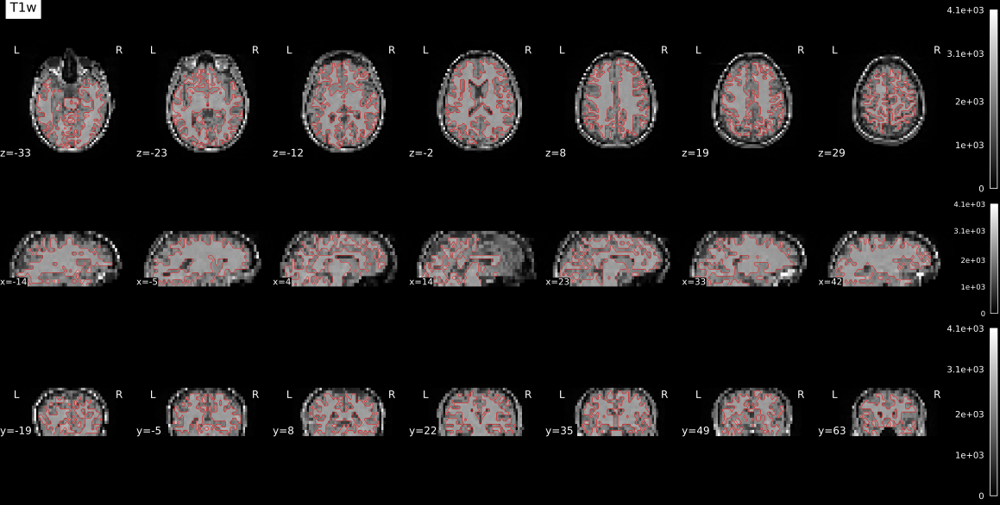

In [9]:
SVG(filename='aslprep-output/sub-01/figures/sub-01_desc-coreg_asl.svg')

### ASL Summary
Summary statistics are plotted, which may reveal trends or artifacts in the ASL data. DVARS and FD show the standardized DVARS and framewise-displacement measures for each time point. A carpet plot shows the time series for all voxels within the brain mask. Voxels are grouped into cortical (blue), and subcortical (orange) gray matter, cerebellum (green) and white matter and CSF (red), indicated by the color map on the left-hand side.


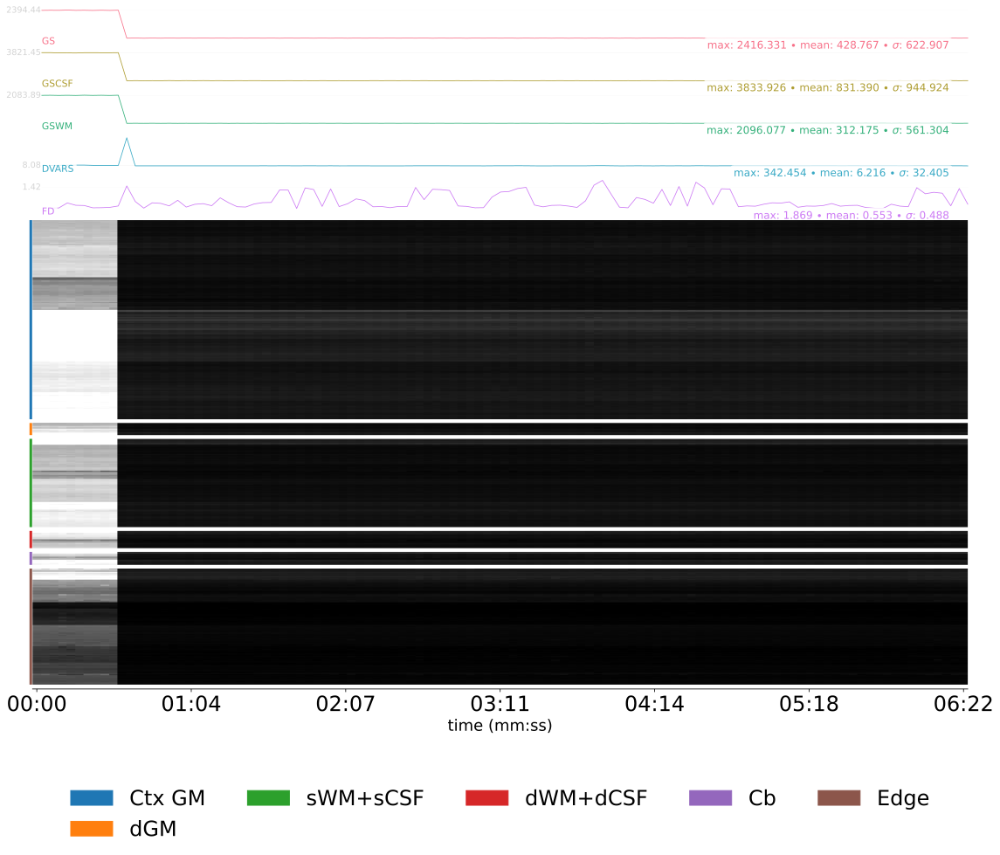

In [10]:
SVG(filename='aslprep-output/sub-01/figures/sub-01_desc-carpetplot_asl.svg')

### CBF
The maps plot cerebral blood flow (CBF) for basic CBF. The unit is mL/100 g/min.

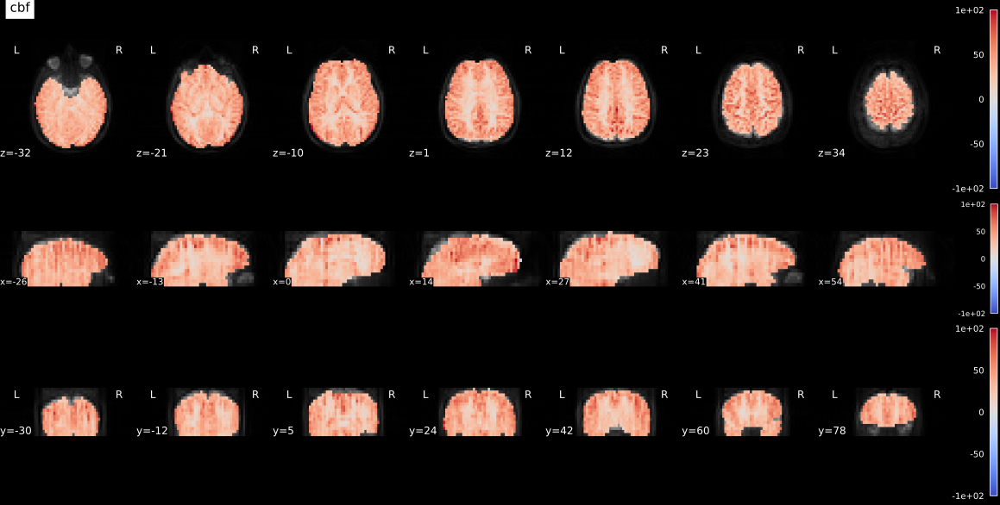

In [11]:
SVG(filename='aslprep-output/sub-01/figures/sub-01_desc-brain_cbf.svg')

#### Dependencies in Jupyter/Python
- Using the package [watermark](https://github.com/rasbt/watermark) to document system environment and software versions used in this notebook, alongside the Neurodesktop version extracted from the `JUPYTER_IMAGE` or `NEURODESKTOP_VERSION` environment variables.

In [12]:
import os

%load_ext watermark

%watermark
%watermark --iversions

neurodesktop_version = (
    os.environ.get('JUPYTER_IMAGE', '').split(':')[-1] or
    os.environ.get('NEURODESKTOP_VERSION', 'unknown')
)

print(f"Neurodesktop version: {neurodesktop_version}")

Last updated: 2026-04-18T04:59:36.592592+00:00

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.7.0

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 5.15.0-171-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 32
Architecture: 64bit

IPython: 9.7.0
json   : 2.0.9

Neurodesktop version: 2025-12-20
